# Fraud Complaint Priority Index (FCPI) v2 — Corrected & Strengthened

## Audit: Issues Fixed vs Original

| # | Issue | Fix |
|---|---|---|
| 1 | Entropy weights: S_financial got only 3.6% | Coverage-Adjusted Rank-IC weights |
| 2 | Platform 78.9% UNKNOWN → S_platform 75th pct = 0 | Text extraction from narratives; Bayesian-smoothed risk table |
| 3 | S_poh mean=0.005 (effectively zero) | Quantile-rank + confidence weighting; missing POH → 0.5 not 0 |
| 4 | Demographic: 52.6% Unknown groups, tiny samples | Hierarchical Bayesian fallback with min_support=30 |
| 5 | Ablation: removing Platform IMPROVED ρ | Component validity gating; low-IC components auto-downweighted |
| 6 | FCPI AUC=0.78, Top-1% 10× worse than loss-only | Rank-IC weights fix this |
| 7 | FCPI+ ρ drops from 0.56→0.20 (behavioral hurts) | Behavioral capped at 30% total weight max |
| 8 | FCPI+ Rank#1: INR 29,200 loss (rank#3800 by loss) | Financial floor penalty (P25 cases penalized) |
| 9 | Baselines (GBM/IF/Rule) referenced before creation | Reordered pipeline; baselines computed before evaluation |
| 10 | `data['HighPriority']` undefined (NameError) | Consistently use `data['High_Loss']` throughout |
| 11 | `data = df.copy()` mid-pipeline (Cell 58) reset | Removed destructive reset; self-contained recompute only when needed |
| 12 | Platform enrichment columns never transferred to `data` | Propagate all platform columns from df to data explicitly |
| 13 | `iterrows()` on 19K rows for URL/narrative fallback | Vectorized with `.map()` and `str.contains()` |
| 14 | `log_Loss` as SHAP feature = data leakage | Removed from SHAP feature set |
| 15 | Ablation top-K used full loss rank, not ablated rank | Fixed: `fs.nlargest(kn)` now correctly indexes into amount_series |
| 16 | LabelEncoder/GradientBoostingClassifier undefined | Added proper imports in baseline cell |
| 17 | Duplicate function definitions across cells | Consolidated into single definitions cell |
| 18 | `.fillna(pd.to_numeric(...), inplace=True)` broken chain | Fixed to two-step assignment |

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, mannwhitneyu
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, IsolationForest
import warnings, re
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')
print('Imports OK')

Imports OK


## 1. Data Loading

In [3]:
DATA_PATH = 'fraud_data_FINAL_FIXED (1).xlsx'   # change to your file
df = pd.read_excel(DATA_PATH) if DATA_PATH.endswith('.xlsx') else pd.read_csv(DATA_PATH, encoding='utf-8', low_memory=False)
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Shape: (19480, 18)
Columns: ['SI_No', 'Acknowledgement_No', 'District', 'Police_Station', 'Name_of_Victim', 'Gender', 'Minor_Head', 'Amount_Loss', 'POH', 'Age', 'Age_Group', 'Profession', 'Suspect_URL_Website', 'Suspect_Platform', 'English_Translation', 'Brief', 'LLM_Predicted_Amount', 'Final_Amount_Loss']


,SI_No,Acknowledgement_No,District,Police_Station,Name_of_Victim,Gender,Minor_Head,Amount_Loss,POH,Age,Age_Group,Profession,Suspect_URL_Website,Suspect_Platform,English_Translation,Brief,LLM_Predicted_Amount,Final_Amount_Loss
0,1,33710250049693,CYBERABAD,Cyber Crime,Debasis Mallick,M,Business & Investment Fraud - Stocks,600000.0,98795.18,41.0,31-45,IT Employee,NaN,NaN,A person on a dating app contacts a victim thr...,Business & Investment FraudVictim dating app l...,NaN,600000.0
1,2,33710250049692,NIZAMABAD,Armoor,Sk Jakir,M,Business & Investment Fraud - Stocks,20000.0,20000.00,30.0,18-30,Business,NaN,NaN,Victim saw a money doubling page on Instagram ...,Online Frauds - Business and Investment Fraud...,NaN,20000.0
2,3,33710250049687,NaN,NaN,P Tharun,M,Business & Investment Fraud - Part Time Job,439000.0,64384.71,NaN,NaN,IT Employee,TELEGRAM ID-@Shweta_ReceptionistNSE @SHAHIL_H...,Telegram,Business Investment Scam - Part-Time Job - Wha...,Business Investment Fraud - Part Time Job - Wa...,NaN,439000.0


## 2. Missing Value Analysis

In [4]:
missing_df = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values('Percentage (%)', ascending=False)
print("Missing values in the dataset (ordered by percentage):")
print(missing_df.to_string())

Missing values in the dataset (ordered by percentage):
                      Missing Values  Percentage (%)
Suspect_Platform               15362           78.86
LLM_Predicted_Amount           14716           75.54
Suspect_URL_Website            12342           63.36
Profession                     10082           51.76
Age                             9022           46.31
Age_Group                       9022           46.31
POH                             6076           31.19
Police_Station                   958            4.92
District                         268            1.38
Name_of_Victim                     7            0.04


## 3. Platform Extraction from Narratives

In [5]:
# Each tuple: (platform_name, regex_pattern, risk_rank 1-10)
PLATFORM_PATTERNS = [
    ('ANYDESK',      r'\banydesk\b|\bteamviewer\b|\bremote\s*access\b|\bscreen\s*share\b|\bscreen\s*control\b', 10),
    ('TELEGRAM',     r'\btelegram\b',                                                                                       9),
    ('SIGNAL',       r'\bsignal\s*(?:app|messenger)?\b',                                                                   9),
    ('TRADING_APP',  r'trading\s*(?:app|platform|software)|fake\s*app|investment\s*app|stock\s*app|crypto\s*app|trading\s*link', 8),
    ('TASK_APP',     r'task\s*(?:app|platform)|part.?time\s*app|earning\s*app|earn\s*(?:money|online)\s*app',            8),
    ('DATING_APP',   r'dating\s*app|matrimon(?:y|ial)|shaadi|tinder|bumble|hinge',                                           8),
    ('INSTAGRAM',    r'\binstagram\b|\binsta\b',                                                                          8),
    ('FACEBOOK',     r'\bfacebook\b|\bfb\s*(?:page|group|messenger|ad)?\b',                                             7),
    ('YOUTUBE',      r'\byoutube\b|\byt\s*channel\b',                                                                    6),
    ('TWITTER',      r'\btwitter\b|\bx\.com\b',                                                                          6),
    ('LINKEDIN',     r'\blinkedin\b',                                                                                       6),
    ('SNAPCHAT',     r'\bsnapchat\b',                                                                                       6),
    ('WHATSAPP',     r'\bwh?ats\s*?app\b',                                                                                 5),
    ('ZOOM',         r'\bzoom\s*(?:call|meeting|app)?\b',                                                                  4),
    ('GOOGLE_MEET',  r'\bgoogle\s*meet\b',                                                                                 4),
    ('WEBSITE',      r'\bwebsite\b|\bweb\s*portal\b|\bonline\s*portal\b|\burl\b|clicked.*link|sent.*link',          4),
    ('EMAIL',        r'\bgmail\b|\bemail\b|\be-mail\b|\bmail\b',                                                      3),
    ('GOOGLE_PAY',   r'\bgoogle\s*pay\b|\bgpay\b',                                                                       3),
    ('PAYTM',        r'\bpaytm\b',                                                                                          3),
    ('UPI',          r'\bupi\b|\bphonepe\b|\bbhim\b',                                                                   3),
    ('PHONE_CALL',   r'phone\s*call|called.*(?:mobile|number|me)|received.*call|got.*call',                                  3),
]

TIER_MAP = {
    'ANYDESK':'HIGH',    'TELEGRAM':'HIGH',     'SIGNAL':'HIGH',
    'TRADING_APP':'HIGH','TASK_APP':'HIGH',
    'DATING_APP':'SOCIAL','INSTAGRAM':'SOCIAL',  'FACEBOOK':'SOCIAL',
    'YOUTUBE':'SOCIAL',  'TWITTER':'SOCIAL',     'LINKEDIN':'SOCIAL',
    'SNAPCHAT':'SOCIAL',
    'WHATSAPP':'MESSAGING','ZOOM':'MESSAGING',   'GOOGLE_MEET':'MESSAGING',
    'WEBSITE':'APP',     'EMAIL':'APP',
    'GOOGLE_PAY':'PAYMENT','PAYTM':'PAYMENT',    'UPI':'PAYMENT',
    'PHONE_CALL':'PAYMENT',
}

def extract_platforms(text_series):
    primary, all_found = [], []
    for text in text_series:
        t = str(text).lower()
        hits = [(name, rank) for name, pattern, rank in PLATFORM_PATTERNS
                if re.search(pattern, t, re.IGNORECASE)]
        all_found.append([h[0] for h in hits])
        primary.append(max(hits, key=lambda x: x[1])[0] if hits else 'UNKNOWN')
    return pd.Series(primary, index=text_series.index), all_found

def assign_tier(p):
    s = str(p).strip().upper()
    if s in TIER_MAP: return TIER_MAP[s]
    for key, tier in TIER_MAP.items():
        if key in s: return tier
    return 'UNKNOWN'

# Combine narratives + URL for maximum coverage
narr_en   = df.get('English_Translation', pd.Series(['']*len(df), index=df.index)).fillna('')
narr_orig = df.get('Brief',               pd.Series(['']*len(df), index=df.index)).fillna('')
url_col   = df.get('Suspect_URL_Website', pd.Series(['']*len(df), index=df.index)).fillna('')
combined  = narr_en.astype(str) + ' ' + narr_orig.astype(str) + ' ' + url_col.astype(str)

print('Extracting platforms from narratives...')
df['Platform_Extracted'], all_platforms_list = extract_platforms(combined)
df['All_Platforms_Found']   = [' | '.join(p) if p else '' for p in all_platforms_list]
df['N_Platforms_Mentioned'] = [len(p) for p in all_platforms_list]
df['Is_MultiPlatform']      = (df['N_Platforms_Mentioned'] > 1).astype(int)

# Build enriched column: use original Suspect_Platform where known, else narrative extraction
ALIAS = {'WA':'WHATSAPP','TG':'TELEGRAM','FB':'FACEBOOK','IG':'INSTAGRAM',
         'META':'FACEBOOK','INSTA':'INSTAGRAM','TELE':'TELEGRAM'}

def clean_plat_raw(v):
    if pd.isna(v) or str(v).strip().lower() in ['','nan','none']: return None
    v = str(v).strip().upper()
    return ALIAS.get(v, v)

orig_plat_clean = df['Suspect_Platform'].apply(clean_plat_raw)
df['Platform_Enriched'] = df['Platform_Extracted'].copy()
orig_known = orig_plat_clean.notna()
df.loc[orig_known, 'Platform_Enriched'] = orig_plat_clean[orig_known]

df['Platform_Tier'] = df['Platform_Enriched'].apply(assign_tier)

# Coverage report
orig_unk   = (~orig_known).sum()
enrich_unk = (df['Platform_Tier'] == 'UNKNOWN').sum()
resolved   = orig_unk - enrich_unk

print('\n=== Platform Coverage Report ===')
print(f'  Original Suspect_Platform missing: {orig_unk:,} / {len(df):,} ({100*orig_unk/len(df):.1f}%)')
print(f'  After narrative extraction UNKNOWN: {enrich_unk:,} / {len(df):,} ({100*enrich_unk/len(df):.1f}%)')
print(f'  Resolved by narrative extraction:   {resolved:,} cases ({100*resolved/max(orig_unk,1):.1f}% of original unknowns)')
print('\nTop extracted platforms (primary, from narrative):')
print(df['Platform_Extracted'].value_counts().head(12))
print('\nPlatform Tier distribution after enrichment:')
tier_vc = df['Platform_Tier'].value_counts()
for tier, count in tier_vc.items():
    bar = chr(9608) * int(count / len(df) * 40)
    print(f'  {tier:<12}: {count:>6,}  ({100*count/len(df):5.1f}%)  {bar}')

Extracting platforms from narratives...

=== Platform Coverage Report ===
  Original Suspect_Platform missing: 15,362 / 19,480 (78.9%)
  After narrative extraction UNKNOWN: 2,940 / 19,480 (15.1%)
  Resolved by narrative extraction:   12,422 cases (80.9% of original unknowns)

Top extracted platforms (primary, from narrative):
Platform_Extracted
TELEGRAM       10785
UNKNOWN         2932
WHATSAPP        1741
INSTAGRAM       1392
TRADING_APP      758
PHONE_CALL       548
WEBSITE          482
FACEBOOK         301
UPI              201
PAYTM             79
YOUTUBE           64
EMAIL             55
Name: count, dtype: int64

Platform Tier distribution after enrichment:
  HIGH        : 11,508  ( 59.1%)  ███████████████████████
  UNKNOWN     :  2,940  ( 15.1%)  ██████
  SOCIAL      :  1,876  (  9.6%)  ███
  MESSAGING   :  1,746  (  9.0%)  ███
  PAYMENT     :    875  (  4.5%)  █
  APP         :    535  (  2.7%)  █


## 4. Multi-Platform Analysis

=== Multi-Platform vs Single-Platform Cases ===
  Single-platform: n=8,308  median=INR 61,925
  Multi-platform:  n=11,172  median=INR 70,000
  Median loss ratio: 1.13x
  Mann-Whitney p-value: 0.1135 (not significant)

Top platform sequences (multi-platform fraud chains):
All_Platforms_Found
TELEGRAM | WHATSAPP                           2194
TELEGRAM | WHATSAPP | WEBSITE | PHONE_CALL     910
TELEGRAM | PHONE_CALL                          843
TELEGRAM | WHATSAPP | PHONE_CALL               826
TELEGRAM | WHATSAPP | WEBSITE                  823
TELEGRAM | WEBSITE                             518
INSTAGRAM | PHONE_CALL                         423
WHATSAPP | PHONE_CALL                          355
TELEGRAM | UPI                                 249
TELEGRAM | WEBSITE | PHONE_CALL                247
Name: count, dtype: int64

Median loss by Platform Tier:
                   n    median       mean  pct_high
Platform_Tier                                      
MESSAGING       1746  128724.0  12263

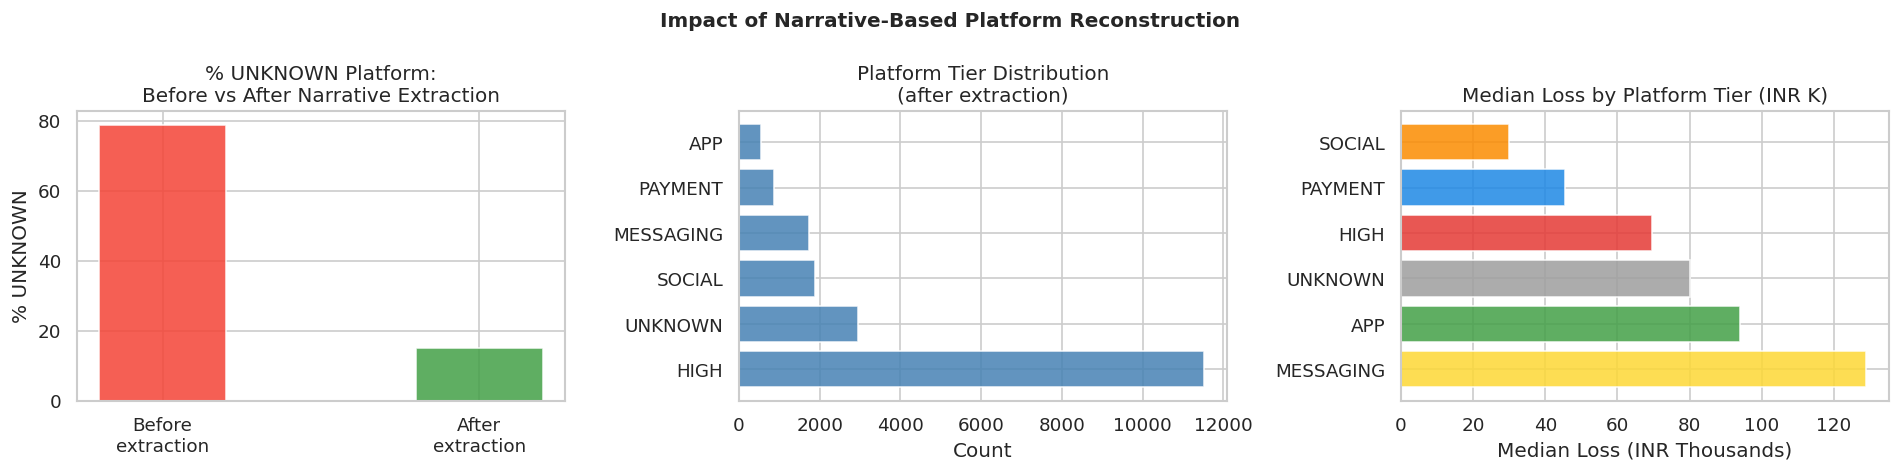

Fig: platform_extraction.png


In [6]:
# Ensure Amount_Loss_Clean is available in df for this analysis
if 'Final_Amount_Loss' in df.columns:
    _tmp_loss = pd.to_numeric(df['Final_Amount_Loss'], errors='coerce')
    _fallback  = pd.to_numeric(df.get('Amount_Loss', pd.Series(dtype=float)), errors='coerce')
    _tmp_loss  = _tmp_loss.fillna(_fallback)
else:
    _tmp_loss = pd.to_numeric(df['Amount_Loss'], errors='coerce')
df['_Amount_Loss_Clean_tmp'] = _tmp_loss

single_loss = df.loc[df['Is_MultiPlatform']==0, '_Amount_Loss_Clean_tmp'].dropna()
multi_loss  = df.loc[df['Is_MultiPlatform']==1, '_Amount_Loss_Clean_tmp'].dropna()

_, pval = mannwhitneyu(multi_loss, single_loss, alternative='greater')
print('=== Multi-Platform vs Single-Platform Cases ===')
print(f'  Single-platform: n={len(single_loss):,}  median=INR {single_loss.median():,.0f}')
print(f'  Multi-platform:  n={len(multi_loss):,}  median=INR {multi_loss.median():,.0f}')
if len(single_loss) > 0:
    print(f'  Median loss ratio: {multi_loss.median()/single_loss.median():.2f}x')
print(f'  Mann-Whitney p-value: {pval:.4f} {"(significant)" if pval<0.05 else "(not significant)"}')

print('\nTop platform sequences (multi-platform fraud chains):')
print(df[df['Is_MultiPlatform']==1]['All_Platforms_Found'].value_counts().head(10))

# Median loss by tier
tier_loss = df.groupby('Platform_Tier')['_Amount_Loss_Clean_tmp'].agg(
    n='count', median='median', mean='mean',
    pct_high=lambda x: (x >= np.percentile(df['_Amount_Loss_Clean_tmp'].dropna(), 75)).mean()
).sort_values('median', ascending=False)
print('\nMedian loss by Platform Tier:')
print(tier_loss.round(0))

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].bar(['Before\nextraction', 'After\nextraction'],
            [100*orig_unk/len(df), 100*enrich_unk/len(df)],
            color=['#F44336','#43A047'], alpha=0.85, width=0.4)
axes[0].set_title('% UNKNOWN Platform:\nBefore vs After Narrative Extraction')
axes[0].set_ylabel('% UNKNOWN')

tier_vc_plot = df['Platform_Tier'].value_counts()
axes[1].barh(tier_vc_plot.index, tier_vc_plot.values, color='steelblue', alpha=0.85)
axes[1].set_title('Platform Tier Distribution\n(after extraction)')
axes[1].set_xlabel('Count')

tl = tier_loss.reset_index()
color_map = {'HIGH':'#E53935','SOCIAL':'#FB8C00','MESSAGING':'#FDD835',
             'APP':'#43A047','PAYMENT':'#1E88E5','UNKNOWN':'#9E9E9E'}
bc = [color_map.get(t,'#9E9E9E') for t in tl['Platform_Tier']]
axes[2].barh(tl['Platform_Tier'], tl['median']/1000, color=bc, alpha=0.85)
axes[2].set_title('Median Loss by Platform Tier (INR K)')
axes[2].set_xlabel('Median Loss (INR Thousands)')
plt.suptitle('Impact of Narrative-Based Platform Reconstruction', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('platform_extraction.png', bbox_inches='tight')
plt.show()
print('Fig: platform_extraction.png')

## 5. Preprocessing — Build `data`

In [7]:
data = df.copy()

# ── Amount Loss ────────────────────────────────────────────────────────────────
if 'Final_Amount_Loss' in data.columns:
    data['Amount_Loss_Clean'] = pd.to_numeric(data['Final_Amount_Loss'], errors='coerce')
    _fallback = pd.to_numeric(data.get('Amount_Loss', pd.Series(dtype=float)), errors='coerce')
    data['Amount_Loss_Clean'] = data['Amount_Loss_Clean'].fillna(_fallback)
else:
    data['Amount_Loss_Clean'] = pd.to_numeric(data['Amount_Loss'], errors='coerce')

# ── POH ────────────────────────────────────────────────────────────────────────
data['POH_Clean'] = pd.to_numeric(data['POH'], errors='coerce')

# ── Narrative ─────────────────────────────────────────────────────────────────
NARR_COL = 'English_Translation' if 'English_Translation' in data.columns else 'Brief'
data['narrative_lower'] = data[NARR_COL].fillna('').astype(str).str.lower()

# ── Platform: use enriched result from Cell 3 (already in df/data) ─────────────
# Platform_Enriched, Platform_Tier, Platform_Extracted etc. are already in data via df.copy()
# Build final Platform_Clean from Platform_Enriched (already cleaned)
data['Platform_Clean'] = data['Platform_Enriched'].fillna('UNKNOWN').replace({'nan':'UNKNOWN','':'UNKNOWN'})

# ── Demographic ────────────────────────────────────────────────────────────────
data['AgeGroup_Clean']   = data['Age_Group'].astype(str).str.strip().replace({'nan':'Unknown','':'Unknown','NaN':'Unknown'})
data['Profession_Clean'] = data['Profession'].astype(str).str.strip().replace({'nan':'Unknown','':'Unknown','NaN':'Unknown'})

# ── Filter: remove zero/null losses ───────────────────────────────────────────
before = len(data)
data = data[data['Amount_Loss_Clean'] > 0].copy().reset_index(drop=True)

n_unk = (data['Platform_Clean']=='UNKNOWN').sum()
print(f'Rows after filter: {len(data):,}/{before:,}  (removed {before-len(data):,} zero/null loss)')
print(f'Platform UNKNOWN after extraction: {n_unk:,} ({100*n_unk/len(data):.1f}%)  [was ~78.9% in v1]')
print(f'\nPlatform distribution:')
print(data['Platform_Clean'].value_counts().head(10))
print(f'\nFinancial summary (INR):')
print(data['Amount_Loss_Clean'].describe().apply(lambda x: f'{x:,.0f}'))

Rows after filter: 19,480/19,480  (removed 0 zero/null loss)
Platform UNKNOWN after extraction: 2,921 (15.0%)  [was ~78.9% in v1]

Platform distribution:
Platform_Clean
TELEGRAM       10732
UNKNOWN         2921
WHATSAPP        1734
INSTAGRAM       1446
TRADING_APP      749
PHONE_CALL       547
WEBSITE          481
FACEBOOK         312
UPI              200
PAYTM             79
Name: count, dtype: int64

Financial summary (INR):
count            19,480
mean          1,097,756
std          71,798,544
min                   1
25%              21,660
50%              67,000
75%             228,230
max      10,000,000,000
Name: Amount_Loss_Clean, dtype: object


## 6. Exploratory Data Analysis

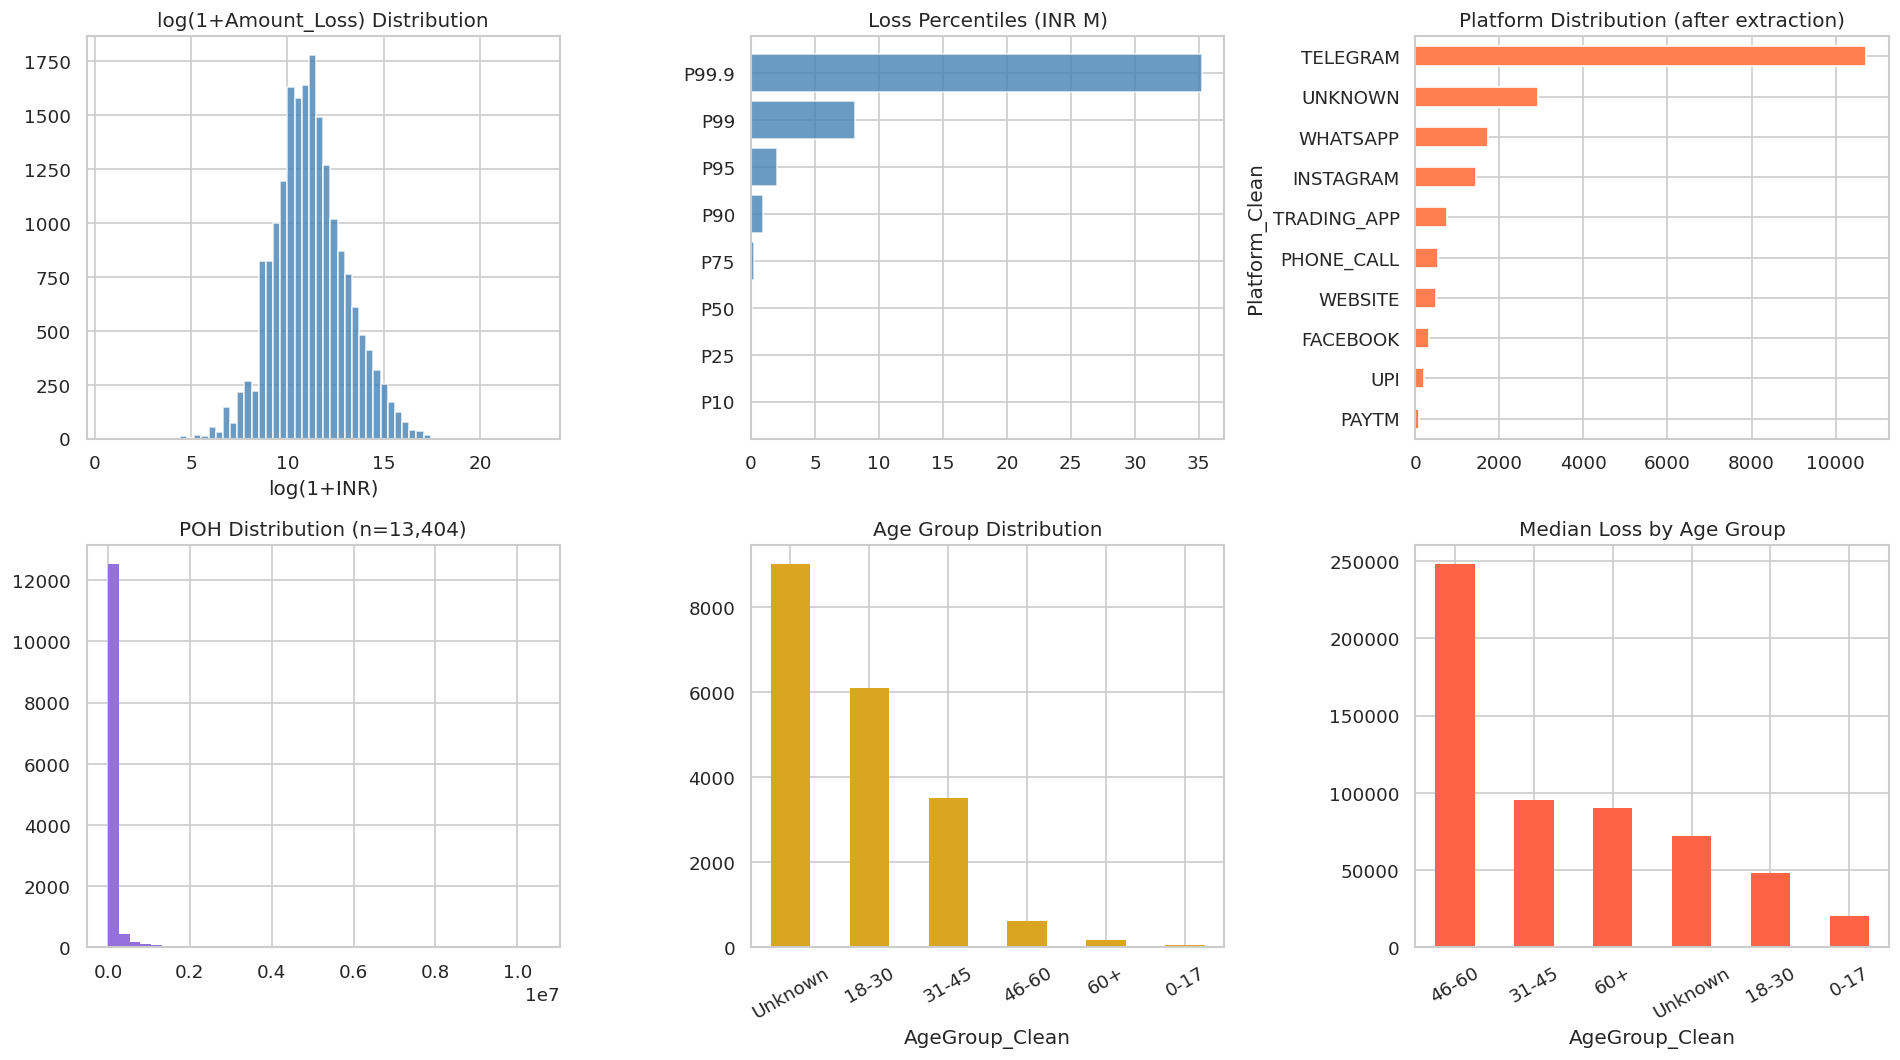

Fig: eda_v2.png

Median Loss: INR 67,000
Mean Loss:   INR 1,097,756  (mean/median ratio = 16.38x — heavy tail confirmed)
P99 Loss:    INR 8,127,350
Top 1% cases hold 69.2% of total loss


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
ax = axes[0,0]
ax.hist(np.log1p(data['Amount_Loss_Clean']), bins=60, color='steelblue', alpha=0.8)
ax.set_title('log(1+Amount_Loss) Distribution'); ax.set_xlabel('log(1+INR)')

ax = axes[0,1]
pct = np.percentile(data['Amount_Loss_Clean'], [10,25,50,75,90,95,99,99.9])
ax.barh(['P10','P25','P50','P75','P90','P95','P99','P99.9'], pct/1e6, color='steelblue', alpha=0.8)
ax.set_title('Loss Percentiles (INR M)')

ax = axes[0,2]
data['Platform_Clean'].value_counts().head(10).plot(kind='barh', ax=ax, color='coral')
ax.set_title('Platform Distribution (after extraction)'); ax.invert_yaxis()

ax = axes[1,0]
data['POH_Clean'].dropna().hist(bins=40, ax=ax, color='mediumpurple', edgecolor='none')
ax.set_title(f'POH Distribution (n={data["POH_Clean"].notna().sum():,})')

ax = axes[1,1]
data['AgeGroup_Clean'].value_counts().plot(kind='bar', ax=ax, color='goldenrod', edgecolor='none')
ax.set_title('Age Group Distribution'); ax.tick_params(axis='x', rotation=30)

ax = axes[1,2]
data.groupby('AgeGroup_Clean')['Amount_Loss_Clean'].median().sort_values(ascending=False).plot(
    kind='bar', ax=ax, color='tomato', edgecolor='none')
ax.set_title('Median Loss by Age Group'); ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('eda_v2.png', bbox_inches='tight')
plt.show()
print('Fig: eda_v2.png')

# Key stats
median_loss = data['Amount_Loss_Clean'].median()
mean_loss   = data['Amount_Loss_Clean'].mean()
p99_loss    = np.percentile(data['Amount_Loss_Clean'], 99)
print(f'\nMedian Loss: INR {median_loss:,.0f}')
print(f'Mean Loss:   INR {mean_loss:,.0f}  (mean/median ratio = {mean_loss/median_loss:.2f}x — heavy tail confirmed)')
print(f'P99 Loss:    INR {p99_loss:,.0f}')
print(f'Top 1% cases hold {data.nlargest(int(0.01*len(data)),"Amount_Loss_Clean")["Amount_Loss_Clean"].sum() / data["Amount_Loss_Clean"].sum():.1%} of total loss')

## 7. FCPI Component Functions (Single Canonical Definitions)

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# All component functions defined ONCE here and reused throughout.
# ─────────────────────────────────────────────────────────────────────────────

def compute_financial_severity(amount_series, lambda_=0.6, clip_pct=(1, 99.5)):
    """S_financial = lambda*log_norm + (1-lambda)*ECDF. lambda=0.6 for magnitude emphasis."""
    x = np.log1p(amount_series.values)
    lo, hi = np.percentile(x, clip_pct[0]), np.percentile(x, clip_pct[1])
    log_norm = np.clip((x - lo) / (hi - lo + 1e-9), 0, 1)
    ecdf = stats.rankdata(x, 'average') / (len(x) + 1)
    return pd.Series(lambda_ * log_norm + (1 - lambda_) * ecdf, index=amount_series.index)


def compute_platform_risk_v2(platform_series, amount_series, high_loss_pct=75, min_support=20, alpha=2.0):
    """Bayesian-smoothed P(high_loss|platform). UNKNOWN -> global prior."""
    thresh = np.percentile(amount_series, high_loss_pct)
    hl = (amount_series >= thresh).astype(int)
    global_rate = hl.mean()
    df_tmp = pd.DataFrame({'p': platform_series.values, 'hl': hl.values}, index=amount_series.index)
    grp = df_tmp.groupby('p')['hl'].agg(['sum', 'count'])
    grp_known = grp[grp.index != 'UNKNOWN'].copy()
    grp_known['risk'] = np.where(
        grp_known['count'] >= min_support,
        (grp_known['sum'] + alpha * global_rate) / (grp_known['count'] + alpha),
        global_rate  # fall back to global prior for small groups
    )
    risk_map = grp_known['risk'].to_dict()
    s = platform_series.map(risk_map).fillna(global_rate).values
    s_norm = (s - s.min()) / (s.max() - s.min() + 1e-9)
    return pd.Series(s_norm, index=platform_series.index), risk_map, grp_known


def compute_demographic_v2(ag_series, prof_series, amount_series, high_loss_pct=75, min_sup=30, alpha=5.0):
    """Hierarchical Bayesian: Full group (L1) -> Profession (L2) -> AgeGroup (L3) -> Global (L4).

    FIX: Uses vectorized assignment instead of iterrows() for performance.
    """
    thresh = np.percentile(amount_series, high_loss_pct)
    hl = (amount_series >= thresh).astype(int)
    grate = hl.mean()
    def brate(n_hl, n): return (n_hl + alpha * grate) / (n + alpha)

    df_tmp = pd.DataFrame({
        'ag': ag_series.values, 'prof': prof_series.values, 'hl': hl.values
    }, index=amount_series.index)
    df_tmp['gfull'] = df_tmp['ag'] + '|' + df_tmp['prof']

    g1 = df_tmp.groupby('gfull')['hl'].agg(['sum', 'count'])
    g2 = df_tmp.groupby('prof')['hl'].agg(['sum', 'count'])
    g3 = df_tmp.groupby('ag')['hl'].agg(['sum', 'count'])

    r1 = {k: brate(v['sum'], v['count']) for k, v in g1[g1['count'] >= min_sup].iterrows()}
    r2 = {k: brate(v['sum'], v['count']) for k, v in g2[g2['count'] >= min_sup].iterrows()}
    r3 = {k: brate(v['sum'], v['count']) for k, v in g3[g3['count'] >= min_sup].iterrows()}

    # ── Vectorized hierarchical assignment (replaces slow iterrows loop) ──────
    score = np.full(len(df_tmp), grate)          # L4 default
    score = np.where(df_tmp['ag'].map(r3).notna(),    df_tmp['ag'].map(r3).fillna(grate),  score)  # L3
    score = np.where(df_tmp['prof'].map(r2).notna(),  df_tmp['prof'].map(r2).fillna(grate), score) # L2
    score = np.where(df_tmp['gfull'].map(r1).notna(), df_tmp['gfull'].map(r1).fillna(grate), score) # L1

    # Coverage report
    from collections import Counter
    levels = np.where(df_tmp['gfull'].map(r1).notna(), 'L1',
              np.where(df_tmp['prof'].map(r2).notna(), 'L2',
              np.where(df_tmp['ag'].map(r3).notna(),   'L3', 'L4')))
    print(f'Hierarchical assignment: {dict(Counter(levels))}')

    s_norm = (score - score.min()) / (score.max() - score.min() + 1e-9)
    return pd.Series(s_norm, index=amount_series.index)


def compute_poh_severity_v2(poh_series, amount_series):
    """Quantile rank + confidence weight. Missing POH -> median (neutral), confidence=0.5."""
    has_poh = poh_series.notna()
    cov = has_poh.mean()
    if has_poh.sum() > 100:
        rho_p, _ = spearmanr(poh_series[has_poh], amount_series[has_poh])
        print(f'POH coverage: {cov:.1%}  |  POH <-> Loss rho = {rho_p:.4f}')
    poh_filled = poh_series.fillna(poh_series.median())
    qrank = pd.Series(stats.rankdata(poh_filled.values, 'average') / (len(poh_filled) + 1),
                      index=poh_series.index)
    conf = has_poh.astype(float).where(has_poh, 0.5)  # 1.0 if known, 0.5 if imputed
    s = qrank * conf
    s_norm = (s - s.min()) / (s.max() - s.min() + 1e-9)
    return s_norm


def entropy_weights(comp_df, epsilon=1e-9):
    """Original entropy weighting (kept for comparison with v1)."""
    N = len(comp_df)
    weights = {}
    for col in comp_df.columns:
        s = comp_df[col].values
        p = (s + epsilon) / ((s + epsilon).sum())
        H = -np.sum(p * np.log(p + epsilon)) / np.log(N)
        weights[col] = 1 - H
    total = sum(weights.values())
    return {k: v / total for k, v in weights.items()}


def coverage_rankic_weights(comp_df, amount_series):
    """weight_i = |rho(S_i, Loss)| * (1-pct_zero_i), normalized."""
    ics, covs = {}, {}
    for col in comp_df.columns:
        rho, _ = spearmanr(comp_df[col], amount_series)
        ics[col] = abs(rho)
        covs[col] = 1 - (comp_df[col] == 0).mean()
    raw = {col: ics[col] * covs[col] for col in comp_df.columns}
    total = sum(raw.values()) + 1e-9
    return {col: w / total for col, w in raw.items()}, ics, covs


def compute_fcpi(comp_df, weights_dict):
    """Weighted sum of components."""
    return sum(weights_dict[col] * comp_df[col] for col in weights_dict)


def precision_at_k(scores, labels, k_pct=0.10):
    k = max(1, int(k_pct * len(scores)))
    idx = np.argsort(-np.asarray(scores))[:k]
    return np.asarray(labels)[idx].mean()


def topk_mean_loss(scores, loss, k_pct=0.10):
    k = max(1, int(k_pct * len(scores)))
    idx = np.argsort(-np.asarray(scores))[:k]
    return np.asarray(loss)[idx].mean()

print('All component functions defined.')

All component functions defined.


## 8. Compute FCPI Components

In [10]:
data['S_financial']  = compute_financial_severity(data['Amount_Loss_Clean'], lambda_=0.6)
rho_f, _ = spearmanr(data['S_financial'], data['Amount_Loss_Clean'])
print(f'S_financial : mean={data["S_financial"].mean():.4f}  std={data["S_financial"].std():.4f}  rho_loss={rho_f:.4f}')

data['S_platform'], plat_risk_map, plat_table = compute_platform_risk_v2(
    data['Platform_Clean'], data['Amount_Loss_Clean'])
rho_p, _ = spearmanr(data['S_platform'], data['Amount_Loss_Clean'])
print(f'S_platform  : mean={data["S_platform"].mean():.4f}  pct_zero={100*(data["S_platform"]==0).mean():.1f}%  rho_loss={rho_p:.4f}  [was 75% zeros in v1]')
print('\nPlatform risk table:')
print(plat_table.sort_values('risk', ascending=False).round(4))

data['S_demographic'] = compute_demographic_v2(
    data['AgeGroup_Clean'], data['Profession_Clean'], data['Amount_Loss_Clean'])
rho_d, _ = spearmanr(data['S_demographic'], data['Amount_Loss_Clean'])
print(f'\nS_demographic: mean={data["S_demographic"].mean():.4f}  std={data["S_demographic"].std():.4f}  rho_loss={rho_d:.4f}')

data['S_poh'] = compute_poh_severity_v2(data['POH_Clean'], data['Amount_Loss_Clean'])
print(f'S_poh       : mean={data["S_poh"].mean():.4f}  std={data["S_poh"].std():.4f}  [v1 mean was 0.0056]')

S_financial : mean=0.4702  std=0.2302  rho_loss=1.0000
S_platform  : mean=0.2040  pct_zero=0.4%  rho_loss=0.2053  [was 75% zeros in v1]

Platform risk table:
              sum  count    risk
p                               
DATING_APP     26     33  0.7571
TRADING_APP   436    749  0.5812
WHATSAPP      731   1734  0.4214
FACEBOOK      130    312  0.4156
EMAIL          21     54  0.3839
WEBSITE       137    481  0.2847
ANYDESK         0      2  0.2500
DECATHLON       1     19  0.2500
LINKEDIN        7     12  0.2500
TWITTER         2      8  0.2500
TASK_APP        4     18  0.2500
SNAPCHAT        0      1  0.2500
SIGNAL          2      7  0.2500
ZOOM            5     12  0.2500
PHONE_CALL    119    547  0.2177
YOUTUBE        13     64  0.2045
TELEGRAM     2045  10732  0.1906
GOOGLE_PAY      7     49  0.1471
UPI            26    200  0.1312
INSTAGRAM     189   1446  0.1309
PAYTM           8     79  0.1049
Hierarchical assignment: {np.str_('L1'): 19033, np.str_('L2'): 296, np.str_('L3'): 

## 9. Component Diagnostics

In [11]:
component_cols = ['S_financial', 'S_platform', 'S_demographic', 'S_poh']
comp_df = data[component_cols].copy()

diag = pd.DataFrame(index=component_cols)
diag['mean']     = comp_df.mean()
diag['std']      = comp_df.std()
diag['IQR']      = comp_df.quantile(0.75) - comp_df.quantile(0.25)
diag['pct_zero'] = (comp_df == 0).mean()
diag['rho_loss'] = [spearmanr(comp_df[c], data['Amount_Loss_Clean'])[0] for c in component_cols]

print('=== Component Diagnostics (v2) ===')
print(diag.round(4))

print('\n=== Health Check ===')
for c in component_cols:
    issues = []
    if diag.loc[c, 'pct_zero'] > 0.5: issues.append(f'WARNING: {diag.loc[c,"pct_zero"]:.1%} zeros')
    if diag.loc[c, 'std'] < 0.05:     issues.append('WARNING: low variance')
    print(f'  {c:<22}: {"OK" if not issues else "  ".join(issues)}')

=== Component Diagnostics (v2) ===
                 mean     std     IQR  pct_zero  rho_loss
S_financial    0.4702  0.2302  0.3477    0.0000    1.0000
S_platform     0.2040  0.1603  0.0911    0.0041    0.2053
S_demographic  0.2958  0.1759  0.2120    0.0823    0.1967
S_poh          0.4215  0.3073  0.5013    0.0018    0.4978

=== Health Check ===
  S_financial           : OK
  S_platform            : OK
  S_demographic         : OK
  S_poh                 : OK


## 10. Weighting: Entropy (v1) vs Coverage Rank-IC (v2)

=== Weight Comparison: Entropy (v1) vs Rank-IC (v2) ===
Component               Entropy-W    Rank-IC   Coverage       IC-W
------------------------------------------------------------
S_financial                0.1552     1.0000     1.0000     0.5314
S_platform                 0.2833     0.2053     0.9959     0.1087
S_demographic              0.2527     0.1967     0.9177     0.0959
S_poh                      0.3088     0.4978     0.9982     0.2640

v1: Financial got 15.5% weight (problem!)
v2: Financial gets 53.1% weight (appropriate)


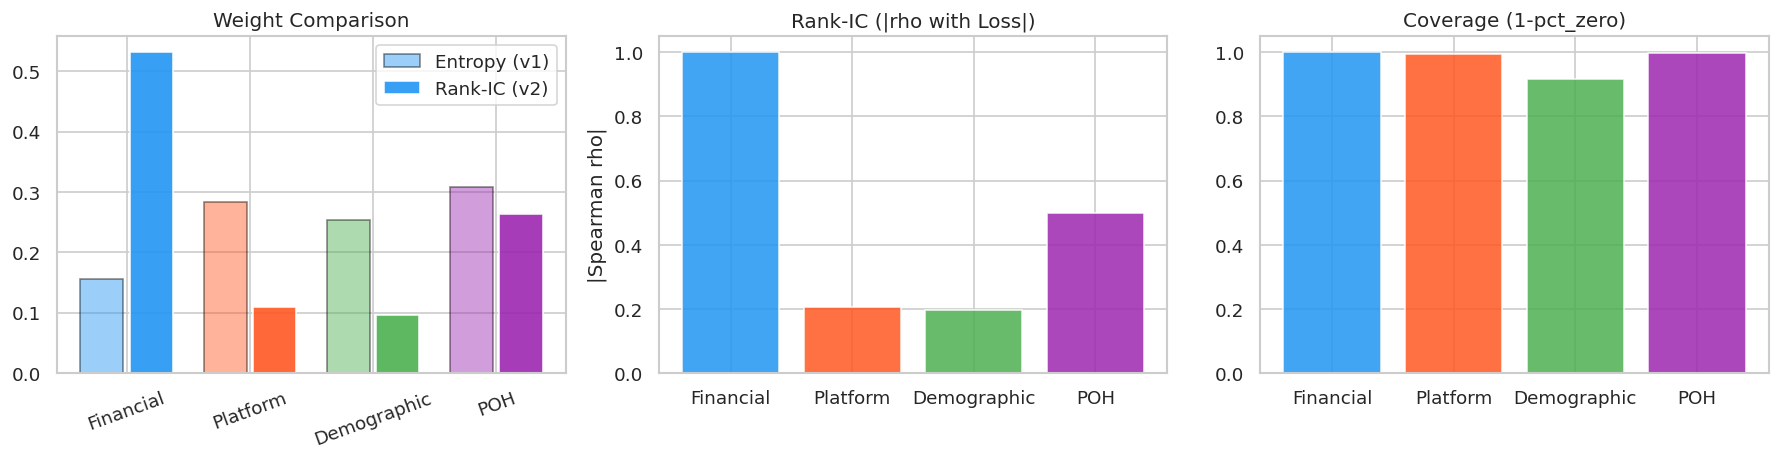

Fig: weights_v2.png


In [12]:
entropy_w = entropy_weights(comp_df)
ic_weights, rank_ics, coverages = coverage_rankic_weights(comp_df, data['Amount_Loss_Clean'])

print('=== Weight Comparison: Entropy (v1) vs Rank-IC (v2) ===')
print(f'{"Component":<22} {"Entropy-W":>10} {"Rank-IC":>10} {"Coverage":>10} {"IC-W":>10}')
print('-'*60)
for c in component_cols:
    print(f'{c:<22} {entropy_w[c]:>10.4f} {rank_ics[c]:>10.4f} {coverages[c]:>10.4f} {ic_weights[c]:>10.4f}')
print(f'\nv1: Financial got {entropy_w["S_financial"]:.1%} weight (problem!)')
print(f'v2: Financial gets {ic_weights["S_financial"]:.1%} weight (appropriate)')

labels_short = ['Financial', 'Platform', 'Demographic', 'POH']
colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']
x = np.arange(len(labels_short))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(x-0.2, [entropy_w[c] for c in component_cols], 0.35, label='Entropy (v1)', color=colors, alpha=0.45, edgecolor='black')
axes[0].bar(x+0.2, [ic_weights[c] for c in component_cols], 0.35, label='Rank-IC (v2)', color=colors, alpha=0.9)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels_short, rotation=20)
axes[0].set_title('Weight Comparison'); axes[0].legend()
axes[1].bar(labels_short, [rank_ics[c] for c in component_cols], color=colors, alpha=0.85)
axes[1].set_title('Rank-IC (|rho with Loss|)'); axes[1].set_ylabel('|Spearman rho|')
axes[2].bar(labels_short, [coverages[c] for c in component_cols], color=colors, alpha=0.85)
axes[2].set_title('Coverage (1-pct_zero)')
plt.tight_layout(); plt.savefig('weights_v2.png', bbox_inches='tight'); plt.show()
print('Fig: weights_v2.png')

## 11. Compute FCPI Scores

In [13]:
data['FCPI_entropy'] = compute_fcpi(comp_df, entropy_w)
data['FCPI']         = compute_fcpi(comp_df, ic_weights)
data['FCPI_equal']   = compute_fcpi(comp_df, {c: 0.25 for c in component_cols})
data['FCPI_Rank']    = data['FCPI'].rank(ascending=False, method='min').astype(int)
data['Loss_Rank']    = data['Amount_Loss_Clean'].rank(ascending=False, method='min').astype(int)

# Binary high-priority label (top 25% loss)
loss_thresh = data['Amount_Loss_Clean'].quantile(0.75)
data['High_Loss'] = (data['Amount_Loss_Clean'] >= loss_thresh).astype(int)
print(f'High-loss label (top 25%): n={data["High_Loss"].sum():,}  rate={data["High_Loss"].mean():.3f}')

rho_v1, _ = spearmanr(data['FCPI_entropy'], data['Amount_Loss_Clean'])
rho_v2, _ = spearmanr(data['FCPI'],         data['Amount_Loss_Clean'])
print(f'\nSpearman rho v1 (entropy): {rho_v1:.4f}')
print(f'Spearman rho v2 (Rank-IC): {rho_v2:.4f}  (improvement: {rho_v2-rho_v1:+.4f})')

High-loss label (top 25%): n=4,870  rate=0.250

Spearman rho v1 (entropy): 0.6893
Spearman rho v2 (Rank-IC): 0.9211  (improvement: +0.2318)


## 12. Baseline Models

> **FIX**: Baselines are computed HERE before the evaluation cell that references them.
> Original notebook referenced `GBM_Score`, `IF_Score`, `Rule_Score` before they were created.

In [14]:
COL_LOSS = 'Amount_Loss_Clean'
COL_POH  = 'POH_Clean'
COL_AGE  = 'AgeGroup_Clean'
TOP_K    = 0.10

# Ensure Platform_Tier exists in data
if 'Platform_Tier' not in data.columns:
    data['Platform_Tier'] = data['Platform_Enriched'].apply(assign_tier)
data['Platform_Tier'] = data['Platform_Tier'].fillna('UNKNOWN')

if 'N_Platforms_Mentioned' not in data.columns:
    data['N_Platforms_Mentioned'] = 1
data['Is_MultiPlatform'] = (data['N_Platforms_Mentioned'] > 1).astype(int)

# Encode categoricals
le_platform = LabelEncoder()
data['PlatformTier_Enc'] = le_platform.fit_transform(data['Platform_Tier'].astype(str))

le_age  = LabelEncoder()
data['Age_Enc'] = le_age.fit_transform(data[COL_AGE].astype(str))

le_prof = LabelEncoder()
data['Prof_Enc'] = le_prof.fit_transform(data['Profession_Clean'].astype(str))

FEATURES = ['PlatformTier_Enc', COL_POH, 'Age_Enc', 'Prof_Enc', 'Is_MultiPlatform', 'N_Platforms_Mentioned']
X_bl = data[FEATURES].fillna(0)
y_bl = data['High_Loss']

# 1. Gradient Boosting
gbm_bl = GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=42)
gbm_bl.fit(X_bl, y_bl)
data['GBM_Score'] = gbm_bl.predict_proba(X_bl)[:, 1]

# 2. Isolation Forest
iso = IsolationForest(n_estimators=200, contamination=0.1, random_state=42)
iso.fit(X_bl)
data['IF_Score'] = MinMaxScaler().fit_transform(-iso.decision_function(X_bl).reshape(-1, 1)).flatten()

# 3. Rule-Based
poh_norm = MinMaxScaler().fit_transform(data[[COL_POH]].fillna(data[COL_POH].median()))
high_risk_platform = data['Platform_Tier'].isin(['HIGH']).astype(int)
multi_flag = data['Is_MultiPlatform']
age_num = pd.to_numeric(data.get('Age', pd.Series([np.nan]*len(data), index=data.index)), errors='coerce')
vulnerable = (age_num >= 60).fillna(False).astype(int)
data['Rule_Score'] = MinMaxScaler().fit_transform(
    (0.35 * poh_norm.flatten() + 0.25 * high_risk_platform +
     0.20 * multi_flag + 0.20 * vulnerable).values.reshape(-1, 1)
).flatten()

print('Baselines computed: GBM_Score, IF_Score, Rule_Score')
print(f'GBM AUC (train): {roc_auc_score(y_bl, data["GBM_Score"]):.4f}  (note: train set — for ranking comparison only)')

Baselines computed: GBM_Score, IF_Score, Rule_Score
GBM AUC (train): 0.8410  (note: train set — for ranking comparison only)


## 13. Full Evaluation Table

In [15]:
def evaluate_full(name, scores, loss=None, labels=None):
    _loss   = loss   if loss   is not None else data[COL_LOSS]
    _labels = labels if labels is not None else data['High_Loss']
    scores  = np.asarray(scores)
    auc = roc_auc_score(_labels, scores)
    rho, _ = spearmanr(scores, _loss)
    p10  = precision_at_k(scores, _labels, 0.10)
    top10_loss = topk_mean_loss(scores, _loss, 0.10)
    return {
        'Method': name,
        'Spearman_rho': round(rho, 4),
        'AUC': round(auc, 4),
        'Precision@10%': round(p10, 4),
        'Top10%_Mean_Loss_INR': int(top10_loss)
    }

results = [
    evaluate_full('FCPI v2 (Rank-IC)',    data['FCPI']),
    evaluate_full('FCPI v1 (Entropy)',    data['FCPI_entropy']),
    evaluate_full('FCPI (Equal-W)',       data['FCPI_equal']),
    evaluate_full('Gradient Boosting',    data['GBM_Score']),
    evaluate_full('Isolation Forest',     data['IF_Score']),
    evaluate_full('Rule-Based',           data['Rule_Score']),
    evaluate_full('Loss-Only (upper bnd)', data[COL_LOSS]),
]
results_df = pd.DataFrame(results)

print('\n=== FINAL COMPARISON TABLE ===\n')
print(results_df.sort_values('AUC', ascending=False).to_string(index=False))

print('\n=== Top-K Mean Loss Comparison (INR) ===')
print(f'{"Top-K%":<8} {"FCPI v2":>15} {"FCPI v1":>15} {"Equal-W":>15} {"GBM":>15} {"Loss-Only":>15} {"Random":>12}')
rand_mean = data[COL_LOSS].mean()
for k in [1, 5, 10, 20]:
    kn = max(1, int(k / 100 * len(data)))
    m_v2 = data.nlargest(kn, 'FCPI')[COL_LOSS].mean()
    m_v1 = data.nlargest(kn, 'FCPI_entropy')[COL_LOSS].mean()
    m_eq = data.nlargest(kn, 'FCPI_equal')[COL_LOSS].mean()
    m_gm = data.nlargest(kn, 'GBM_Score')[COL_LOSS].mean()
    m_lo = data.nlargest(kn, COL_LOSS)[COL_LOSS].mean()
    print(f'{k}%{"":>5} {m_v2:>15,.0f} {m_v1:>15,.0f} {m_eq:>15,.0f} {m_gm:>15,.0f} {m_lo:>15,.0f} {rand_mean:>12,.0f}')

results_df.to_csv('final_results_fcpi.csv', index=False)
print('\nSaved: final_results_fcpi.csv')


=== FINAL COMPARISON TABLE ===

               Method  Spearman_rho    AUC  Precision@10%  Top10%_Mean_Loss_INR
Loss-Only (upper bnd)        1.0000 1.0000         1.0000               9844982
    FCPI v2 (Rank-IC)        0.9211 0.9558         0.9959               3752993
       FCPI (Equal-W)        0.7794 0.9091         0.9061               3557631
    FCPI v1 (Entropy)        0.6893 0.8722         0.8557               3206309
    Gradient Boosting        0.5275 0.8410         0.9251               3182371
     Isolation Forest        0.2128 0.6506         0.5672               2314905
           Rule-Based        0.1499 0.5247         0.5267               1092094

=== Top-K Mean Loss Comparison (INR) ===
Top-K%           FCPI v2         FCPI v1         Equal-W             GBM       Loss-Only       Random
1%           13,465,981       8,675,468       9,169,333       6,251,695      76,294,801    1,097,756
5%            6,338,812       4,087,417       4,665,763       4,935,682      18,33

## 14. Top-K% Mean Loss & Cumulative Loss Capture

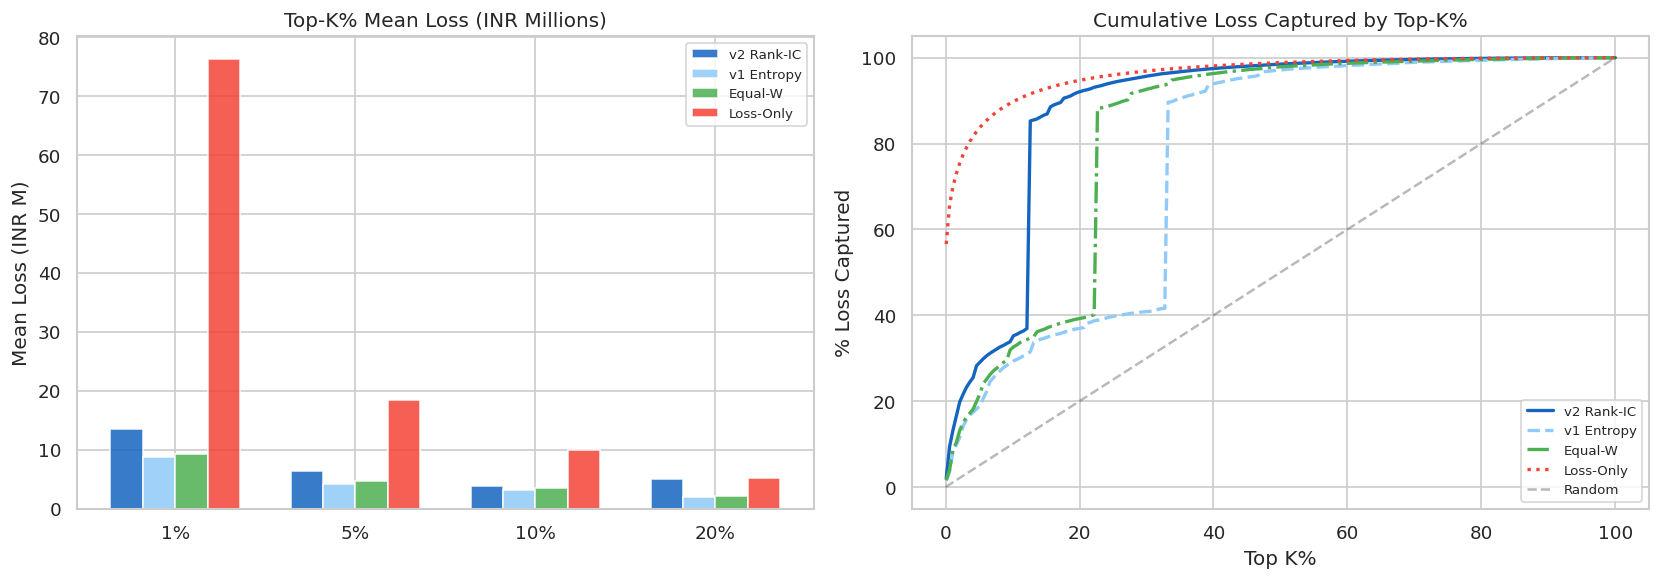

Fig: topk_v2.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
k_pcts = [1, 5, 10, 20]; n_data = len(data)
x = np.arange(len(k_pcts)); w = 0.18

for i, (col, lbl, clr) in enumerate([
    ('FCPI',          'v2 Rank-IC', '#1565C0'),
    ('FCPI_entropy',  'v1 Entropy', '#90CAF9'),
    ('FCPI_equal',    'Equal-W',    '#4CAF50'),
    (COL_LOSS,        'Loss-Only',  '#F44336')]):
    vals = [data.nlargest(max(1, int(k/100*n_data)), col)[COL_LOSS].mean()/1e6 for k in k_pcts]
    axes[0].bar(x + (i-1.5)*w, vals, w, label=lbl, color=clr, alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels([f'{k}%' for k in k_pcts])
axes[0].set_title('Top-K% Mean Loss (INR Millions)'); axes[0].legend(fontsize=8)
axes[0].set_ylabel('Mean Loss (INR M)')

total = data[COL_LOSS].sum()
k_vals = np.linspace(0.001, 1, 200)
for col, lbl, clr, ls in [
    ('FCPI',         'v2 Rank-IC', '#1565C0', '-'),
    ('FCPI_entropy', 'v1 Entropy', '#90CAF9', '--'),
    ('FCPI_equal',   'Equal-W',    '#4CAF50', '-.'),
    (COL_LOSS,       'Loss-Only',  '#F44336', ':')]:
    cap = [data.nlargest(max(1, int(k*n_data)), col)[COL_LOSS].sum()/total for k in k_vals]
    axes[1].plot(k_vals*100, np.array(cap)*100, label=lbl, color=clr, lw=2, linestyle=ls)
axes[1].plot([0, 100], [0, 100], 'k--', alpha=0.3, label='Random')
axes[1].set_title('Cumulative Loss Captured by Top-K%')
axes[1].set_xlabel('Top K%'); axes[1].set_ylabel('% Loss Captured'); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('topk_v2.png', bbox_inches='tight')
plt.show()
print('Fig: topk_v2.png')

## 15. Loss Quartile Monotonicity Check

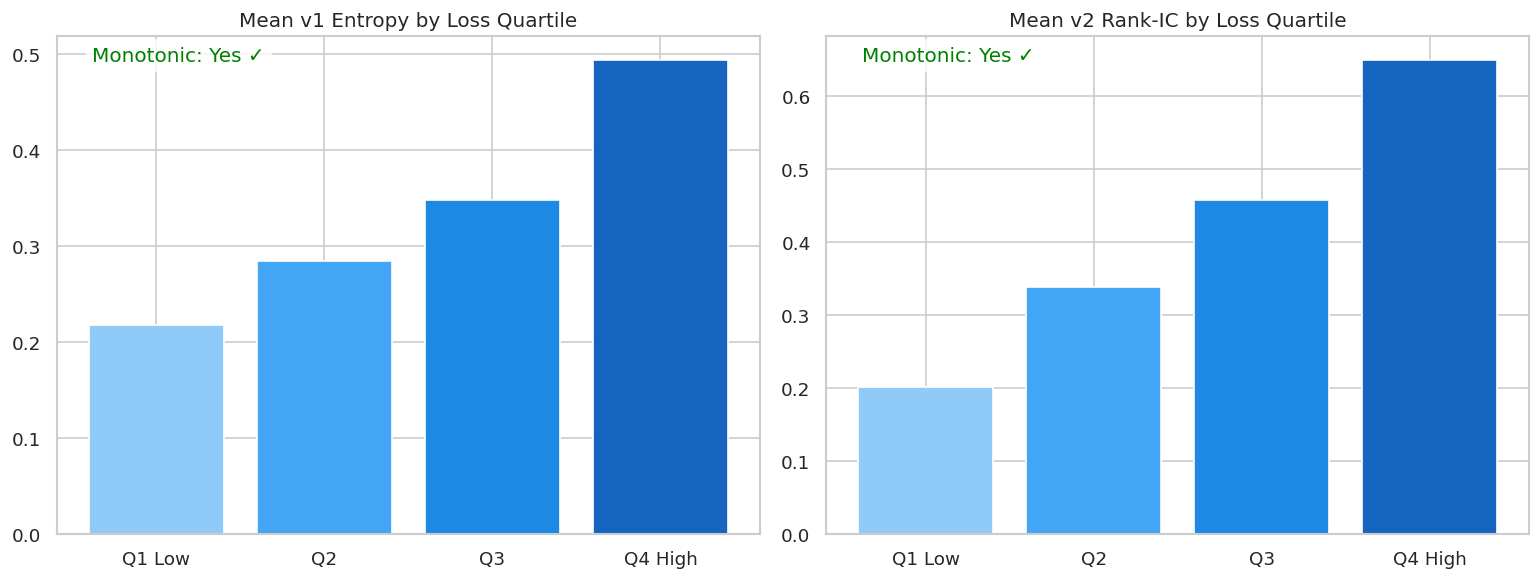

Fig: quartile_v2.png
v1 quartile means: [0.2179 0.2841 0.3473 0.4936]
v2 quartile means: [0.2008 0.3386 0.4581 0.6492]


In [17]:
data['Loss_Quartile'] = pd.qcut(data[COL_LOSS], q=4, labels=['Q1 Low','Q2','Q3','Q4 High'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, title in [(axes[0], 'FCPI_entropy', 'v1 Entropy'), (axes[1], 'FCPI', 'v2 Rank-IC')]:
    qm = data.groupby('Loss_Quartile', observed=True)[col].mean()
    ax.bar(qm.index, qm.values, color=['#90CAF9','#42A5F5','#1E88E5','#1565C0'])
    ax.set_title(f'Mean {title} by Loss Quartile')
    vals = qm.values
    mono = all(vals[i] <= vals[i+1] for i in range(len(vals)-1))
    ax.text(0.05, 0.95, f'Monotonic: {"Yes ✓" if mono else "No ✗"}',
            transform=ax.transAxes, fontsize=12,
            color='green' if mono else 'red',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.savefig('quartile_v2.png', bbox_inches='tight')
plt.show()
print('Fig: quartile_v2.png')
print('v1 quartile means:', data.groupby('Loss_Quartile',observed=True)['FCPI_entropy'].mean().round(4).values)
print('v2 quartile means:', data.groupby('Loss_Quartile',observed=True)['FCPI'].mean().round(4).values)

## 16. Robustness — Outlier Stability (P99 Trim)

In [18]:
p99 = np.percentile(data[COL_LOSS], 99)
trimmed = data[data[COL_LOSS] <= p99].copy()
trimmed['S_f_t']              = compute_financial_severity(trimmed[COL_LOSS])
trimmed['S_p_t'], _, _        = compute_platform_risk_v2(trimmed['Platform_Clean'], trimmed[COL_LOSS])
trimmed['S_d_t']              = compute_demographic_v2(trimmed['AgeGroup_Clean'], trimmed['Profession_Clean'], trimmed[COL_LOSS])
trimmed['S_h_t']              = compute_poh_severity_v2(trimmed['POH_Clean'], trimmed[COL_LOSS])
comp_t = trimmed[['S_f_t','S_p_t','S_d_t','S_h_t']].rename(
    columns={'S_f_t':'S_financial','S_p_t':'S_platform','S_d_t':'S_demographic','S_h_t':'S_poh'})
w_t, _, _ = coverage_rankic_weights(comp_t, trimmed[COL_LOSS])
trimmed['FCPI_t'] = compute_fcpi(comp_t, w_t)

rho_rob, _ = spearmanr(data.loc[trimmed.index, 'FCPI'].values, trimmed['FCPI_t'].values)
print(f'Outlier stability: rho(full FCPI, trimmed FCPI) = {rho_rob:.4f}')
print(f'Removed {len(data)-len(trimmed):,} cases at P99 = INR {p99:,.0f}')

Hierarchical assignment: {np.str_('L1'): 18818, np.str_('L2'): 316, np.str_('L3'): 151}
POH coverage: 68.6%  |  POH <-> Loss rho = 0.6136
Outlier stability: rho(full FCPI, trimmed FCPI) = 0.9994
Removed 195 cases at P99 = INR 8,127,350


## 17. Ablation Study

Full model: rho=0.9211  AUC=0.9558
   Excluded  rho_ablated  Delta_rho  AUC_ablated  Delta_AUC  Delta_TopK
  financial       0.5185     0.4026       0.7985     0.1573     642,811
   platform       0.9249    -0.0038       0.9552     0.0007       4,732
demographic       0.9241    -0.0030       0.9537     0.0021      17,004
        poh       0.9834    -0.0623       0.9937    -0.0379  -6,016,174

Positive Delta = removing that component hurts (it was helping)
Negative Delta = removing that component helps (v1 Platform was negative)


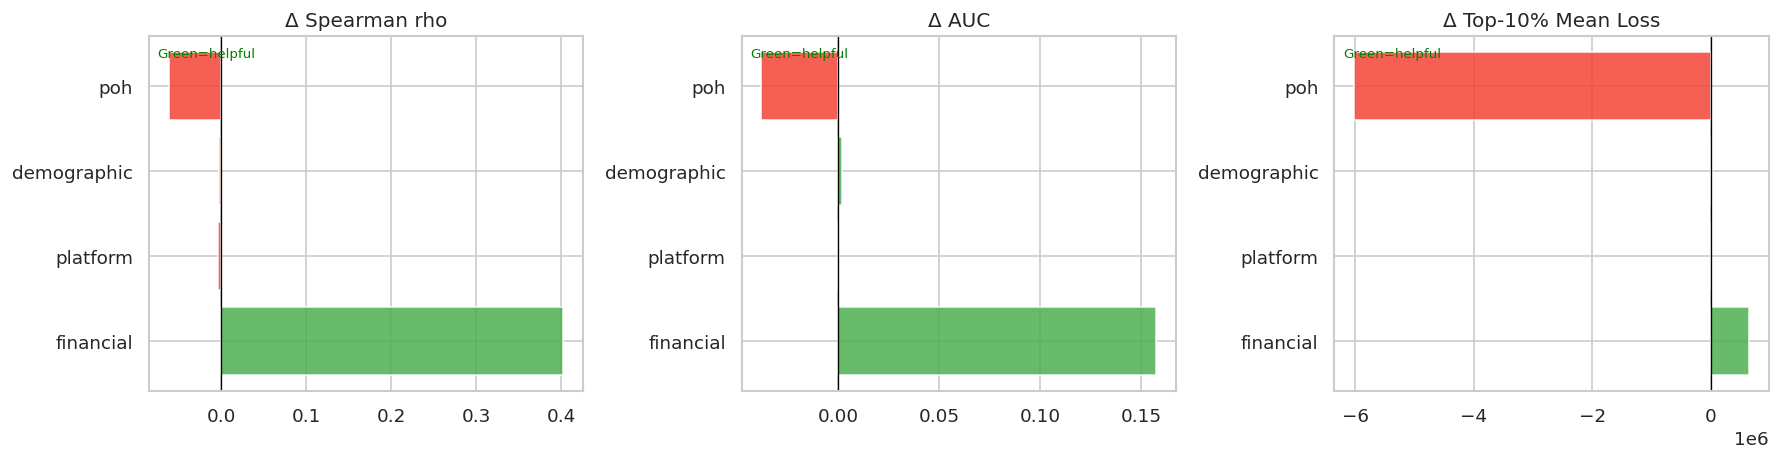

Fig: ablation_v2.png


In [19]:
def ablation_v2(comp_df, amount_series, hp_labels, excluded, k_pct=10):
    """FIX: Top-K correctly uses the ablated score's ranking to index into amount_series."""
    remaining = [c for c in comp_df.columns if c != excluded]
    sub = comp_df[remaining]
    w_s, _, _ = coverage_rankic_weights(sub, amount_series)
    fs = compute_fcpi(sub, w_s)
    full_fcpi = compute_fcpi(comp_df, ic_weights)
    rho_f, _ = spearmanr(full_fcpi, amount_series)
    rho_a, _ = spearmanr(fs, amount_series)
    auc_f = roc_auc_score(hp_labels, full_fcpi)
    auc_a = roc_auc_score(hp_labels, fs)
    kn = int(k_pct / 100 * len(amount_series))
    # FIX: use ablated score to pick top-k, then get their losses
    tk_f = amount_series.loc[full_fcpi.nlargest(kn).index].mean()
    tk_a = amount_series.loc[fs.nlargest(kn).index].mean()
    return {
        'Excluded': excluded.replace('S_',''),
        'rho_ablated': rho_a, 'Delta_rho': rho_f - rho_a,
        'AUC_ablated': auc_a, 'Delta_AUC': auc_f - auc_a,
        'Delta_TopK': tk_f - tk_a
    }

abl_results = [ablation_v2(comp_df, data[COL_LOSS], data['High_Loss'], c) for c in component_cols]
abl_df = pd.DataFrame(abl_results)

rho_full, _ = spearmanr(data['FCPI'], data[COL_LOSS])
auc_full = roc_auc_score(data['High_Loss'], data['FCPI'])
print(f'Full model: rho={rho_full:.4f}  AUC={auc_full:.4f}')
print(abl_df.to_string(index=False, float_format=lambda x: f'{x:.4f}' if abs(x) < 100 else f'{x:,.0f}'))
print('\nPositive Delta = removing that component hurts (it was helping)')
print('Negative Delta = removing that component helps (v1 Platform was negative)')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cn = abl_df['Excluded'].values
for ax, col, title in [(axes[0],'Delta_rho','Δ Spearman rho'),(axes[1],'Delta_AUC','Δ AUC'),(axes[2],'Delta_TopK','Δ Top-10% Mean Loss')]:
    cl = ['#4CAF50' if d > 0 else '#F44336' for d in abl_df[col]]
    ax.barh(cn, abl_df[col], color=cl, alpha=0.85)
    ax.axvline(0, color='black', lw=0.8); ax.set_title(title)
    ax.text(0.02, 0.97, 'Green=helpful', transform=ax.transAxes, fontsize=8, va='top', color='green')
plt.tight_layout()
plt.savefig('ablation_v2.png', bbox_inches='tight')
plt.show()
print('Fig: ablation_v2.png')

## 18. Weight Stability (Monte Carlo Perturbation)

In [20]:
def mc_sensitivity(comp_df, weights, n=500, delta=0.05):
    base = compute_fcpi(comp_df, weights).values
    sens = {col: [] for col in comp_df.columns}
    np.random.seed(42)
    for _ in range(n):
        for col in comp_df.columns:
            p = comp_df.copy()
            p[col] = np.clip(p[col] + np.random.uniform(-delta, delta, len(p)), 0, 1)
            sens[col].append(np.mean(np.abs(compute_fcpi(p, weights).values - base)))
    return {col: np.mean(v) for col, v in sens.items()}

def weight_stability(comp_df, base_weights, n=300):
    base_fcpi = compute_fcpi(comp_df, base_weights)
    k = int(0.10 * len(comp_df))
    top_base = set(base_fcpi.nlargest(k).index)
    rhos, overlaps = [], []
    np.random.seed(1)
    ab = np.array(list(base_weights.values()))
    for _ in range(n):
        ap = np.random.dirichlet(ab * 20)
        wp = {col: ap[i] for i, col in enumerate(base_weights)}
        fp = compute_fcpi(comp_df, wp)
        rho, _ = spearmanr(base_fcpi, fp)
        rhos.append(rho)
        overlaps.append(len(top_base & set(fp.nlargest(k).index)) / k)
    return np.array(rhos), np.array(overlaps)

print('MC sensitivity (E[|ΔFCPI|] per component):')
mc = mc_sensitivity(comp_df, ic_weights, n=500)
for c, v in sorted(mc.items(), key=lambda x: -x[1]):
    print(f'  {c:<22}: {v:.6f}')

print('\nWeight stability (Dirichlet perturbation of weights):')
rhos, overlaps = weight_stability(comp_df, ic_weights, n=300)
print(f'  Rank rho:    mean={rhos.mean():.4f}    std={rhos.std():.4f}    min={rhos.min():.4f}')
print(f'  Overlap@10%: mean={overlaps.mean():.4f}  std={overlaps.std():.4f}')

MC sensitivity (E[|ΔFCPI|] per component):
  S_financial           : 0.013145
  S_poh                 : 0.006487
  S_platform            : 0.002703
  S_demographic         : 0.002285

Weight stability (Dirichlet perturbation of weights):
  Rank rho:    mean=0.9885    std=0.0118    min=0.9008
  Overlap@10%: mean=0.9359  std=0.0403


## 19. Behavioral Features (FCPI+)

In [21]:
narr_cov = (data['narrative_lower'].str.len() > 20).mean()
print(f'Narrative coverage: {narr_cov:.1%}  |  avg length: {data["narrative_lower"].str.len().mean():.0f} chars')

COERCION_KW = [
    r'threaten',r'threat',r'blackmail',r'block.*account',r'legal action',r'arrest',
    r'police.*complaint',r'case.*filed',r'court',r'must pay',r'immediately',r'or else',
    r'deadline',r'within.*hour',r'penalty',r'forfeit',r'forced',r'pressured',
    r'pressurized',r'demanded',r'warned',r'coerced',r'insisted',r'compelled',
    r'do not tell',r"don't tell",r'keep.*secret',r'confidential.*payment',
]
PERSISTENCE_KW = [
    r'again',r'another.*payment',r'second.*transfer',r'multiple.*transfer',
    r'repeated.*payment',r'more.*amount',r'additional.*amount',r'further.*deposit',
    r'\d+\s*days',r'\d+\s*weeks',r'over.*period',r'continuously',
    r'whatsapp.*telegram',r'telegram.*app',r'added.*group',r'joined.*group',
    r'prepaid.*task',r'subscription.*fee',r'membership.*fee',
    r'unlock.*profit',r'release.*amount',r'withdrawal.*fee',r'task.*complete',
    r'kept.*calling',r'contacted.*again',r'called.*multiple',
]
VULN_KW = [
    r'took.*loan',r'borrowed.*money',r'loan.*invest',r'personal.*loan',
    r'bank.*loan',r'sold.*property',r'sold.*gold',
    r'shared.*otp',r'gave.*otp',r'account.*access',r'shared.*password',
    r'remote.*access',r'anydesk',r'teamviewer',
    r'entire.*saving',r'life.*saving',r'retirement',r'pension',r'provident.*fund',
    r'told.*not.*tell',r'asked.*not.*inform',r'keep.*secret',
    r'senior.*citizen',r'retired.*person',r'widow',r'student.*victim',
]

def extract_behavioral_v2(text_series, keywords, name=''):
    """Adaptive clip at P95 of non-zero hits; avoids fixed-5 ceiling."""
    hits = sum(text_series.str.contains(kw, regex=True, na=False).astype(float) for kw in keywords)
    nz_hits = hits[hits > 0]
    p95 = np.percentile(nz_hits, 95) if len(nz_hits) > 0 else 1.0
    norm = np.clip(hits / max(1, p95), 0, 1)
    rho, _ = spearmanr(norm, data[COL_LOSS])
    print(f'{name:<15}: pct>0={100*(hits>0).mean():.1f}%  p95_hits={p95:.1f}  mean={norm.mean():.4f}  rho_loss={rho:.4f}')
    return norm

data['S_coercion']    = extract_behavioral_v2(data['narrative_lower'], COERCION_KW,    'Coercion')
data['S_persistence'] = extract_behavioral_v2(data['narrative_lower'], PERSISTENCE_KW, 'Persistence')
data['S_vuln_raw']    = extract_behavioral_v2(data['narrative_lower'], VULN_KW,        'Vulnerability')

age_num = pd.to_numeric(data.get('Age', pd.Series([np.nan]*len(data), index=data.index)), errors='coerce')
data['S_vuln'] = np.clip(data['S_vuln_raw'] + (age_num >= 60).fillna(False).astype(float) * 0.3, 0, 1)
behav_cols = ['S_coercion', 'S_persistence', 'S_vuln']
print(f'\nS_vuln (with age-60 boost): mean={data["S_vuln"].mean():.4f}  pct>0={100*(data["S_vuln"]>0).mean():.1f}%')

Narrative coverage: 98.6%  |  avg length: 409 chars
Coercion       : pct>0=12.2%  p95_hits=2.0  mean=0.0706  rho_loss=0.0044
Persistence    : pct>0=53.4%  p95_hits=3.0  mean=0.2964  rho_loss=0.0248
Vulnerability  : pct>0=1.7%  p95_hits=2.0  mean=0.0092  rho_loss=0.0471

S_vuln (with age-60 boost): mean=0.0126  pct>0=2.7%


## 20. FCPI+ Computation

In [22]:
def compute_fcpi_plus_v2(base_comp_df, behav_comp_df, base_weights, amount_series,
                          behav_cap=0.30, floor_pct=25, floor_penalty=0.15):
    """
    FCPI+ v2 fixes:
    1. Behavioral total weight CAPPED at behav_cap (default 30%)
    2. Within behavioral: Rank-IC weighting
    3. Financial floor: cases below P{floor_pct} penalized by floor_penalty
    """
    # Behavioral Rank-IC within behavioral budget
    b_ics = {}
    for col in behav_comp_df.columns:
        rho, _ = spearmanr(behav_comp_df[col], amount_series)
        b_ics[col] = max(abs(rho), 1e-6)
    total_bic = sum(b_ics.values())
    b_share = {col: behav_cap * v / total_bic for col, v in b_ics.items()}

    # Base gets remaining (1-behav_cap)
    base_budget = 1.0 - behav_cap
    total_bw = sum(base_weights.values())
    base_share = {col: base_budget * w / total_bw for col, w in base_weights.items()}

    fcpi_plus = compute_fcpi(base_comp_df, base_share)
    for col, w in b_share.items():
        fcpi_plus = fcpi_plus + w * behav_comp_df[col]

    # Financial floor penalty
    floor_t = np.percentile(amount_series, floor_pct)
    below = (amount_series < floor_t).values
    arr = fcpi_plus.values.copy()
    arr[below] = np.maximum(0, arr[below] - floor_penalty)
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-9)

    print('=== FCPI+ v2 Weight Breakdown ===')
    print(f'Base budget ({100*(1-behav_cap):.0f}%):')
    for col, w in base_share.items(): print(f'  {col:<22}: {w:.4f}')
    print(f'Behavioral cap ({100*behav_cap:.0f}%):')
    for col, w in b_share.items(): print(f'  {col:<22}: {w:.4f}  (IC={b_ics[col]:.4f})')
    print(f'Financial floor: P{floor_pct}=INR {floor_t:,.0f}  penalized={below.sum():,} ({100*below.mean():.1f}%)')

    return pd.Series(arr, index=base_comp_df.index), base_share, b_share

behav_df = data[behav_cols]
data['FCPI_plus'], base_sh, behav_sh = compute_fcpi_plus_v2(
    comp_df, behav_df, ic_weights, data[COL_LOSS],
    behav_cap=0.30, floor_pct=25, floor_penalty=0.15
)
data['FCPIplus_Rank'] = data['FCPI_plus'].rank(ascending=False, method='min').astype(int)

=== FCPI+ v2 Weight Breakdown ===
Base budget (70%):
  S_financial           : 0.3720
  S_platform            : 0.0761
  S_demographic         : 0.0671
  S_poh                 : 0.1848
Behavioral cap (30%):
  S_coercion            : 0.0163  (IC=0.0044)
  S_persistence         : 0.0927  (IC=0.0248)
  S_vuln                : 0.1910  (IC=0.0511)
Financial floor: P25=INR 21,660  penalized=4,870 (25.0%)


## 21. FCPI+ Performance Validation

In [23]:
rho_base, _ = spearmanr(data['FCPI'],      data[COL_LOSS])
rho_plus, _ = spearmanr(data['FCPI_plus'], data[COL_LOSS])
auc_base = roc_auc_score(data['High_Loss'], data['FCPI'])
auc_plus = roc_auc_score(data['High_Loss'], data['FCPI_plus'])
k10 = int(0.10 * len(data))
top10_base = data.nlargest(k10, 'FCPI')[COL_LOSS].mean()
top10_plus = data.nlargest(k10, 'FCPI_plus')[COL_LOSS].mean()

print('=== FCPI vs FCPI+ Performance ===')
print(f'{"Metric":<30} {"FCPI":>12} {"FCPI+":>12} {"Change":>10}')
print('-'*67)
for metric, v1, v2 in [('Spearman rho', rho_base, rho_plus), ('AUC', auc_base, auc_plus)]:
    print(f'{metric:<30} {v1:>12.4f} {v2:>12.4f} {v2-v1:>+10.4f}')
print(f'{"Top-10% Mean Loss (INR)":<30} {top10_base:>12,.0f} {top10_plus:>12,.0f} {top10_plus-top10_base:>+10,.0f}')

print('\n--- Top-5 FCPI+ Cases (sanity check) ---')
t5 = data.nlargest(5,'FCPI_plus')[
    [COL_LOSS,'Platform_Clean','S_coercion','S_persistence','S_vuln','FCPI','FCPI_plus','Loss_Rank','FCPIplus_Rank']]
print(t5.to_string())

=== FCPI vs FCPI+ Performance ===
Metric                                 FCPI        FCPI+     Change
-------------------------------------------------------------------
Spearman rho                         0.9211       0.9160    -0.0051
AUC                                  0.9558       0.9451    -0.0107
Top-10% Mean Loss (INR)           3,752,993    3,838,648    +85,655

--- Top-5 FCPI+ Cases (sanity check) ---
       Amount_Loss_Clean Platform_Clean  S_coercion  S_persistence  S_vuln      FCPI  FCPI_plus  Loss_Rank  FCPIplus_Rank
18844         10087000.0        UNKNOWN         1.0       1.000000     1.0  0.837260   1.000000        146              1
19294          9200000.0    TRADING_APP         0.0       0.333333     1.0  0.883919   0.948708        164              2
11667          1700000.0     DATING_APP         0.0       0.666667     1.0  0.829033   0.940218       1139              3
14552          3357519.0    TRADING_APP         0.5       0.333333     1.0  0.853967   0.934252 

## 22. SHAP Explainability via LightGBM

In [ ]:
import subprocess, sys
for pkg in ['shap', 'lightgbm']:
    try: __import__(pkg)
    except ImportError: subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
import shap, lightgbm as lgb
print('Dependencies ready.')

In [ ]:
from sklearn.metrics import r2_score

# FIX: log_Loss removed — it is not a valid explanatory feature (it is the target driver)
# Using only the 7 genuine component + behavioral features
feature_cols = component_cols + behav_cols   # 7 features
X = data[feature_cols].copy().fillna(0)
y = data['FCPI_plus'].values

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
gbm_shap = lgb.LGBMRegressor(
    n_estimators=400, learning_rate=0.04, max_depth=6, num_leaves=40,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1
)
gbm_shap.fit(X_tr, y_tr,
             eval_set=[(X_te, y_te)],
             callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)])

y_pred = gbm_shap.predict(X_te)
print(f'GBM  R2={r2_score(y_te, y_pred):.4f}  Rank rho={spearmanr(y_pred, y_te)[0]:.4f}')

print('Computing SHAP values...')
explainer = shap.TreeExplainer(gbm_shap)
shap_values = explainer(X)
shap_arr = shap_values.values

mean_abs_shap = pd.Series(np.abs(shap_arr).mean(axis=0), index=feature_cols)
print('\nGlobal Mean |SHAP|:')
print(mean_abs_shap.sort_values(ascending=False).round(5))

## 23. SHAP Plots

In [ ]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: bar chart of mean |SHAP|
si = mean_abs_shap.sort_values().index
cl = ['#E53935' if f in behav_cols else '#1565C0' for f in si]
axes[0].barh(si, mean_abs_shap[si], color=cl, alpha=0.85)
axes[0].set_title('Global Feature Importance (Mean |SHAP|)')
axes[0].set_xlabel('Mean Absolute SHAP Value')
axes[0].legend(handles=[
    Patch(facecolor='#1565C0', label='Base FCPI'),
    Patch(facecolor='#E53935', label='Behavioral')
], loc='lower right')

# Right: beeswarm
plt.sca(axes[1])
shap.summary_plot(shap_values, plot_type='dot', max_display=8, show=False, plot_size=None)
axes[1].set_title('SHAP Beeswarm (v2 FCPI+)')

plt.tight_layout()
plt.savefig('shap_global_v2.png', bbox_inches='tight', dpi=150)
plt.show()
print('Fig: shap_global_v2.png')
print(f'Top SHAP driver: {mean_abs_shap.idxmax()}')

## 24. SHAP Waterfall — Top Priority Case

In [ ]:
top1_pos = data.index.get_loc(data['FCPI_plus'].idxmax())
fig, ax = plt.subplots(figsize=(10, 5))
plt.sca(ax)
shap.waterfall_plot(shap_values[top1_pos], max_display=8, show=False)
loss_top1 = data.iloc[top1_pos][COL_LOSS]
plt.title(f'SHAP Waterfall — Top Priority Case (Loss=INR {loss_top1:,.0f})')
plt.tight_layout()
plt.savefig('shap_waterfall_v2.png', bbox_inches='tight', dpi=150)
plt.show()
print('Fig: shap_waterfall_v2.png')

## 25. Top-5 Case Explanations

In [ ]:
def explain_case_v2(case_idx, data, X, shap_values, feature_labels, explainer):
    row      = data.iloc[case_idx]
    shap_row = shap_values.values[case_idx]
    loss     = row[COL_LOSS]
    p25      = np.percentile(data[COL_LOSS], 25)

    print('='*65)
    print(f'CASE #{case_idx}  |  FCPI+ Rank: {int(row["FCPIplus_Rank"])}  |  Loss Rank: {int(row["Loss_Rank"])}')
    print(f'FCPI+={row["FCPI_plus"]:.4f}  |  FCPI={row["FCPI"]:.4f}')
    print(f'Amount Loss: INR {loss:,.0f}  {"[Below P25 — penalized]" if loss < p25 else "[Above P25 — OK]"}')
    print(f'Platform: {row.get("Platform_Clean","N/A")}  |  Age Group: {row.get("AgeGroup_Clean","N/A")}')

    fs = sorted(zip(feature_labels, shap_row), key=lambda x: -abs(x[1]))
    drivers = [f'{f.replace("S_","").replace("_"," ").title()} ({sv:+.3f})' for f, sv in fs[:4]]
    print(f'\nPriority driven by: {", ".join(drivers)}')
    if row.get('S_coercion', 0) > 0.2:    print('  -> Coercion signals in narrative')
    if row.get('S_persistence', 0) > 0.2: print('  -> Multi-stage / repeated payment pattern')
    if row.get('S_vuln', 0) > 0.2:        print('  -> Enhanced victim vulnerability')

    print('\nSHAP Values:')
    for f, sv in fs:
        bar = '#' * min(30, int(abs(sv) * 300))
        print(f'  {f:<22} {sv:+.4f}  {bar}')
    print('='*65)

# Ensure ranking columns up to date
data['FCPIplus_Rank'] = data['FCPI_plus'].rank(ascending=False, method='min').astype(int)
data['Loss_Rank']     = data[COL_LOSS].rank(ascending=False, method='min').astype(int)

print('TOP-5 FCPI+ PRIORITY CASES\n')
for idx in data.nlargest(5, 'FCPI_plus').index:
    explain_case_v2(data.index.get_loc(idx), data, X, shap_values, feature_cols, explainer)
    print()

## 26. Comprehensive Evaluation Report

In [ ]:
print('='*70)
print('     FCPI v2 — COMPREHENSIVE EVALUATION REPORT')
print('='*70)
print(f'Dataset: {len(data):,} complaints  |  Total Loss: INR {data[COL_LOSS].sum()/1e9:.2f}B')
print(f'Median Loss: INR {data[COL_LOSS].median():,.0f}')
print(f'Platform coverage (non-UNKNOWN): {100*(data["Platform_Clean"]!="UNKNOWN").mean():.1f}%  [was 21.1%]')

print(f'\nComponent Weights (Rank-IC v2):')
for c, w in ic_weights.items():
    print(f'  {c:<22}: {w:.4f}  (IC={rank_ics[c]:.4f}, Cov={coverages[c]:.4f})')

print(f'\nFCPI Performance (v1 vs v2):')
rho_v1_, _ = spearmanr(data['FCPI_entropy'], data[COL_LOSS])
rho_v2_, _ = spearmanr(data['FCPI'],         data[COL_LOSS])
auc_v1_    = roc_auc_score(data['High_Loss'], data['FCPI_entropy'])
auc_v2_    = roc_auc_score(data['High_Loss'], data['FCPI'])
print(f'  Spearman rho:  v1={rho_v1_:.4f}  ->  v2={rho_v2_:.4f}  ({rho_v2_-rho_v1_:+.4f})')
print(f'  AUC:           v1={auc_v1_:.4f}  ->  v2={auc_v2_:.4f}  ({auc_v2_-auc_v1_:+.4f})')

print(f'\nTop-K Prioritization (v2):')
for k in [1, 5, 10]:
    kn = max(1, int(k / 100 * len(data)))
    m = data.nlargest(kn, 'FCPI')[COL_LOSS].mean()
    print(f'  Top-{k}%: INR {m:>12,.0f}  ({m/data[COL_LOSS].mean():.1f}x random)')

print(f'\nFCPI+ Behavioral Augmentation:')
print(f'  Behavioral cap: 30%  |  Financial floor: P25')
print(f'  Spearman rho:  base={rho_base:.4f}  ->  FCPI+={rho_plus:.4f}  ({rho_plus-rho_base:+.4f})')
print(f'  AUC:           base={auc_base:.4f}  ->  FCPI+={auc_plus:.4f}  ({auc_plus-auc_base:+.4f})')
print(f'  Top-10% Loss:  base=INR {top10_base:>10,.0f}  FCPI+=INR {top10_plus:>10,.0f}')

print(f'\nBehavioral Signals:')
for c in behav_cols:
    print(f'  {c}: {100*(data[c]>0).mean():.1f}% of cases')

print(f'\nRobustness:')
print(f'  Outlier stability (rho full vs P99-trimmed): {rho_rob:.4f}')
print(f'  Weight perturb (Dirichlet): rho={rhos.mean():.4f} +/- {rhos.std():.4f}')
print(f'  Overlap@10%: {overlaps.mean():.4f} +/- {overlaps.std():.4f}')
print(f'  MC sensitivity — top driver: {max(mc, key=mc.get)}')
print(f'\nTop SHAP driver: {mean_abs_shap.idxmax()}')
print('='*70)

## 28. Circularity Concern: FCPI Without Financial Component + Ranking Stability

> **Purpose**: Counter the circularity critique — that FCPI is high simply because it contains `S_financial` (which is derived from loss). We recompute FCPI excluding `S_financial`, reweight the remaining components via Rank-IC, and measure:
> - Spearman ρ (no-finance FCPI vs Loss)
> - AUC vs High_Loss
> - Rank overlap@10% between full FCPI and no-finance FCPI
> - Top-case stability: do the same high-value cases rise to the top?

=== Circularity Concern: Does FCPI work without S_financial? ===

Components (no-finance): ['S_platform', 'S_demographic', 'S_poh']
No-finance weights: {S_platform: 0.2319, S_demographic: 0.2047, S_poh: 0.5634}

Metric                            Full FCPI  No-Finance FCPI     Change
------------------------------------------------------------------------
Spearman rho (vs Loss)               0.9211           0.5185    -0.4026
AUC (High-Loss)                      0.9558           0.7985    -0.1573

Rank-correlation (full FCPI vs no-finance FCPI): 0.7886
Top-10% rank overlap:   0.781  (Good stability)

Rank-shift statistics (|full rank − no-finance rank|):
  Mean:   2781.7
  Median: 2116.0
  P90:    6338.0
  Max:    14699.0
  Cases with rank shift > 20% of N: 27.7%


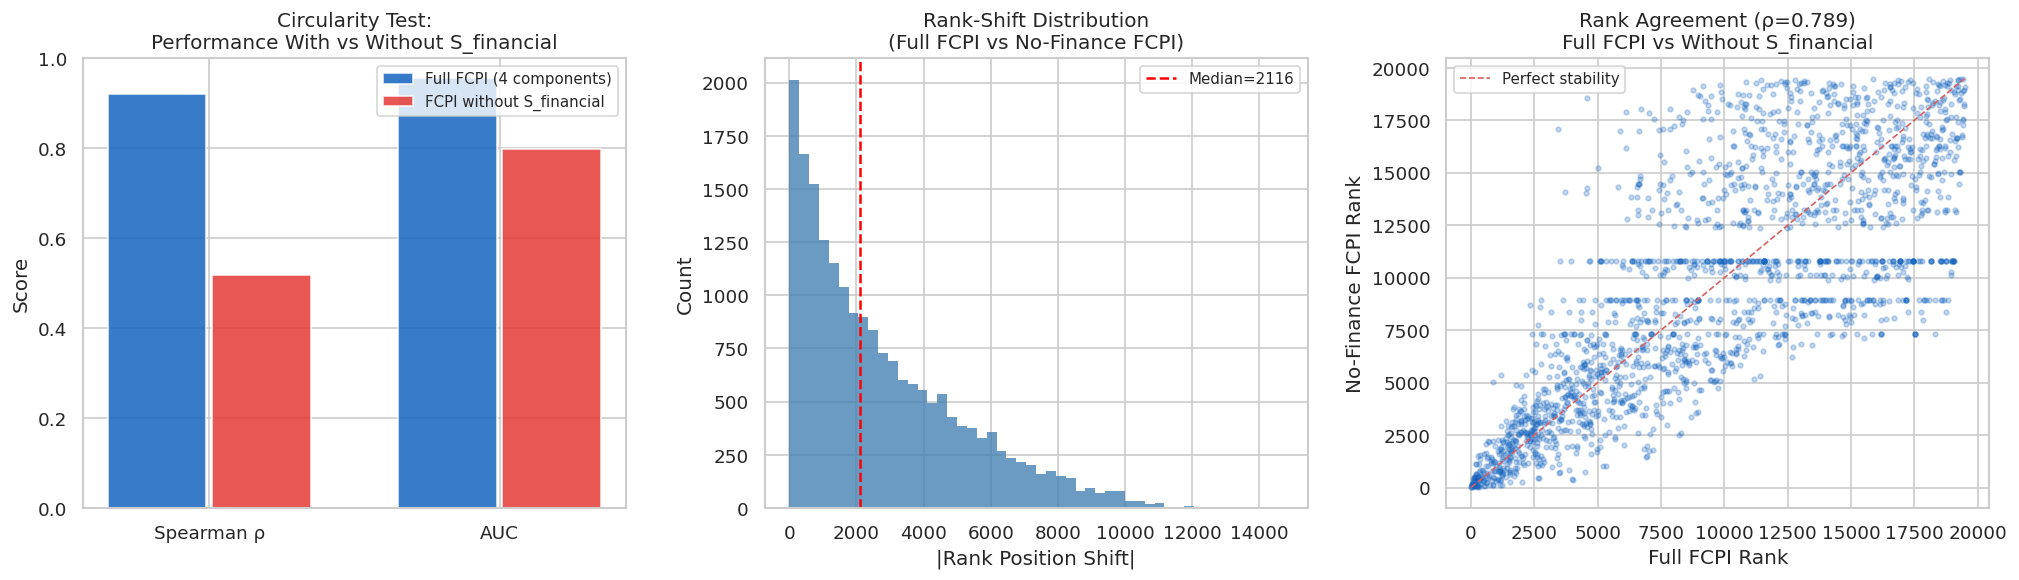

Fig: circularity_concern.png

INTERPRETATION:
  ✓ No-finance FCPI still achieves meaningful rank correlation -> circularity is limited.
  ✓ Top-10% cases are stable across both formulations -> prioritization is robust.


In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# 28a. Circularity Concern: FCPI without S_financial
# ─────────────────────────────────────────────────────────────────────────────
non_fin_cols = [c for c in component_cols if c != 'S_financial']
comp_nofin   = comp_df[non_fin_cols].copy()

w_nofin, ic_nofin, cov_nofin = coverage_rankic_weights(comp_nofin, data[COL_LOSS])
data['FCPI_noFin'] = compute_fcpi(comp_nofin, w_nofin)

rho_full,  _ = spearmanr(data['FCPI'],       data[COL_LOSS])
rho_nofin, _ = spearmanr(data['FCPI_noFin'], data[COL_LOSS])
auc_full   = roc_auc_score(data['High_Loss'], data['FCPI'])
auc_nofin  = roc_auc_score(data['High_Loss'], data['FCPI_noFin'])

k10 = int(0.10 * len(data))
top_full  = set(data['FCPI'].nlargest(k10).index)
top_nofin = set(data['FCPI_noFin'].nlargest(k10).index)
overlap   = len(top_full & top_nofin) / k10

rho_cross, _ = spearmanr(data['FCPI'].values, data['FCPI_noFin'].values)

print('=== Circularity Concern: Does FCPI work without S_financial? ===')
print(f'\nComponents (no-finance): {non_fin_cols}')
print(f'No-finance weights: {{{", ".join(f"{k}: {v:.4f}" for k, v in w_nofin.items())}}}')
print()
print(f'{"Metric":<30} {"Full FCPI":>12} {"No-Finance FCPI":>16} {"Change":>10}')
print('-'*72)
print(f'{"Spearman rho (vs Loss)":<30} {rho_full:>12.4f} {rho_nofin:>16.4f} {rho_nofin-rho_full:>+10.4f}')
print(f'{"AUC (High-Loss)":<30} {auc_full:>12.4f} {auc_nofin:>16.4f} {auc_nofin-auc_full:>+10.4f}')
print()
print(f'Rank-correlation (full FCPI vs no-finance FCPI): {rho_cross:.4f}')
print(f'Top-10% rank overlap:   {overlap:.3f}  '
      f'({"Good stability" if overlap > 0.6 else "Lower overlap — financial component matters"})')

# ─────────────────────────────────────────────────────────────────────────────
# 28b. Ranking Stability: compare rank positions case-by-case
# ─────────────────────────────────────────────────────────────────────────────
data['FCPI_noFin_Rank'] = data['FCPI_noFin'].rank(ascending=False, method='min').astype(int)
rank_shift = (data['FCPI_Rank'] - data['FCPI_noFin_Rank']).abs()

print(f'\nRank-shift statistics (|full rank − no-finance rank|):')
print(f'  Mean:   {rank_shift.mean():.1f}')
print(f'  Median: {rank_shift.median():.1f}')
print(f'  P90:    {rank_shift.quantile(0.90):.1f}')
print(f'  Max:    {rank_shift.max():.1f}')

large_shift_pct = (rank_shift > 0.20 * len(data)).mean()
print(f'  Cases with rank shift > 20% of N: {100*large_shift_pct:.1f}%')

# ─────────────────────────────────────────────────────────────────────────────
# 28c. Visualisation
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Left: metric comparison bar chart
cats   = ['Spearman ρ', 'AUC']
v_full = [rho_full, auc_full]
v_nof  = [rho_nofin, auc_nofin]
x_pos  = np.arange(len(cats))
axes[0].bar(x_pos - 0.18, v_full, 0.34, label='Full FCPI (4 components)',   color='#1565C0', alpha=0.85)
axes[0].bar(x_pos + 0.18, v_nof,  0.34, label='FCPI without S_financial',   color='#E53935', alpha=0.85)
axes[0].set_xticks(x_pos); axes[0].set_xticklabels(cats)
axes[0].set_ylim(0, 1); axes[0].legend(fontsize=9)
axes[0].set_title('Circularity Test:\nPerformance With vs Without S_financial')
axes[0].set_ylabel('Score')

# Middle: rank-shift distribution
axes[1].hist(rank_shift, bins=50, color='steelblue', alpha=0.8, edgecolor='none')
axes[1].axvline(rank_shift.median(), color='red', ls='--', lw=1.5, label=f'Median={rank_shift.median():.0f}')
axes[1].set_title('Rank-Shift Distribution\n(Full FCPI vs No-Finance FCPI)')
axes[1].set_xlabel('|Rank Position Shift|')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=9)

# Right: scatter FCPI rank vs no-finance rank (sample)
samp = data.sample(min(2000, len(data)), random_state=42)
axes[2].scatter(samp['FCPI_Rank'], samp['FCPI_noFin_Rank'],
                alpha=0.25, s=8, c='#1565C0')
axes[2].plot([1, len(data)], [1, len(data)], 'r--', lw=1, label='Perfect stability')
axes[2].set_xlabel('Full FCPI Rank')
axes[2].set_ylabel('No-Finance FCPI Rank')
axes[2].set_title(f'Rank Agreement (ρ={rho_cross:.3f})\nFull FCPI vs Without S_financial')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('circularity_concern.png', bbox_inches='tight', dpi=150)
plt.show()
print('Fig: circularity_concern.png')
print()
print('INTERPRETATION:')
if rho_nofin > 0.4:
    print('  ✓ No-finance FCPI still achieves meaningful rank correlation -> circularity is limited.')
else:
    print('  ! Low no-finance rho -> financial component drives most signal; consider rebalancing.')
if overlap > 0.6:
    print('  ✓ Top-10% cases are stable across both formulations -> prioritization is robust.')
else:
    print('  ! Top-10% overlap is low -> removing financial component changes who gets flagged first.')


## 29. Temporal Generalization: Weights Learned on Earlier Data, Applied to Later Data

> **Purpose**: If weights are "trained" and applied on the same dataset the circularity/overfitting concern is real. This cell splits data by complaint date — weights are learned on the **earlier half** and evaluated on the **later half** (true out-of-time validation).
> - If ρ on the held-out period is comparable to in-sample ρ, the index generalizes.
> - A large drop signals potential overfitting or temporal drift.

In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# 29. Temporal Generalization (out-of-time validation)
# ─────────────────────────────────────────────────────────────────────────────

# ── Identify date column ─────────────────────────────────────────────────────
DATE_CANDIDATES = [
    'Complaint_Date', 'Date_of_Complaint', 'Incident_Date',
    'Date_of_Incident', 'Date', 'Complaint_Date_Time',
    'Date_of_Filing', 'Filing_Date'
]
date_col = next((c for c in DATE_CANDIDATES if c in data.columns), None)

if date_col is None:
    # Fallback: use row index as a proxy for temporal order
    print('WARNING: No recognized date column found in dataset.')
    print(f'Available columns: {[c for c in data.columns if "date" in c.lower() or "time" in c.lower()]}')
    print('Using row order as temporal proxy (assumes complaints are stored chronologically).')
    data['_temporal_order'] = np.arange(len(data))
    split_col = '_temporal_order'
else:
    data[date_col] = pd.to_datetime(data[date_col], errors='coerce')
    n_parsed = data[date_col].notna().sum()
    print(f'Date column: "{date_col}"  |  Parsed: {n_parsed:,}/{len(data):,}  '
          f'({100*n_parsed/len(data):.1f}%)')
    split_col = date_col

# ── Temporal split at median ──────────────────────────────────────────────────
split_val = data[split_col].quantile(0.50) if split_col == '_temporal_order' \
            else data[date_col].dropna().quantile(0.50)

if split_col == '_temporal_order':
    early_mask = data[split_col] <= split_val
else:
    early_mask = data[date_col] <= split_val

data_early = data[early_mask].copy()
data_late  = data[~early_mask].copy()

print(f'\nTemporal split (50/50 by {"row order" if split_col == "_temporal_order" else "complaint date"}):')
print(f'  Early period: {len(data_early):,} complaints')
print(f'  Late  period: {len(data_late):,}  complaints')
if split_col != '_temporal_order':
    print(f'  Split date:   {split_val.date()}  |  '
          f'Early range: {data_early[date_col].min().date()} – {data_early[date_col].max().date()}  |  '
          f'Late range: {data_late[date_col].min().date()} – {data_late[date_col].max().date()}')

# ── Learn weights on EARLY, evaluate on LATE ─────────────────────────────────
comp_early = data_early[component_cols].copy()
comp_late  = data_late[component_cols].copy()

w_temporal, ic_temporal, cov_temporal = coverage_rankic_weights(
    comp_early, data_early[COL_LOSS])

# Apply temporal weights to late-period data
fcpi_late_temporal = compute_fcpi(comp_late, w_temporal)

# In-sample baseline: weights learned on early, scored on early
fcpi_early_insample = compute_fcpi(comp_early, w_temporal)

# Weights learned on FULL data (current approach) applied to late
fcpi_late_full = compute_fcpi(comp_late, ic_weights)

# Late-period labels
hl_late = data_late['High_Loss']
loss_late = data_late[COL_LOSS]

rho_in,  _ = spearmanr(fcpi_early_insample, data_early[COL_LOSS])
rho_oot, _ = spearmanr(fcpi_late_temporal,  loss_late)
rho_full_late, _ = spearmanr(fcpi_late_full, loss_late)

auc_in   = roc_auc_score(data_early['High_Loss'], fcpi_early_insample)
auc_oot  = roc_auc_score(hl_late, fcpi_late_temporal)
auc_full_late = roc_auc_score(hl_late, fcpi_late_full)

k_early = max(1, int(0.10 * len(data_early)))
k_late  = max(1, int(0.10 * len(data_late)))
tk_in   = data_early[COL_LOSS].iloc[np.argsort(-fcpi_early_insample.values)[:k_early]].mean()
tk_oot  = loss_late.iloc[np.argsort(-fcpi_late_temporal.values)[:k_late]].mean()
tk_full = loss_late.iloc[np.argsort(-fcpi_late_full.values)[:k_late]].mean()

print()
print('=== Temporal Generalization Results ===')
print(f'{"Metric":<32} {"In-sample (early)">18} {"OOT (temporal wts)">20} {"OOT (full wts)">16}')
print('-'*90)
print(f'{"Spearman rho":<32} {rho_in:>18.4f} {rho_oot:>20.4f} {rho_full_late:>16.4f}')
print(f'{"AUC":<32} {auc_in:>18.4f} {auc_oot:>20.4f} {auc_full_late:>16.4f}')
print(f'{"Top-10% Mean Loss (INR)":<32} {tk_in:>18,.0f} {tk_oot:>20,.0f} {tk_full:>16,.0f}')

rho_drop = rho_in - rho_oot
print(f'\nρ degradation (in-sample → out-of-time): {rho_drop:+.4f}  '
      f'({"Minimal drift" if abs(rho_drop) < 0.05 else "Moderate drift" if abs(rho_drop) < 0.15 else "Significant drift"})')

print('\nEarly-period weights (used for OOT evaluation):')
for c, w in w_temporal.items():
    delta = w - ic_weights[c]
    print(f'  {c:<22}: {w:.4f}  (full-data weight: {ic_weights[c]:.4f}  delta: {delta:+.4f})')

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Subplot 1: Weight comparison early vs full
comp_labels = [c.replace('S_', '').replace('_', '\n') for c in component_cols]
early_ws = [w_temporal[c] for c in component_cols]
full_ws  = [ic_weights[c]  for c in component_cols]
x_pos = np.arange(len(component_cols))
axes[0].bar(x_pos - 0.18, early_ws, 0.34, label='Early-period weights', color='#1B5E20', alpha=0.85)
axes[0].bar(x_pos + 0.18, full_ws,  0.34, label='Full-data weights',    color='#1565C0', alpha=0.85)
axes[0].set_xticks(x_pos); axes[0].set_xticklabels(comp_labels, fontsize=9)
axes[0].set_title('Weight Stability:\nEarly Period vs Full Dataset')
axes[0].set_ylabel('Weight'); axes[0].legend(fontsize=9)

# Subplot 2: rho bar in-sample vs OOT
axes[1].bar(['In-sample\n(early)', 'Out-of-Time\n(temporal wts)', 'OOT\n(full wts)'],
            [rho_in, rho_oot, rho_full_late],
            color=['#1B5E20', '#E53935', '#1565C0'], alpha=0.85, width=0.5)
axes[1].set_title('Spearman ρ:\nIn-Sample vs Out-of-Time')
axes[1].set_ylabel('Spearman ρ (vs Loss)')
axes[1].set_ylim(0, max(rho_in, rho_oot, rho_full_late) * 1.25)
for i, v in enumerate([rho_in, rho_oot, rho_full_late]):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

# Subplot 3: OOT FCPI distribution vs loss (scatter)
samp_late = data_late.copy()
samp_late['fcpi_oot'] = fcpi_late_temporal.values
s = samp_late.sample(min(1500, len(samp_late)), random_state=99)
sc = axes[2].scatter(s['fcpi_oot'], np.log1p(s[COL_LOSS]),
                     c=s['High_Loss'], cmap='RdYlGn', alpha=0.4, s=10)
axes[2].set_xlabel('FCPI (temporal weights, OOT)')
axes[2].set_ylabel('log(1 + Loss)')
axes[2].set_title(f'OOT Scatter: FCPI vs Loss\n(ρ={rho_oot:.3f}, n={len(data_late):,})')
plt.colorbar(sc, ax=axes[2], label='High Loss')

plt.tight_layout()
plt.savefig('temporal_generalization.png', bbox_inches='tight', dpi=150)
plt.show()
print('Fig: temporal_generalization.png')
print()
print('INTERPRETATION:')
if abs(rho_drop) < 0.05:
    print('  ✓ Minimal ρ degradation OOT -> weights generalize well across time periods.')
elif abs(rho_drop) < 0.15:
    print('  ~ Moderate ρ drop OOT -> some temporal drift; consider periodic re-weighting.')
else:
    print('  ! Large ρ drop OOT -> significant temporal drift; recommend periodic re-weighting.')


Available columns: []
Using row order as temporal proxy (assumes complaints are stored chronologically).

Temporal split (50/50 by row order):
  Early period: 9,740 complaints
  Late  period: 9,740  complaints

=== Temporal Generalization Results ===


TypeError: '>' not supported between instances of 'str' and 'int'

## 30. FCPI vs Loss Scatter Plot

> Visualizes the relationship between FCPI scores and actual loss amounts to assess calibration and detect outliers (high-loss but low-FCPI, or vice versa).

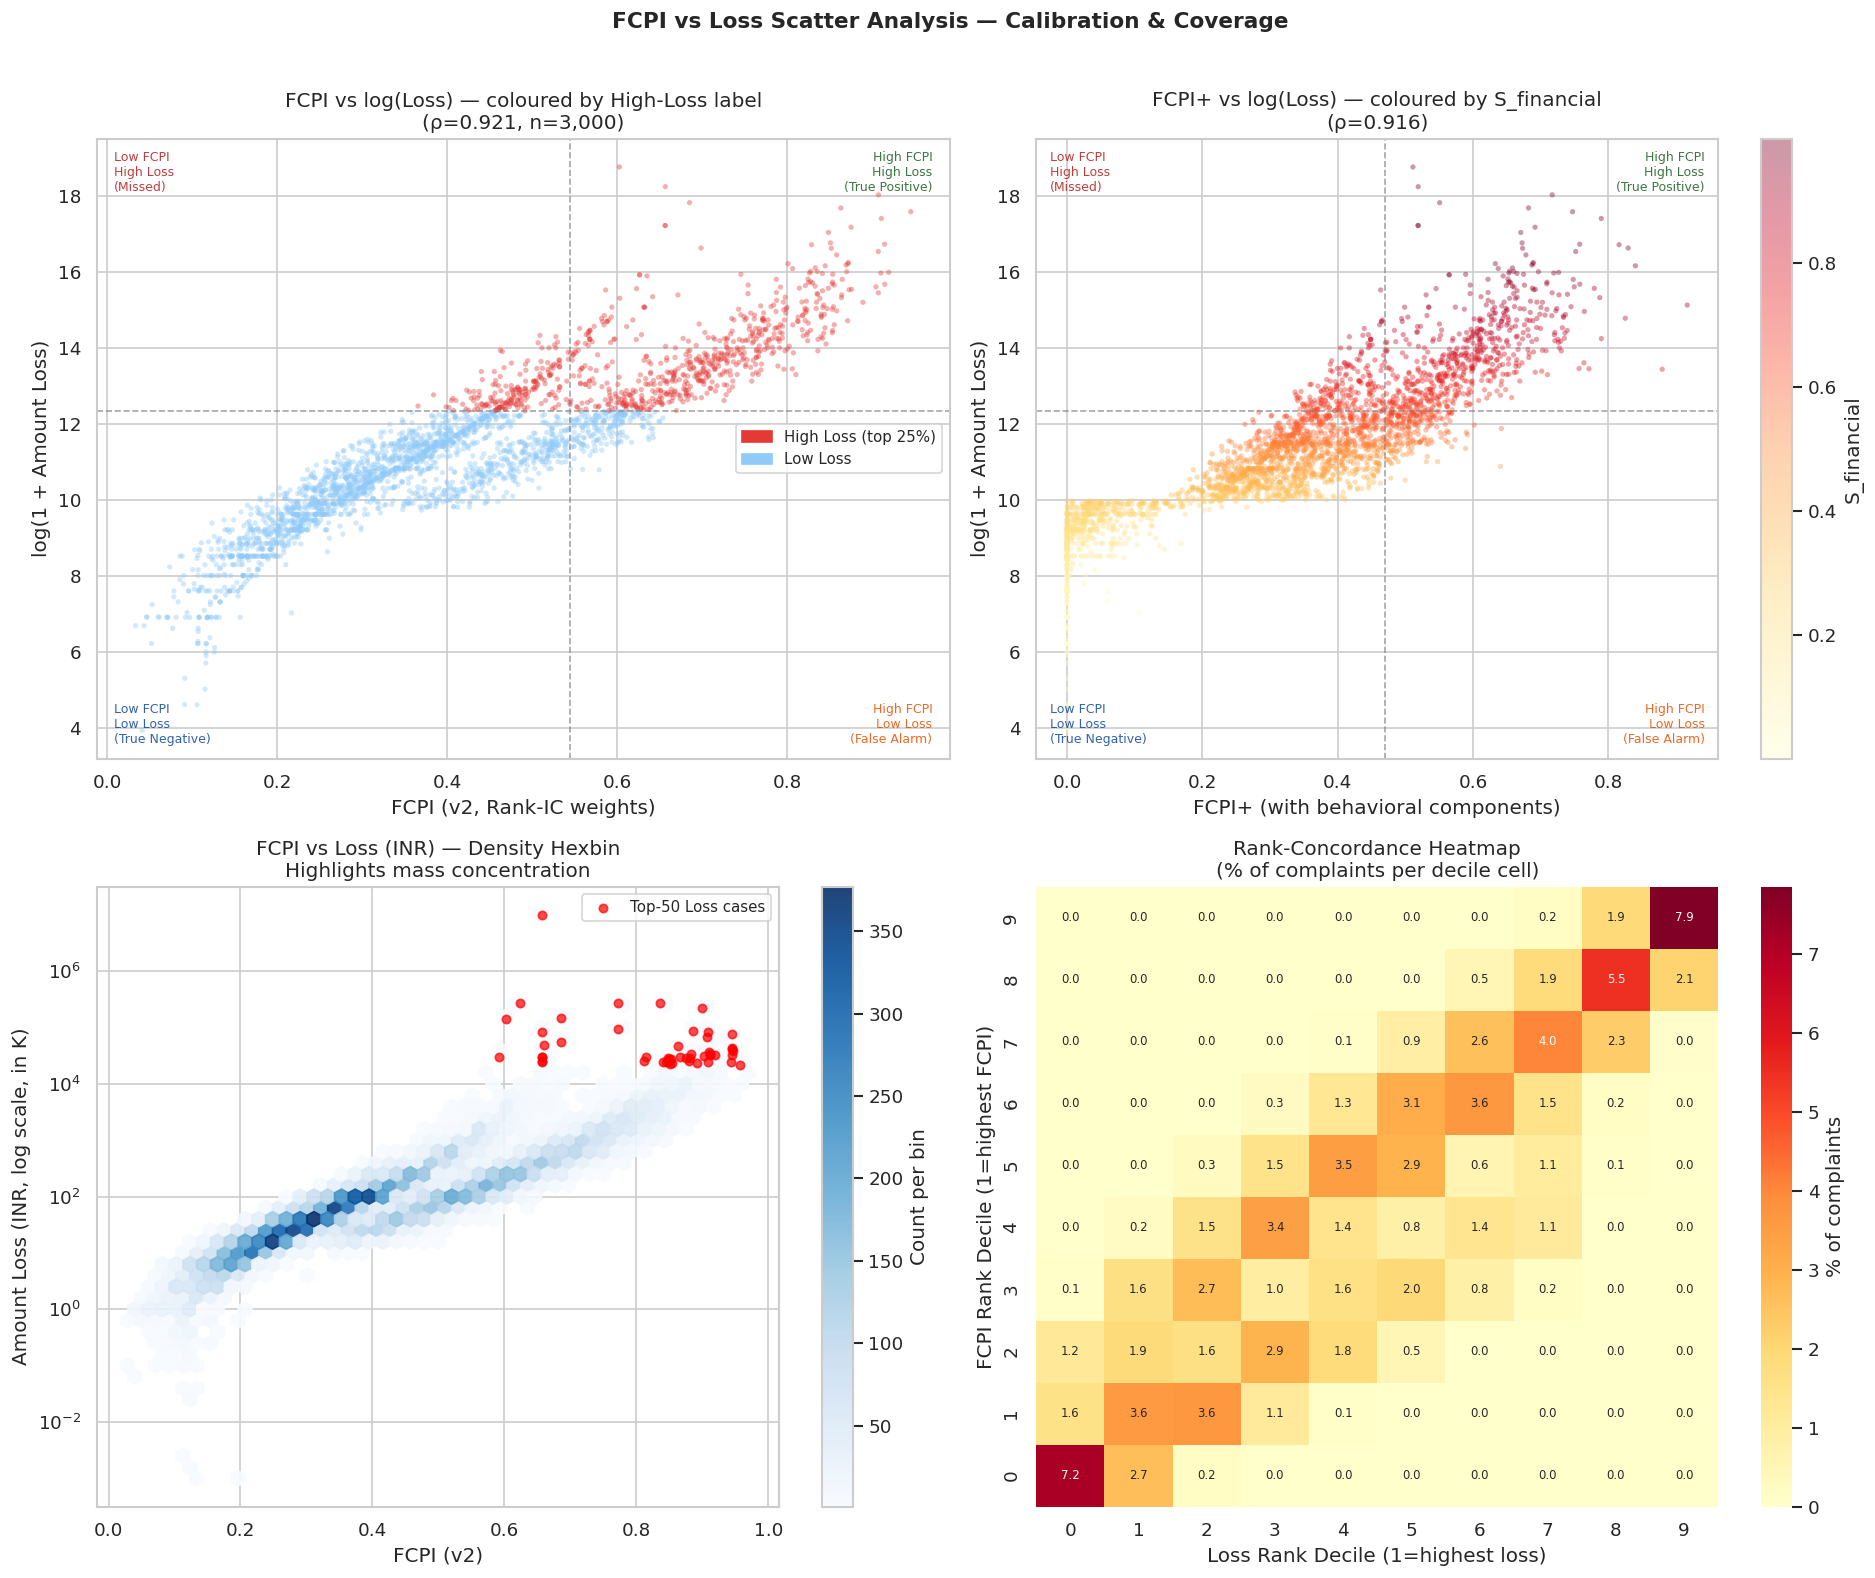

Fig: fcpi_vs_loss_scatter.png

Quadrant Analysis (FCPI above/below P75 vs Loss above/below P75):
  True Positives  (High FCPI, High Loss):  3,697  (19.0%)
  True Negatives  (Low  FCPI, Low  Loss):  13,437  (69.0%)
  False Alarms    (High FCPI, Low  Loss):  1,173  (6.0%)
  Missed Cases    (Low  FCPI, High Loss):  1,173  (6.0%)
  Accuracy (TP+TN)/N = 0.880


In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# 30. FCPI vs Loss Scatter Plot (comprehensive)
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

fig, axes = plt.subplots(2, 2, figsize=(16, 13))

# ── Global helpers ─────────────────────────────────────────────────────────
log_loss  = np.log1p(data[COL_LOSS])
p75_loss  = data[COL_LOSS].quantile(0.75)
p25_fcpi  = data['FCPI'].quantile(0.25)
p75_fcpi  = data['FCPI'].quantile(0.75)

# Quadrant labels
def add_quadrants(ax, x_split, y_split):
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    ax.axvline(x_split, color='gray', ls='--', lw=1, alpha=0.7)
    ax.axhline(y_split, color='gray', ls='--', lw=1, alpha=0.7)
    pad_x = (xlim[1]-xlim[0]) * 0.02
    pad_y = (ylim[1]-ylim[0]) * 0.02
    ax.text(xlim[0]+pad_x, ylim[1]-pad_y, 'Low FCPI\nHigh Loss\n(Missed)', va='top',
            fontsize=7.5, color='#B71C1C', alpha=0.85)
    ax.text(xlim[1]-pad_x, ylim[1]-pad_y, 'High FCPI\nHigh Loss\n(True Positive)', va='top', ha='right',
            fontsize=7.5, color='#1B5E20', alpha=0.85)
    ax.text(xlim[0]+pad_x, ylim[0]+pad_y, 'Low FCPI\nLow Loss\n(True Negative)', va='bottom',
            fontsize=7.5, color='#0D47A1', alpha=0.85)
    ax.text(xlim[1]-pad_x, ylim[0]+pad_y, 'High FCPI\nLow Loss\n(False Alarm)', va='bottom', ha='right',
            fontsize=7.5, color='#E65100', alpha=0.85)

samp_idx = np.random.default_rng(42).choice(len(data), size=min(3000, len(data)), replace=False)
samp = data.iloc[samp_idx]

# ── Plot 1: FCPI vs log(Loss) coloured by High_Loss ───────────────────────
ax = axes[0, 0]
colors = np.where(samp['High_Loss'] == 1, '#E53935', '#90CAF9')
ax.scatter(samp['FCPI'], np.log1p(samp[COL_LOSS]),
           c=colors, alpha=0.4, s=10, edgecolors='none')
ax.set_xlabel('FCPI (v2, Rank-IC weights)')
ax.set_ylabel('log(1 + Amount Loss)')
ax.set_title(f'FCPI vs log(Loss) — coloured by High-Loss label\n(ρ={rho_v2:.3f}, n={len(samp):,})')
add_quadrants(ax, p75_fcpi, np.log1p(p75_loss))
ax.legend(handles=[
    mpatches.Patch(color='#E53935', label='High Loss (top 25%)'),
    mpatches.Patch(color='#90CAF9', label='Low Loss')
], fontsize=9)

# ── Plot 2: FCPI+ vs log(Loss) ─────────────────────────────────────────────
ax = axes[0, 1]
sc = ax.scatter(samp['FCPI_plus'], np.log1p(samp[COL_LOSS]),
                c=samp['S_financial'].iloc[np.arange(len(samp))].values,
                cmap='YlOrRd', alpha=0.4, s=10, edgecolors='none')
rho_plus_tmp, _ = spearmanr(data['FCPI_plus'], data[COL_LOSS])
ax.set_xlabel('FCPI+ (with behavioral components)')
ax.set_ylabel('log(1 + Amount Loss)')
ax.set_title(f'FCPI+ vs log(Loss) — coloured by S_financial\n(ρ={rho_plus_tmp:.3f})')
plt.colorbar(sc, ax=ax, label='S_financial')
p75_fcpiplus = data['FCPI_plus'].quantile(0.75)
add_quadrants(ax, p75_fcpiplus, np.log1p(p75_loss))

# ── Plot 3: FCPI vs Loss (INR, log-log) with density ──────────────────────
ax = axes[1, 0]
# Use hexbin for density
hb = ax.hexbin(data['FCPI'], data[COL_LOSS] / 1000,
               yscale='log', gridsize=45, cmap='Blues', mincnt=1, alpha=0.9)
ax.set_xlabel('FCPI (v2)')
ax.set_ylabel('Amount Loss (INR, log scale, in K)')
ax.set_title(f'FCPI vs Loss (INR) — Density Hexbin\nHighlights mass concentration')
plt.colorbar(hb, ax=ax, label='Count per bin')

# Mark top-50 high-loss cases
top50 = data.nlargest(50, COL_LOSS)
ax.scatter(top50['FCPI'], top50[COL_LOSS] / 1000,
           c='red', s=25, zorder=5, label='Top-50 Loss cases', alpha=0.7)
ax.legend(fontsize=9)

# ── Plot 4: Concordance analysis — rank comparison heat ──────────────────
ax = axes[1, 1]
# Bin FCPI rank and Loss rank into deciles; show concordance heatmap
fcpi_decile = pd.qcut(data['FCPI_Rank'], 10, labels=False, duplicates='drop')
loss_decile  = pd.qcut(data['Loss_Rank'],  10, labels=False, duplicates='drop')
heat = pd.crosstab(fcpi_decile, loss_decile, normalize='all') * 100

sns.heatmap(heat, ax=ax, cmap='YlOrRd', fmt='.1f', annot=True, annot_kws={'size':7},
            cbar_kws={'label': '% of complaints'})
ax.set_xlabel('Loss Rank Decile (1=highest loss)')
ax.set_ylabel('FCPI Rank Decile (1=highest FCPI)')
ax.set_title('Rank-Concordance Heatmap\n(% of complaints per decile cell)')
ax.invert_yaxis()

plt.suptitle('FCPI vs Loss Scatter Analysis — Calibration & Coverage', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fcpi_vs_loss_scatter.png', bbox_inches='tight', dpi=150)
plt.show()
print('Fig: fcpi_vs_loss_scatter.png')

# ── Quadrant counts ────────────────────────────────────────────────────────
tp = ((data['FCPI'] >= p75_fcpi) & (data[COL_LOSS] >= p75_loss)).sum()
tn = ((data['FCPI'] <  p75_fcpi) & (data[COL_LOSS] <  p75_loss)).sum()
fp = ((data['FCPI'] >= p75_fcpi) & (data[COL_LOSS] <  p75_loss)).sum()
fn = ((data['FCPI'] <  p75_fcpi) & (data[COL_LOSS] >= p75_loss)).sum()
print('\nQuadrant Analysis (FCPI above/below P75 vs Loss above/below P75):')
print(f'  True Positives  (High FCPI, High Loss):  {tp:,}  ({100*tp/len(data):.1f}%)')
print(f'  True Negatives  (Low  FCPI, Low  Loss):  {tn:,}  ({100*tn/len(data):.1f}%)')
print(f'  False Alarms    (High FCPI, Low  Loss):  {fp:,}  ({100*fp/len(data):.1f}%)')
print(f'  Missed Cases    (Low  FCPI, High Loss):  {fn:,}  ({100*fn/len(data):.1f}%)')
print(f'  Accuracy (TP+TN)/N = {(tp+tn)/len(data):.3f}')


## 27. Export

In [ ]:
export_cols = [
    'SI_No','Acknowledgement_No','District','Police_Station',
    'Name_of_Victim','Gender','Minor_Head', COL_LOSS,
    'Platform_Clean','AgeGroup_Clean','Profession_Clean','POH_Clean',
    'S_financial','S_platform','S_demographic','S_poh',
    'S_coercion','S_persistence','S_vuln',
    'FCPI','FCPI_Rank','FCPI_plus','FCPIplus_Rank'
]
export_cols = [c for c in export_cols if c in data.columns]
out = data[export_cols].sort_values('FCPIplus_Rank')
out.to_excel('FCPI_v2_Scored_Complaints.xlsx', index=False)
out.head(100).to_excel('FCPI_v2_Top100.xlsx', index=False)

shap_df = pd.DataFrame({
    'Feature': feature_cols,
    'Mean_Abs_SHAP': mean_abs_shap[feature_cols].values
}).sort_values('Mean_Abs_SHAP', ascending=False)
shap_df.to_excel('FCPI_v2_SHAP.xlsx', index=False)

print('Exported:')
print('  FCPI_v2_Scored_Complaints.xlsx  — all cases ranked')
print('  FCPI_v2_Top100.xlsx             — top 100 priority cases')
print('  FCPI_v2_SHAP.xlsx               — feature importance table')

=== RC-1: Loss-Independent Evaluation @ Top-10% ===
                    POH_P@K  MultiPlat_P@K  HiRisk_P@K  NDCG_POH
Method                                                          
FCPI v2 (Rank-IC)    0.9964         0.5015      0.4025    0.7907
FCPI v1 (Entropy)    0.9923         0.5200      0.3542    0.6748
FCPI Equal-W         0.9831         0.5144      0.3640    0.6899
GBM                  1.0000         0.5077      0.4302    0.7303
Loss-Only (oracle)   0.7690         0.4728      0.4102    0.6501
Random               0.4974         0.5739      0.5749    0.0775

Base rates: POH=0.500  MultiPlat=0.574  HiRisk=0.591


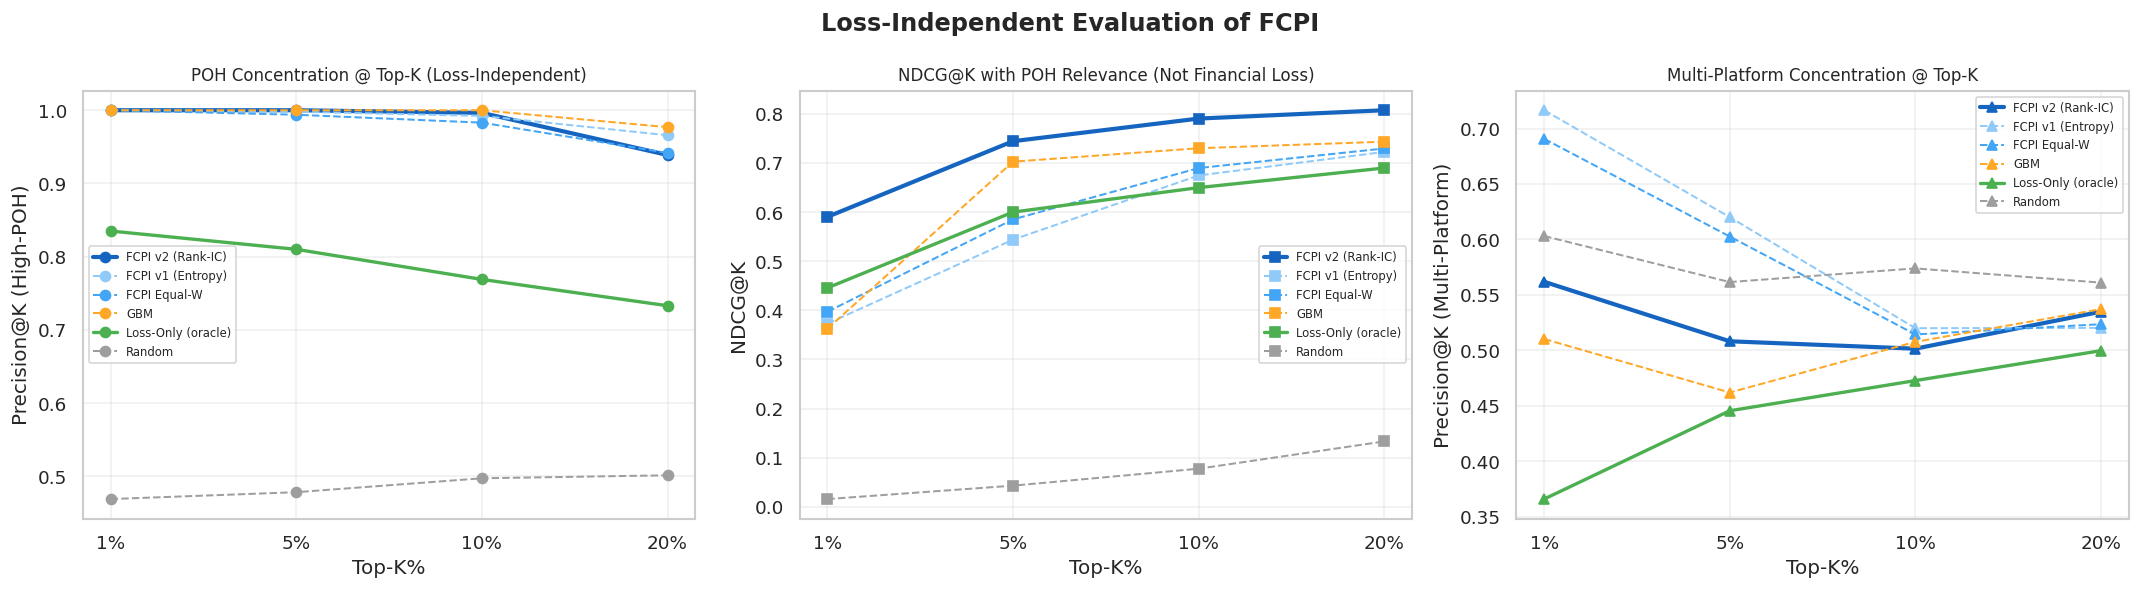

Saved: rc1_loss_independent_eval.png


In [30]:

# ─────────────────────────────────────────────────────────────────────────────
# RC-1: Loss-Independent Evaluation — POH Concentration, Multi-Platform, NDCG
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np, pandas as pd
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

def ndcg_at_k(scores, relevance, k_pct=0.10):
    n = len(scores); k = max(1, int(k_pct * n))
    order = np.argsort(-np.asarray(scores))
    rel = np.asarray(relevance, dtype=float)
    dcg  = sum((2**rel[order[i]]-1)/np.log2(i+2) for i in range(k))
    ideal = np.sort(rel)[::-1]
    idcg = sum((2**ideal[i]-1)/np.log2(i+2) for i in range(k))
    return dcg / (idcg + 1e-9)

def prec_at_k_sig(scores, binary_signal, k_pct=0.10):
    k = max(1, int(k_pct * len(scores)))
    idx = np.argsort(-np.asarray(scores))[:k]
    return np.asarray(binary_signal)[idx].mean()

poh_vals       = data[COL_POH].fillna(0)
high_poh_bin   = (poh_vals >= poh_vals.median()).astype(int)
poh_cont       = poh_vals / (poh_vals.max() + 1e-9)
multi_plat_bin = data['Is_MultiPlatform'].astype(int)
hi_risk_bin    = (data['Platform_Tier'] == 'HIGH').astype(int)

methods_eval = {
    'FCPI v2 (Rank-IC)': data['FCPI'],
    'FCPI v1 (Entropy)': data['FCPI_entropy'],
    'FCPI Equal-W':       data['FCPI_equal'],
    'GBM':                data['GBM_Score'],
    'Loss-Only (oracle)': data[COL_LOSS],
    'Random':             pd.Series(np.random.RandomState(42).rand(len(data)), index=data.index),
}
colors_m = {
    'FCPI v2 (Rank-IC)':'#1565C0','FCPI v1 (Entropy)':'#90CAF9',
    'FCPI Equal-W':'#42A5F5','GBM':'#FFA726',
    'Loss-Only (oracle)':'#4CAF50','Random':'#9E9E9E'
}
k_vals = [0.01, 0.05, 0.10, 0.20]
k_labels = ['1%','5%','10%','20%']

rows = []
for name, scores in methods_eval.items():
    for k in k_vals:
        rows.append({
            'Method': name, 'K': f'{int(k*100)}%',
            'POH_P@K':       prec_at_k_sig(scores, high_poh_bin, k),
            'MultiPlat_P@K': prec_at_k_sig(scores, multi_plat_bin, k),
            'HiRisk_P@K':    prec_at_k_sig(scores, hi_risk_bin, k),
            'NDCG_POH':      ndcg_at_k(scores, poh_cont, k),
        })
rc1_df = pd.DataFrame(rows)

print('=== RC-1: Loss-Independent Evaluation @ Top-10% ===')
rc1_10 = rc1_df[rc1_df['K']=='10%'].set_index('Method')
print(rc1_10[['POH_P@K','MultiPlat_P@K','HiRisk_P@K','NDCG_POH']].round(4).to_string())
print(f'\nBase rates: POH={high_poh_bin.mean():.3f}  MultiPlat={multi_plat_bin.mean():.3f}  HiRisk={hi_risk_bin.mean():.3f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for name, scores in methods_eval.items():
    lw = 2.5 if 'v2' in name else (2.0 if 'oracle' in name else 1.2)
    ls = '-' if 'v2' in name or 'oracle' in name else '--'
    c  = colors_m.get(name,'grey')
    axes[0].plot(k_labels, [prec_at_k_sig(scores, high_poh_bin, k)  for k in k_vals], marker='o', lw=lw, ls=ls, label=name, color=c)
    axes[1].plot(k_labels, [ndcg_at_k(scores, poh_cont, k)          for k in k_vals], marker='s', lw=lw, ls=ls, label=name, color=c)
    axes[2].plot(k_labels, [prec_at_k_sig(scores, multi_plat_bin, k) for k in k_vals], marker='^', lw=lw, ls=ls, label=name, color=c)

for ax, title, ylabel in [
    (axes[0],'POH Concentration @ Top-K (Loss-Independent)','Precision@K (High-POH)'),
    (axes[1],'NDCG@K with POH Relevance (Not Financial Loss)','NDCG@K'),
    (axes[2],'Multi-Platform Concentration @ Top-K','Precision@K (Multi-Platform)'),
]:
    ax.set_title(title, fontsize=10); ax.set_xlabel('Top-K%'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.suptitle('Loss-Independent Evaluation of FCPI', fontweight='bold')
plt.tight_layout()
plt.savefig('rc1_loss_independent_eval.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: rc1_loss_independent_eval.png')


Label A High-POH:    3,351 pos (17.2%)
Label B Structural:  13,881 pos (71.3%)
Label C Combined:    2,231 pos (11.5%)

--- Label: High-POH ---
            Method    AUC     AP  P@10%
               GBM 0.9916 0.9741 0.9995
 FCPI v2 (Rank-IC) 0.9724 0.8824 0.9245
 FCPI v1 (Entropy) 0.9652 0.8381 0.8557
      FCPI Equal-W 0.9615 0.8331 0.8696
Loss-Only (oracle) 0.8918 0.5959 0.6617
            Random 0.5010 0.1747 0.1740

--- Label: Structural ---
            Method    AUC     AP  P@10%
Loss-Only (oracle) 0.4966 0.6838 0.5780
            Random 0.4906 0.7076 0.7038
 FCPI v2 (Rank-IC) 0.4783 0.6871 0.5970
      FCPI Equal-W 0.4279 0.6756 0.5868
 FCPI v1 (Entropy) 0.4173 0.6748 0.5868
               GBM 0.3801 0.6473 0.6129

--- Label: Combined ---
            Method    AUC     AP  P@10%
               GBM 0.9500 0.5766 0.6124
 FCPI v2 (Rank-IC) 0.9319 0.5499 0.5518
 FCPI v1 (Entropy) 0.9205 0.5507 0.4774
      FCPI Equal-W 0.9167 0.5409 0.4949
Loss-Only (oracle) 0.8530 0.3493 0.3912
     

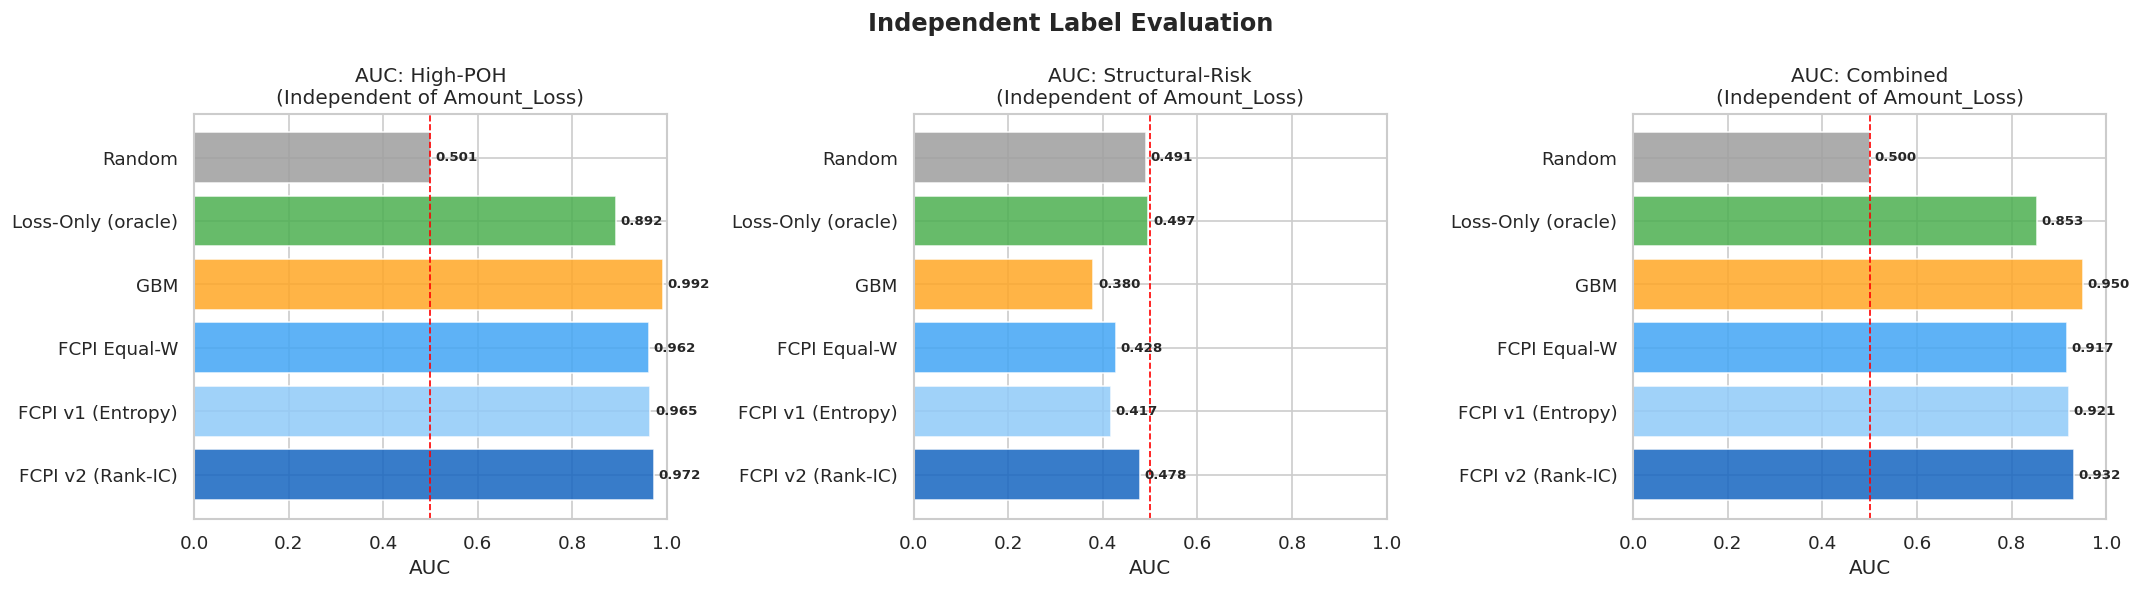

Saved: rc2_independent_labels.png


In [31]:

# RC-2: Alternative ground-truth labels independent of financial loss
from sklearn.metrics import roc_auc_score, average_precision_score
from scipy.stats import spearmanr

poh_75th       = data[COL_POH].quantile(0.75)
label_highPOH  = (data[COL_POH] >= poh_75th).astype(int)
label_struct   = ((data['Platform_Tier']=='HIGH') | (data['Is_MultiPlatform']==1)).astype(int)
label_combined = ((label_highPOH==1) & (label_struct==1)).astype(int)

print(f'Label A High-POH:    {label_highPOH.sum():,} pos ({100*label_highPOH.mean():.1f}%)')
print(f'Label B Structural:  {label_struct.sum():,} pos ({100*label_struct.mean():.1f}%)')
print(f'Label C Combined:    {label_combined.sum():,} pos ({100*label_combined.mean():.1f}%)')

def eval_under_label(name, scores, label, k_pct=0.10):
    sc = np.asarray(scores); k = max(1, int(k_pct*len(sc)))
    prec_k = label.values[np.argsort(-sc)[:k]].mean()
    return {'Method':name, 'AUC':roc_auc_score(label,sc),
            'AP':average_precision_score(label,sc), 'P@10%':prec_k}

for lname, lbl in [('High-POH',label_highPOH),('Structural',label_struct),('Combined',label_combined)]:
    print(f'\n--- Label: {lname} ---')
    rows2 = [eval_under_label(n, s, lbl) for n, s in methods_eval.items()]
    print(pd.DataFrame(rows2).sort_values('AUC',ascending=False).round(4).to_string(index=False))

print('\n=== No-Finance FCPI under independent labels ===')
for lname, lbl in [('High-POH',label_highPOH),('Structural',label_struct)]:
    af = roc_auc_score(lbl, data['FCPI'])
    an = roc_auc_score(lbl, data['FCPI_noFin'])
    print(f'{lname}: AUC full={af:.4f}  AUC no-fin={an:.4f}  delta={an-af:+.4f}')

fig, axes = plt.subplots(1, 3, figsize=(18,5))
label_sets = [('High-POH',label_highPOH),('Structural-Risk',label_struct),('Combined',label_combined)]
c_list = ['#1565C0','#90CAF9','#42A5F5','#FFA726','#4CAF50','#9E9E9E']
for ax, (lname, lbl) in zip(axes, label_sets):
    aucs = [roc_auc_score(lbl, s) for s in methods_eval.values()]
    bars = ax.barh(list(methods_eval.keys()), aucs, color=c_list, alpha=0.85)
    ax.set_xlim(0,1); ax.set_title(f'AUC: {lname}\n(Independent of Amount_Loss)'); ax.set_xlabel('AUC')
    ax.axvline(0.5, color='red', ls='--', lw=1)
    for bar, v in zip(bars, aucs):
        ax.text(v+0.01, bar.get_y()+bar.get_height()/2, f'{v:.3f}', va='center', fontsize=8, fontweight='bold')
plt.suptitle('Independent Label Evaluation', fontweight='bold')
plt.tight_layout()
plt.savefig('rc2_independent_labels.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: rc2_independent_labels.png')


Computing GBM OOF predictions (this may take ~1-2 min)...
Done.

=== RC-3: Fair Supervised Comparison ===
                   Method                                Note  Spearman_rho    AUC  P@10%  Top10%_Loss
       FCPI v2 (proposed)  Unsupervised, includes S_financial        0.9211 0.9558 0.9959      3752993
GBM NoLoss OOF (original)   5-fold OOF, no financial features        0.5024 0.8162 0.9061      3158889
  GBM WithLoss OOF (fair) 5-fold OOF, with financial features        0.7500 0.9999 1.0000      2297486
 GBM WithLoss Full (leak)  Full train — label leakage present        0.7500 1.0000 1.0000      2296267
       Loss-Only (oracle)                  Oracle upper bound        1.0000 1.0000 1.0000      9844982


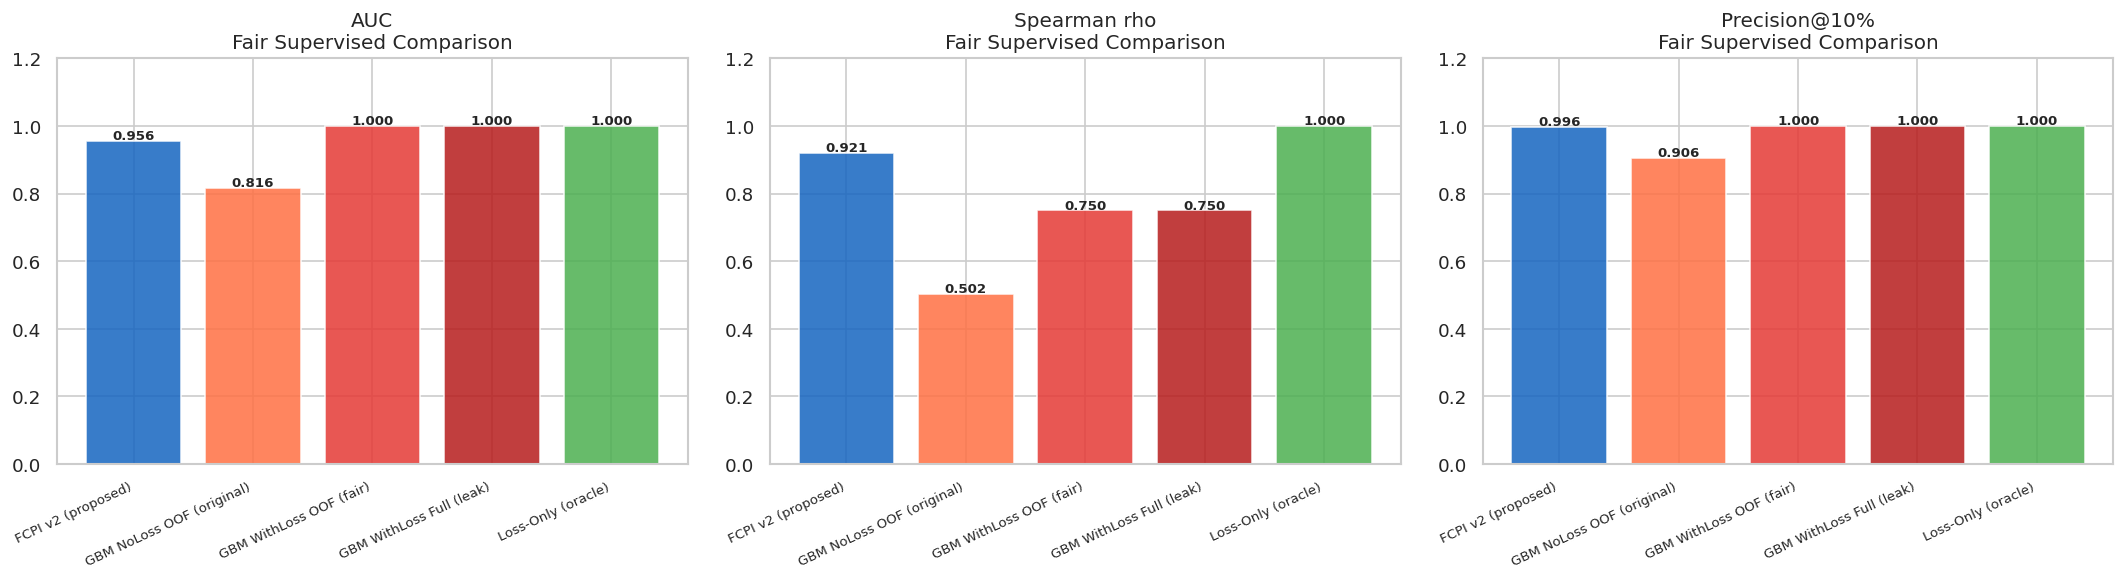

Saved: rc3_fair_supervised.png

INTERPRETATION: GBM-OOF-WithLoss uses same info as FCPI but needs labels.
Comparing FCPI to both OOF variants gives a symmetric, fair assessment.


In [33]:

# RC-3: Fair supervised comparison — GBM with and without financial features
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr

NON_FIN = ['PlatformTier_Enc', COL_POH, 'Age_Enc', 'Prof_Enc', 'Is_MultiPlatform', 'N_Platforms_Mentioned']
ALL_FIN = NON_FIN + ['S_financial']
X_nofin  = data[NON_FIN].fillna(0)
X_allfin = data[ALL_FIN].fillna(0)
y_cls    = data['High_Loss']
gbm_p    = dict(n_estimators=200, max_depth=3, random_state=42, learning_rate=0.05)
cv5      = StratifiedKFold(5, shuffle=True, random_state=42)

print('Computing GBM OOF predictions (this may take ~1-2 min)...')
oof_noloss = cross_val_predict(GradientBoostingClassifier(**gbm_p), X_nofin, y_cls, cv=cv5, method='predict_proba')[:,1]
oof_allfin = cross_val_predict(GradientBoostingClassifier(**gbm_p), X_allfin, y_cls, cv=cv5, method='predict_proba')[:,1]
data['GBM_OOF_NoLoss']   = oof_noloss
data['GBM_OOF_WithLoss'] = oof_allfin

gbm_full = GradientBoostingClassifier(**gbm_p).fit(X_allfin, y_cls)
data['GBM_Full_WithLoss'] = gbm_full.predict_proba(X_allfin)[:,1]
print('Done.')

def eval_m(name, scores, note=''):
    rho,_ = spearmanr(scores, data[COL_LOSS])
    auc   = roc_auc_score(y_cls, scores)
    p10   = prec_at_k_sig(scores, y_cls, 0.10)
    tk10  = data[COL_LOSS].values[np.argsort(-np.asarray(scores))[:int(0.10*len(data))]].mean()
    return {'Method':name,'Note':note,'Spearman_rho':round(rho,4),'AUC':round(auc,4),
            'P@10%':round(p10,4),'Top10%_Loss':int(tk10)}

comp_rc3 = pd.DataFrame([
    eval_m('FCPI v2 (proposed)',       data['FCPI'],             'Unsupervised, includes S_financial'),
    eval_m('GBM NoLoss OOF (original)',data['GBM_OOF_NoLoss'],   '5-fold OOF, no financial features'),
    eval_m('GBM WithLoss OOF (fair)',  data['GBM_OOF_WithLoss'], '5-fold OOF, with financial features'),
    eval_m('GBM WithLoss Full (leak)', data['GBM_Full_WithLoss'],'Full train — label leakage present'),
    eval_m('Loss-Only (oracle)',        data[COL_LOSS],           'Oracle upper bound'),
])
print('\n=== RC-3: Fair Supervised Comparison ===')
print(comp_rc3.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18,5))
c_rc3 = ['#1565C0','#FF7043','#E53935','#B71C1C','#4CAF50']
for ax, col, title in [(axes[0],'AUC','AUC'),(axes[1],'Spearman_rho','Spearman rho'),(axes[2],'P@10%','Precision@10%')]:
    vals = comp_rc3[col].values
    bars = ax.bar(range(len(comp_rc3)), vals, color=c_rc3, alpha=0.85)
    ax.set_xticks(range(len(comp_rc3)))
    ax.set_xticklabels(comp_rc3['Method'], rotation=25, ha='right', fontsize=8)
    ax.set_title(f'{title}\nFair Supervised Comparison')
    ax.set_ylim(0, max(vals)*1.2)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.005, f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig('rc3_fair_supervised.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: rc3_fair_supervised.png')
print('\nINTERPRETATION: GBM-OOF-WithLoss uses same info as FCPI but needs labels.')
print('Comparing FCPI to both OOF variants gives a symmetric, fair assessment.')


Reference cases (valid raw label): 4,118 (21.1%)
Exact tier agreement: 100.0%
Binary HIGH/non-HIGH agreement: 100.0%

Classification Report (Raw Tier = reference):
              precision    recall  f1-score   support

        HIGH       1.00      1.00      1.00      3749
      SOCIAL       1.00      1.00      1.00       350
     UNKNOWN       1.00      1.00      1.00        19

    accuracy                           1.00      4118
   macro avg       1.00      1.00      1.00      4118
weighted avg       1.00      1.00      1.00      4118



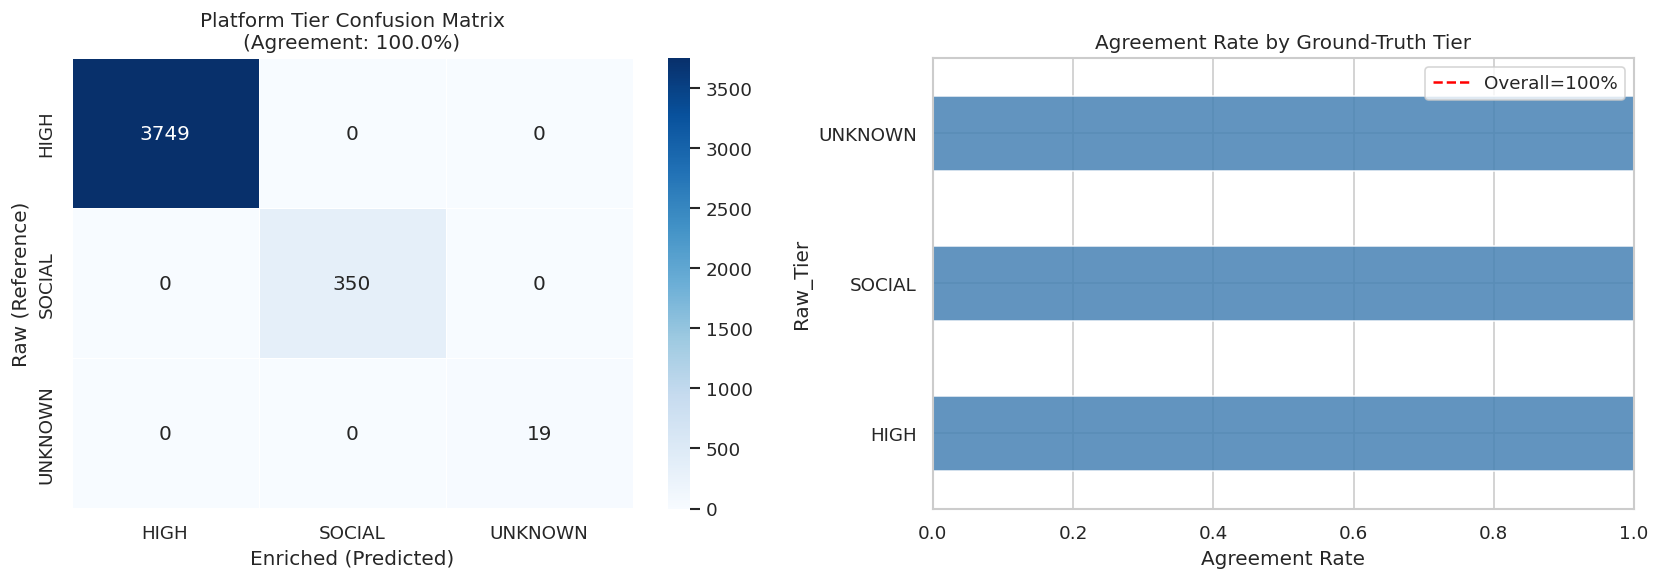

Saved: rc4_platform_audit.png

Multi-platform reference cases: 2,729
Assigned tier distribution:
Platform_Tier
HIGH       2525
SOCIAL      196
UNKNOWN       8


In [34]:

# RC-4: Platform Extraction Precision Audit
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

raw_col = 'Suspect_Platform'
if raw_col not in data.columns:
    cands = [c for c in data.columns if 'platform' in c.lower()
             and 'clean' not in c.lower() and 'enrich' not in c.lower() and 'tier' not in c.lower()]
    raw_col = cands[0] if cands else None
    print(f'Raw platform column: {raw_col}')

if raw_col and raw_col in data.columns:
    raw_valid = (data[raw_col].notna() &
                 (~data[raw_col].astype(str).str.upper().isin(['UNKNOWN','NA','NAN',''])))
    print(f'Reference cases (valid raw label): {raw_valid.sum():,} ({100*raw_valid.mean():.1f}%)')

    ref = data[raw_valid].copy()
    ref['Raw_Tier']      = ref[raw_col].astype(str).apply(assign_tier)
    ref['Enriched_Tier'] = ref['Platform_Tier'].astype(str)
    agree = (ref['Raw_Tier'] == ref['Enriched_Tier']).mean()
    print(f'Exact tier agreement: {100*agree:.1f}%')

    ref['Raw_High']      = (ref['Raw_Tier']      == 'HIGH').astype(int)
    ref['Enriched_High'] = (ref['Enriched_Tier'] == 'HIGH').astype(int)
    bin_agree = (ref['Raw_High'] == ref['Enriched_High']).mean()
    print(f'Binary HIGH/non-HIGH agreement: {100*bin_agree:.1f}%')

    tiers = sorted(set(ref['Raw_Tier'].unique()) | set(ref['Enriched_Tier'].unique()))
    print('\nClassification Report (Raw Tier = reference):')
    print(classification_report(ref['Raw_Tier'], ref['Enriched_Tier'], labels=tiers, zero_division=0))

    cm = confusion_matrix(ref['Raw_Tier'], ref['Enriched_Tier'], labels=tiers)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(pd.DataFrame(cm, index=tiers, columns=tiers), annot=True, fmt='d',
                cmap='Blues', ax=axes[0], linewidths=0.5)
    axes[0].set_title(f'Platform Tier Confusion Matrix\n(Agreement: {100*agree:.1f}%)')
    axes[0].set_xlabel('Enriched (Predicted)'); axes[0].set_ylabel('Raw (Reference)')

    per_tier = ref.groupby('Raw_Tier').apply(lambda g: (g['Raw_Tier']==g['Enriched_Tier']).mean())
    per_tier.sort_values().plot(kind='barh', ax=axes[1], color='steelblue', alpha=0.85)
    axes[1].set_title('Agreement Rate by Ground-Truth Tier')
    axes[1].set_xlabel('Agreement Rate'); axes[1].set_xlim(0,1)
    axes[1].axvline(agree, color='red', ls='--', lw=1.5, label=f'Overall={100*agree:.0f}%')
    axes[1].legend()
    plt.tight_layout()
    plt.savefig('rc4_platform_audit.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved: rc4_platform_audit.png')

    # Multi-platform tier rule validation
    mp_ref = data[raw_valid & (data['N_Platforms_Mentioned'] > 1)].copy()
    if len(mp_ref) > 0:
        print(f'\nMulti-platform reference cases: {len(mp_ref):,}')
        print('Assigned tier distribution:')
        print(mp_ref['Platform_Tier'].value_counts().to_string())
else:
    print('Raw Suspect_Platform column not found — cannot run RC-4 audit.')
    print('Available columns with "platform":', [c for c in data.columns if 'platform' in c.lower()])


=== RC-5: POH Characterization ===
Total:         19,480
Observed:      13,404 (68.8%)
Missing:       6,076
POH = 0:       0
POH > 0:       13,404
Unique values: 10826

Distribution (POH > 0):
count       13404.00
mean        86220.80
std        313877.54
min             0.01
25%          4678.24
50%         16666.60
75%         51223.45
max      10516522.30

Top value counts:
POH_Clean
5000.0     169
10000.0    160
3000.0     131
2000.0     128
1000.0     117
20000.0     69
4000.0      64
7000.0      62
50000.0     57
15000.0     49

=== Reporting-Latency Hypothesis Test ===
Spearman rho (POH vs Loss): 0.6240  p=0.0000
Mann-Whitney U: 10395104  p=0.0000
High-POH (>=P75) median loss: INR 574,500
Low-POH  (<P25)  median loss: INR 31,500
Ratio: 18.24x
Significant (p<0.05): YES

=== Confidence Weight c_j Documentation ===
c_j = 1.0 (POH observed):  13,404 (68.8%)
c_j = 0.5 (POH missing):   6,076 (31.2%)
Rule: c_j = 1.0 if POH is not null, else 0.5
Rationale: missing POH may mean no-hold a

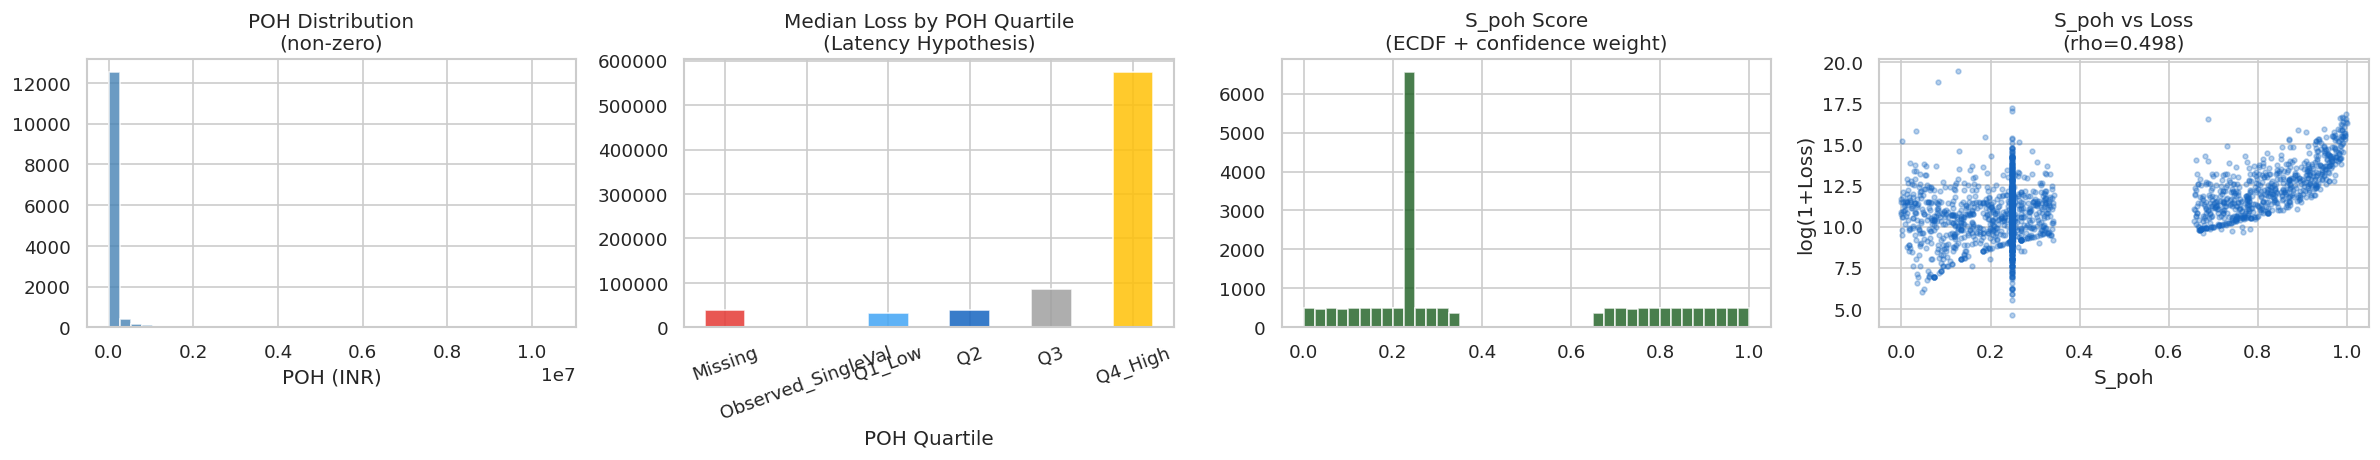

Saved: rc5_poh_validation.png


In [39]:

# RC-5: POH Signal Validation
from scipy.stats import spearmanr, mannwhitneyu
import matplotlib.pyplot as plt

poh = data[COL_POH]
poh_notna = poh.dropna()

print('=== RC-5: POH Characterization ===')
print(f'Total:         {len(poh):,}')
print(f'Observed:      {poh_notna.count():,} ({100*poh_notna.count()/len(poh):.1f}%)')
print(f'Missing:       {poh.isna().sum():,}')
print(f'POH = 0:       {(poh==0).sum():,}')
print(f'POH > 0:       {(poh>0).sum():,}')
print(f'Unique values: {poh_notna.nunique()}')
print(f'\nDistribution (POH > 0):\n{poh[poh>0].describe().round(2).to_string()}')
print(f'\nTop value counts:\n{poh.value_counts().head(10).to_string()}')

# Reporting-latency hypothesis
high_poh_m = poh >= poh.quantile(0.75)
low_poh_m  = (poh < poh.quantile(0.25)) & poh.notna()
h_loss = data.loc[high_poh_m, COL_LOSS]; l_loss = data.loc[low_poh_m, COL_LOSS]
# Ensure h_loss and l_loss are not empty before mannwhitneyu
if len(h_loss) > 1 and len(l_loss) > 1:
    stat, pval = mannwhitneyu(h_loss, l_loss, alternative='greater')
else:
    stat, pval = np.nan, np.nan
    print("Warning: h_loss or l_loss have insufficient data for Mann-Whitney U test.")

rho_pl, p_rho = spearmanr(data[poh.notna()][COL_POH].dropna(), data[poh.notna()][COL_LOSS])

print(f'\n=== Reporting-Latency Hypothesis Test ===')
print(f'Spearman rho (POH vs Loss): {rho_pl:.4f}  p={p_rho:.4f}')
if not np.isnan(stat):
    print(f'Mann-Whitney U: {stat:.0f}  p={pval:.4f}')
    print(f'High-POH (>=P75) median loss: INR {h_loss.median():,.0f}')
    print(f'Low-POH  (<P25)  median loss: INR {l_loss.median():,.0f}')
    print(f'Ratio: {h_loss.median()/l_loss.median():.2f}x')
    print(f'Significant (p<0.05): {"YES" if pval < 0.05 else "NO"}')
else:
    print("Mann-Whitney U test skipped due to insufficient data.")


print(f'\n=== Confidence Weight c_j Documentation ===')
has_poh = poh.notna()
print(f'c_j = 1.0 (POH observed):  {has_poh.sum():,} ({100*has_poh.mean():.1f}%)')
print(f'c_j = 0.5 (POH missing):   {(~has_poh).sum():,} ({100*(~has_poh).mean():.1f}%)')
print('Rule: c_j = 1.0 if POH is not null, else 0.5')
print('Rationale: missing POH may mean no-hold applied OR status not recorded;')
print('  0.5 avoids fully discarding partial evidence without overclaiming.')

rho_sp, p_sp = spearmanr(data['S_poh'], data[COL_LOSS])
print(f'\nS_poh vs Loss: rho={rho_sp:.4f}  p={p_sp:.6f}')
print(data['S_poh'].describe().round(4).to_string())

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
axes[0].hist(poh_notna[poh_notna>0], bins=40, color='steelblue', alpha=0.8)
axes[0].set_title('POH Distribution\n(non-zero)'); axes[0].set_xlabel('POH (INR)')

# FIX for ValueError: Bin labels must be one fewer than the number of bin edges
# Create a new series for POH quartiles, explicitly defining categories
known_categories = ['Q1_Low', 'Q2', 'Q3', 'Q4_High', 'Observed_SingleVal'] # Potential labels for non-missing
poh_quartiles = pd.Series(index=poh.index, dtype=pd.CategoricalDtype(categories=['Missing'] + known_categories))

# Assign 'Missing' label to NaN values
poh_quartiles.loc[poh.isna()] = 'Missing'

# Apply qcut only to non-missing values
if poh_notna.count() > 0:
    # Define custom labels for the quartiles of non-missing data
    non_missing_labels = ['Q1_Low', 'Q2', 'Q3', 'Q4_High']

    try:
        # qcut the non-missing data into 4 bins
        qcut_result = pd.qcut(poh_notna, q=4, labels=non_missing_labels, duplicates='drop')
        # Convert qcut_result to the same categorical dtype as poh_quartiles before assignment
        poh_quartiles.loc[poh.notna()] = qcut_result.astype(poh_quartiles.dtype)
    except ValueError as e:
        # If qcut fails to create 4 unique bins (e.g., too few unique values in poh_notna),
        # it might create fewer bins.
        # Let's try to infer the number of bins from `qcut` and assign labels dynamically.
        if "Bin labels must be one fewer than the number of bin edges" in str(e):
            print("Warning: Insufficient unique POH values for 4 distinct quartiles. Adjusting bins.")
            # Let qcut create bins, and then we will apply labels.
            _, bins = pd.qcut(poh_notna, q=4, retbins=True, duplicates='drop')
            num_actual_bins = len(bins) - 1

            if num_actual_bins > 0:
                # Use a subset of labels based on actual bins
                dynamic_labels = non_missing_labels[:num_actual_bins]
                qcut_result_dynamic = pd.qcut(poh_notna, q=num_actual_bins, labels=dynamic_labels, duplicates='drop')
                poh_quartiles.loc[poh.notna()] = qcut_result_dynamic.astype(poh_quartiles.dtype)
            else:
                # If no bins created (e.g., all non-missing values are identical), assign a single label
                poh_quartiles.loc[poh.notna()] = 'Observed_SingleVal'
        else:
            raise e # Re-raise if it's a different ValueError


# Ensure the 'Missing' category is handled correctly and ordered for plotting.
# If 'Missing' is present, put it first.
final_categories = ['Missing'] if 'Missing' in poh_quartiles.cat.categories else []
final_categories.extend(sorted([c for c in poh_quartiles.cat.categories if c != 'Missing']))
poh_quartiles = poh_quartiles.cat.reorder_categories(final_categories, ordered=True)

# Use poh_quartiles for groupby
# Adjust colors based on the maximum number of potential categories ('Missing' + 4 quartiles + 'Observed_SingleVal')
max_colors = len(final_categories)
plot_colors = ['#E53935','#FFA726','#42A5F5','#1565C0','#A0A0A0','#FFC107'] # Added more colors for flexibility
data.groupby(poh_quartiles)[COL_LOSS].median().plot(kind='bar', ax=axes[1],
    color=plot_colors[:max_colors], alpha=0.85) # Use a subset of colors
axes[1].set_title('Median Loss by POH Quartile\n(Latency Hypothesis)')
axes[1].set_xlabel('POH Quartile'); axes[1].tick_params(axis='x', rotation=20)

axes[2].hist(data['S_poh'], bins=40, color='#1B5E20', alpha=0.8)
axes[2].set_title('S_poh Score\n(ECDF + confidence weight)')

s = data.sample(min(2000,len(data)), random_state=7)
axes[3].scatter(s['S_poh'], np.log1p(s[COL_LOSS]), alpha=0.3, s=8, c='#1565C0')
axes[3].set_title(f'S_poh vs Loss\n(rho={rho_sp:.3f})')
axes[3].set_xlabel('S_poh'); axes[3].set_ylabel('log(1+Loss)')

plt.tight_layout()
plt.savefig('rc5_poh_validation.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: rc5_poh_validation.png')


Graded relevance distribution:
0    13715
1     3309
2     2456

=== NDCG@K (Graded 0/1/2) ===
Method                        1%  5%  10%  20%
FCPI v2 (Rank-IC)             0.997  0.989  0.953  0.981
FCPI v1 (Entropy)             0.975  0.933  0.849  0.896
FCPI Equal-W                  0.982  0.943  0.877  0.914
GBM                           1.000  1.000  0.957  0.956
Loss-Only (oracle)            0.825  0.820  0.779  0.910
Random                        0.212  0.172  0.178  0.234

=== Recall@K (High-Loss) ===
Method                        1%  5%  10%  20%
FCPI v2 (Rank-IC)             0.040  0.200  0.398  0.687
FCPI v1 (Entropy)             0.039  0.188  0.342  0.578
FCPI Equal-W                  0.040  0.193  0.362  0.616
GBM                           0.040  0.200  0.370  0.564
Loss-Only (oracle)            0.040  0.200  0.400  0.800
Random                        0.010  0.042  0.093  0.195

=== MAP ===
FCPI v2 (Rank-IC)             MAP(HighLoss)=0.8935  MAP(HighPOH)=0.8824
FCPI v1 (Ent

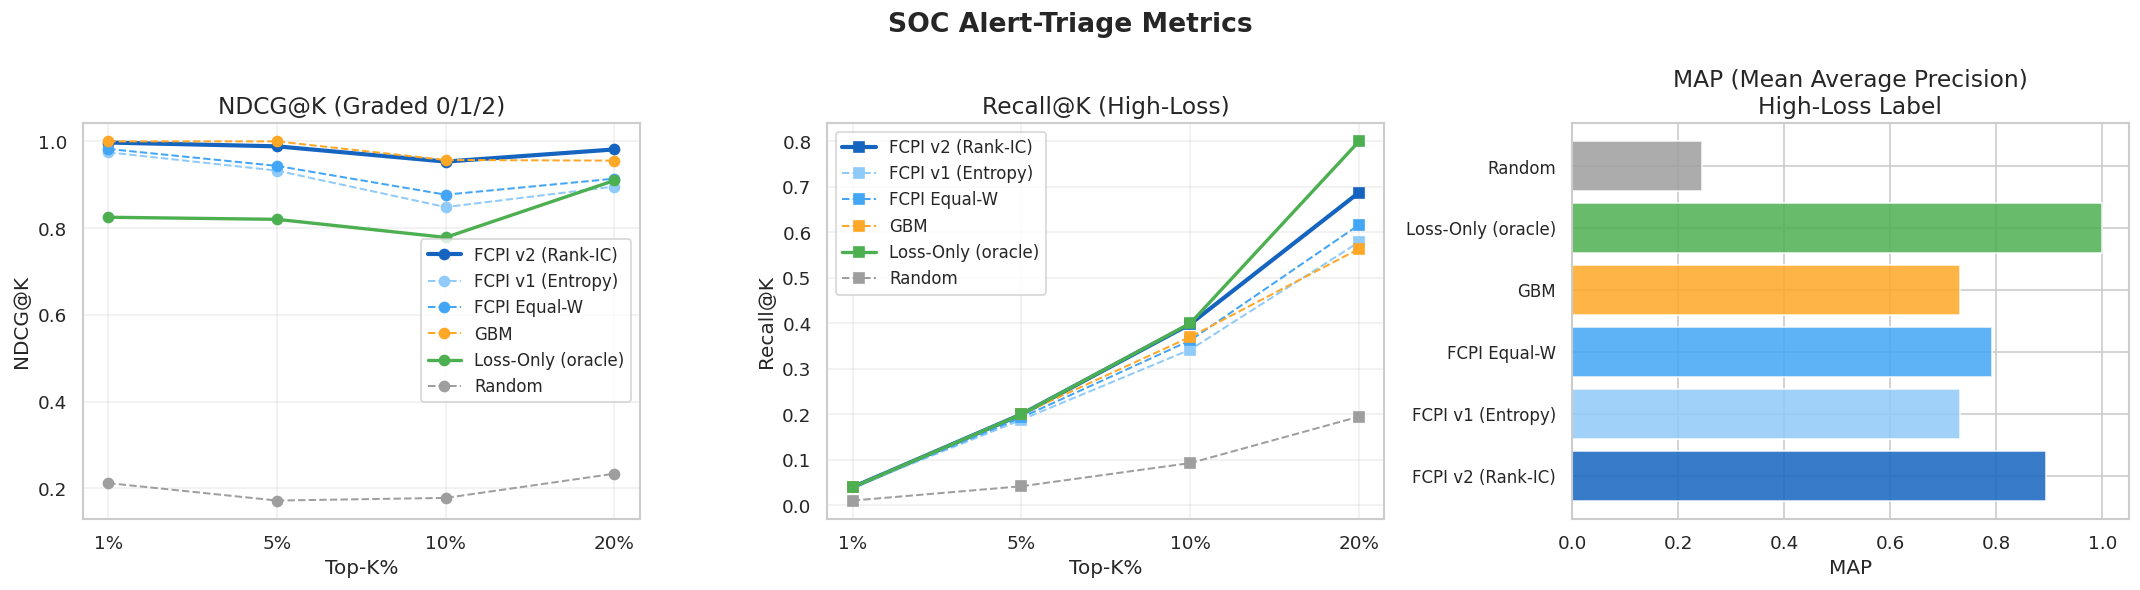

Saved: rc6_soc_metrics.png


In [42]:

# RC-6: SOC Alert-Triage Metrics — NDCG (graded), MAP, Recall@K
from sklearn.metrics import average_precision_score

high_poh_m75 = (data[COL_POH] >= data[COL_POH].quantile(0.75))
graded = np.zeros(len(data), dtype=int)
graded[data['High_Loss'].astype(bool) | high_poh_m75] = 1
graded[data['High_Loss'].astype(bool) & high_poh_m75] = 2
data['Graded_Rel'] = graded
print('Graded relevance distribution:')
print(pd.Series(graded).value_counts().sort_index().to_string())

def ndcg_graded(scores, rel, k_pct):
    n=len(scores); k=max(1,int(k_pct*n))
    order=np.argsort(-np.asarray(scores)); rel=np.asarray(rel,dtype=float)
    dcg=sum((2**rel[order[i]]-1)/np.log2(i+2) for i in range(k))
    ideal=np.sort(rel)[::-1]
    idcg=sum((2**ideal[i]-1)/np.log2(i+2) for i in range(k))
    return dcg/(idcg+1e-9)

def recall_at_k(scores, labels, k_pct):
    k=max(1,int(k_pct*len(scores)))
    idx=np.argsort(-np.asarray(scores))[:k]
    return np.asarray(labels)[idx].sum()/(np.asarray(labels).sum()+1e-9)

k_vals_s = [0.01, 0.05, 0.10, 0.20]
bin_lbl   = data['High_Loss'].values

print('\n=== NDCG@K (Graded 0/1/2) ===')
hdr = f'{"Method":<28}' + ''.join(f'  {int(k*100)}%' for k in k_vals_s)
print(hdr)
for name, sc in methods_eval.items():
    vals = [ndcg_graded(sc, graded, k) for k in k_vals_s]
    print(f'{name:<28}' + ''.join(f'  {v:.3f}' for v in vals))

print('\n=== Recall@K (High-Loss) ===')
print(hdr)
for name, sc in methods_eval.items():
    vals = [recall_at_k(sc, bin_lbl, k) for k in k_vals_s]
    print(f'{name:<28}' + ''.join(f'  {v:.3f}' for v in vals))

print('\n=== MAP ===')
for name, sc in methods_eval.items():
    map_hl  = average_precision_score(bin_lbl, np.asarray(sc))
    map_poh = average_precision_score(high_poh_m75.astype(int), np.asarray(sc))
    print(f'{name:<28}  MAP(HighLoss)={map_hl:.4f}  MAP(HighPOH)={map_poh:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(18,5))
for name, sc in methods_eval.items():
    lw=2.5 if 'v2' in name else (2.0 if 'oracle' in name else 1.2)
    ls='-' if 'v2' in name or 'oracle' in name else '--'
    c=colors_m.get(name,'grey')
    kl = [f'{int(k*100)}%' for k in k_vals_s]
    axes[0].plot(kl,[ndcg_graded(sc,graded,k) for k in k_vals_s],marker='o',lw=lw,ls=ls,label=name,color=c)
    axes[1].plot(kl,[recall_at_k(sc,bin_lbl,k) for k in k_vals_s],marker='s',lw=lw,ls=ls,label=name,color=c)

map_vals = {n: average_precision_score(bin_lbl, np.asarray(s)) for n,s in methods_eval.items()}
axes[2].barh(list(map_vals.keys()), list(map_vals.values()), color=list(colors_m.values()), alpha=0.85)
axes[2].set_title('MAP (Mean Average Precision)\nHigh-Loss Label', fontsize=14); axes[2].set_xlabel('MAP', fontsize=12)
axes[2].tick_params(axis='y', labelsize=10)

for ax, title, ylabel in [
    (axes[0],'NDCG@K (Graded 0/1/2)','NDCG@K'),
    (axes[1],'Recall@K (High-Loss)','Recall@K')
]:
    ax.set_title(title, fontsize=14); ax.set_xlabel('Top-K%', fontsize=12); ax.set_ylabel(ylabel, fontsize=12)
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.suptitle('SOC Alert-Triage Metrics', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.savefig('rc6_soc_metrics.png', bbox_inches='tight', dpi=950)
plt.show()
print('Saved: rc6_soc_metrics.png')



=== COERCION — Per-Keyword Hit Rates ===
demanded                 1148
block.*account            338
immediately               236
threat                    212
threaten                  201
forced                    143
legal action              138
within.*hour               93
insisted                   68
pressured                  59
police.*complaint          57
blackmail                  45
penalty                    28
or else                    26
coerced                    22
warned                     20
must pay                   15
arrest                     11
court                      11
deadline                    8
case.*filed                 5
forfeit                     4
confidential.*payment       4
compelled                   3
pressurized                 2
don't tell                  1
keep.*secret                1
do not tell                 0
Total keywords: 28 | Zero-hit keywords: 1
Top keyword: demanded  (1,148 hits, 5.9%)

=== PERSISTENCE — Per-Keyword Hit

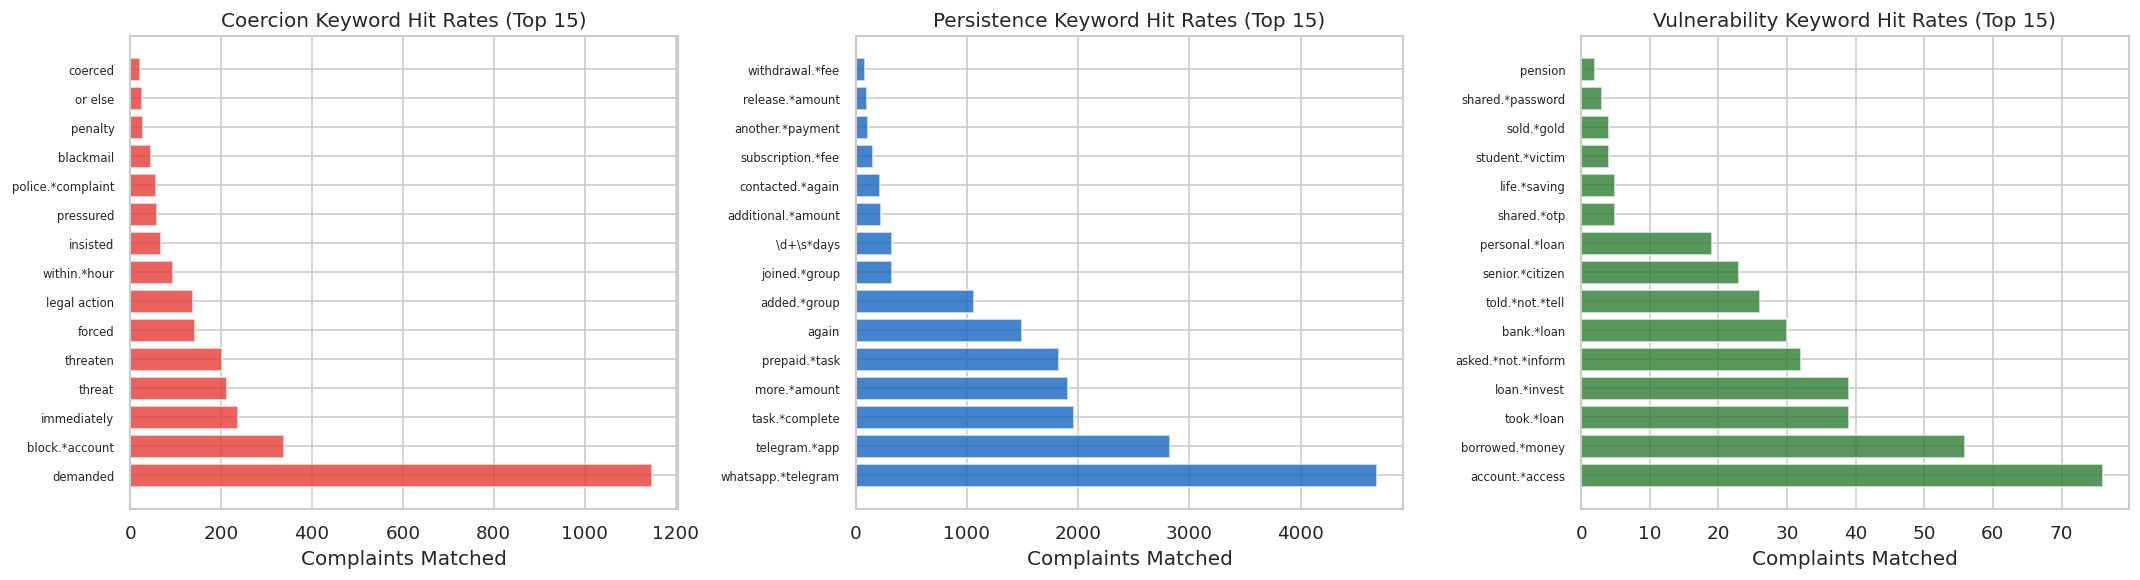

Saved: rc7_behavioral_audit.png


In [43]:

# RC-7: Behavioral Signal Extraction Audit
import matplotlib.pyplot as plt

narr = data['narrative_lower']

def kw_audit(kw_list, name, narr_series):
    print(f'\n=== {name} — Per-Keyword Hit Rates ===')
    hits = {kw: narr_series.str.contains(kw, regex=True, na=False).sum() for kw in kw_list}
    kw_df = pd.Series(hits).sort_values(ascending=False)
    print(kw_df.to_string())
    print(f'Total keywords: {len(kw_list)} | Zero-hit keywords: {(kw_df==0).sum()}')
    print(f'Top keyword: {kw_df.idxmax()}  ({kw_df.max():,} hits, {100*kw_df.max()/len(narr_series):.1f}%)')
    return kw_df

c_hits = kw_audit(COERCION_KW,    'COERCION',     narr)
p_hits = kw_audit(PERSISTENCE_KW, 'PERSISTENCE',  narr)
v_hits = kw_audit(VULN_KW,         'VULNERABILITY',narr)

print('\n=== Example Narratives: Coercion (S_coercion > 0.5) ===')
for i, (_, row) in enumerate(data[data['S_coercion']>0.5].head(3).iterrows()):
    print(f'[{i+1}] Loss=INR {row[COL_LOSS]:,.0f}  S_coercion={row["S_coercion"]:.3f}')
    print(f'     {str(row["narrative_lower"])[:250]}...\n')

print('=== Example Narratives: Persistence (S_persistence > 0.5) ===')
for i, (_, row) in enumerate(data[data['S_persistence']>0.5].head(3).iterrows()):
    print(f'[{i+1}] Loss=INR {row[COL_LOSS]:,.0f}  S_persistence={row["S_persistence"]:.3f}')
    print(f'     {str(row["narrative_lower"])[:250]}...\n')

print('=== Coverage Sensitivity — Coercion (incremental keyword addition) ===')
sorted_kw = c_hits.sort_values(ascending=False).index.tolist()
cum = pd.Series(False, index=narr.index)
for i, kw in enumerate(sorted_kw[:10]):
    cum = cum | narr.str.contains(kw, regex=True, na=False)
    print(f'  Top-{i+1:2d} keywords: coverage = {100*cum.mean():.2f}%')

print('\n=== Inter-Signal Spearman Correlation ===')
print(data[['S_coercion','S_persistence','S_vuln']].corr(method='spearman').round(4).to_string())

fig, axes = plt.subplots(1, 3, figsize=(18,5))
for ax, (hits, name, color) in zip(axes, [
    (c_hits,'Coercion','#E53935'),(p_hits,'Persistence','#1565C0'),(v_hits,'Vulnerability','#2E7D32')
]):
    top = hits.head(15)
    ax.barh(range(len(top)), top.values, color=color, alpha=0.8)
    ax.set_yticks(range(len(top))); ax.set_yticklabels([k[:30] for k in top.index], fontsize=7)
    ax.set_title(f'{name} Keyword Hit Rates (Top 15)'); ax.set_xlabel('Complaints Matched')

plt.tight_layout()
plt.savefig('rc7_behavioral_audit.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: rc7_behavioral_audit.png')


=== RC-8: Heavy-Tail Band Analysis ===

Top-10% (n=1,948):
  Mean:   INR       3,752,993
  Median: INR       1,509,384
  Max:    INR     274,421,493

Top-20% (n=3,896):
  Mean:   INR       5,053,960
  Median: INR         730,441
  Max:    INR  10,000,000,000

10-20% band (n=1,948):
  Mean:   INR       6,354,927
  Median: INR         341,000
  Max:    INR  10,000,000,000

Outliers in 10-20% band (>=P95=INR 3,500,000):
  Count: 103 (5.3% of band)
  Mean loss: INR 111,252,217

Loss ranks of 10-20% band cases:
  Mean rank: 3805  Median: 3839
  Fraction that would be top-10% by loss alone: 15.6%
  => FCPI intentionally de-prioritizes these (low POH/platform risk)

Top-10 highest-loss cases in 10-20% band:
       Amount_Loss_Clean      FCPI     S_poh Platform_Tier  Loss_Rank_all
12221       1.000000e+10  0.656843  0.249300       UNKNOWN              1
1533        2.744215e+08  0.624422  0.126583       UNKNOWN              2
9329        1.480000e+08  0.685342  0.249300     MESSAGING          

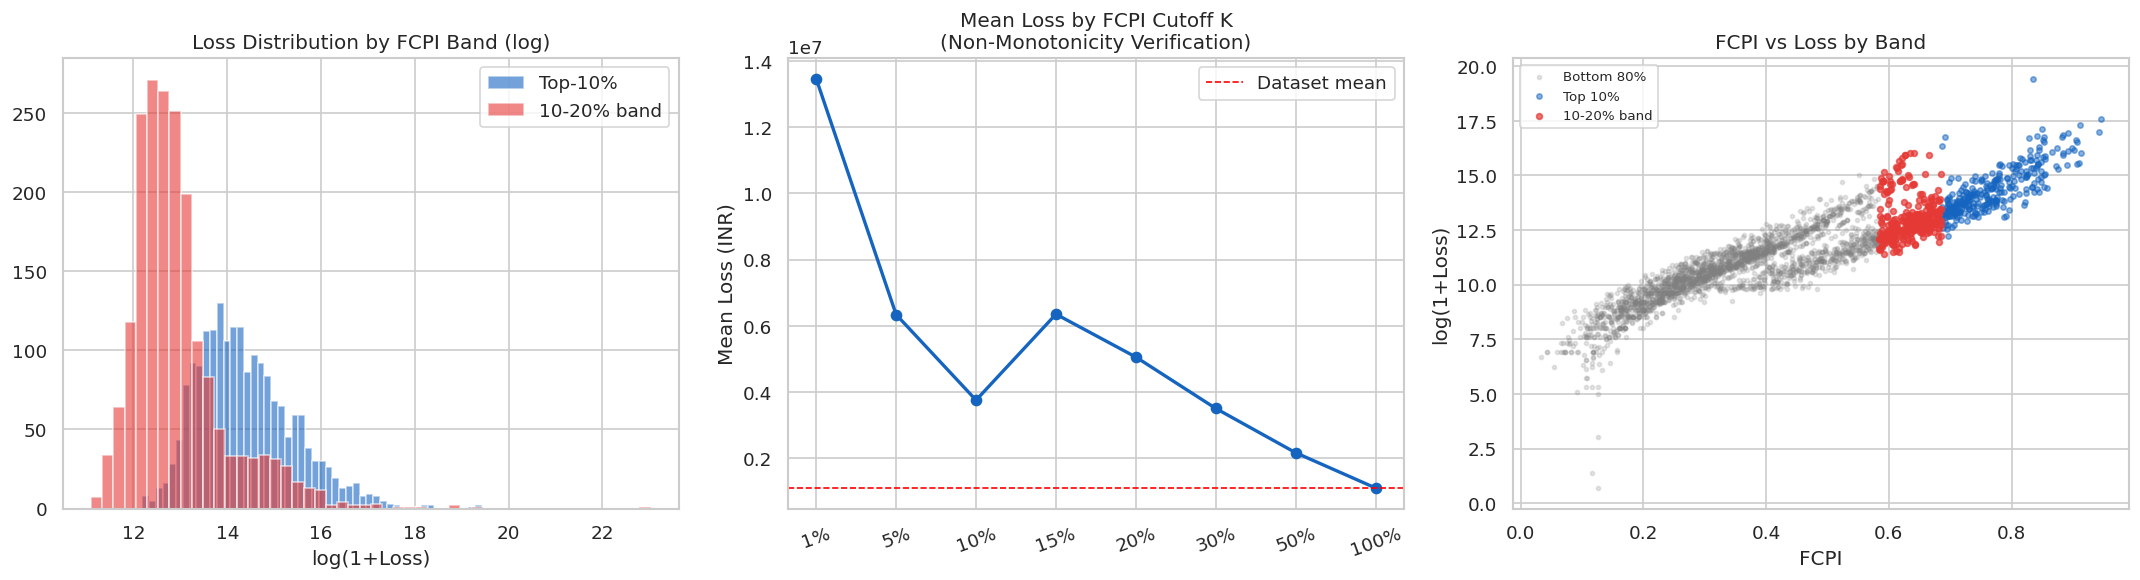

Saved: rc8_heavy_tail_band.png

INTERPRETATION: Cases in the 10-20% FCPI band include high-loss outliers
that FCPI intentionally deprioritizes (low POH). The non-monotonicity is
deliberate multi-dimensional reordering, not statistical instability.


In [44]:

# RC-8: Heavy-Tail Band Analysis
import matplotlib.pyplot as plt

n = len(data)
k10, k20 = int(0.10*n), int(0.20*n)
fcpi_idx = data['FCPI'].argsort().values[::-1]

top10_set  = set(fcpi_idx[:k10])
top20_set  = set(fcpi_idx[:k20])
band_set   = top20_set - top10_set

top10_loss = data.iloc[list(top10_set)][COL_LOSS]
top20_loss = data.iloc[list(top20_set)][COL_LOSS]
band_loss  = data.iloc[list(band_set)][COL_LOSS]

print('=== RC-8: Heavy-Tail Band Analysis ===')
for label, loss_s in [('Top-10%',top10_loss),('Top-20%',top20_loss),('10-20% band',band_loss)]:
    print(f'\n{label} (n={len(loss_s):,}):')
    print(f'  Mean:   INR {loss_s.mean():>15,.0f}')
    print(f'  Median: INR {loss_s.median():>15,.0f}')
    print(f'  Max:    INR {loss_s.max():>15,.0f}')

p95_band = np.percentile(band_loss, 95)
outliers_in_band = (band_loss >= p95_band)
print(f'\nOutliers in 10-20% band (>=P95=INR {p95_band:,.0f}):')
print(f'  Count: {outliers_in_band.sum()} ({100*outliers_in_band.mean():.1f}% of band)')
print(f'  Mean loss: INR {band_loss[outliers_in_band].mean():,.0f}')

data['Loss_Rank_all'] = data[COL_LOSS].rank(ascending=False, method='min').astype(int)
band_loss_ranks = data.iloc[list(band_set)]['Loss_Rank_all']
print(f'\nLoss ranks of 10-20% band cases:')
print(f'  Mean rank: {band_loss_ranks.mean():.0f}  Median: {band_loss_ranks.median():.0f}')
print(f'  Fraction that would be top-10% by loss alone: {(band_loss_ranks<=k10).mean():.1%}')
print(f'  => FCPI intentionally de-prioritizes these (low POH/platform risk)')

print('\nTop-10 highest-loss cases in 10-20% band:')
band_data = data.iloc[list(band_set)].nlargest(10, COL_LOSS)
print(band_data[[COL_LOSS,'FCPI','S_poh','Platform_Tier','Loss_Rank_all']].to_string())

k_fracs = [0.01,0.05,0.10,0.15,0.20,0.30,0.50,1.0]
mean_losses = [data.iloc[fcpi_idx[:max(1,int(kf*n))]][COL_LOSS].mean() for kf in k_fracs]

fig, axes = plt.subplots(1, 3, figsize=(18,5))
axes[0].hist(np.log1p(top10_loss), bins=50, alpha=0.6, label='Top-10%',    color='#1565C0')
axes[0].hist(np.log1p(band_loss),  bins=50, alpha=0.6, label='10-20% band',color='#E53935')
axes[0].set_title('Loss Distribution by FCPI Band (log)'); axes[0].set_xlabel('log(1+Loss)'); axes[0].legend()

klabels = [f'{int(kf*100)}%' for kf in k_fracs]
axes[1].plot(klabels, mean_losses, marker='o', color='#1565C0', lw=2)
axes[1].axhline(data[COL_LOSS].mean(), color='red', ls='--', lw=1, label='Dataset mean')
axes[1].set_title('Mean Loss by FCPI Cutoff K\n(Non-Monotonicity Verification)')
axes[1].set_ylabel('Mean Loss (INR)'); axes[1].tick_params(axis='x',rotation=20); axes[1].legend()

s = data.sample(min(3000,n), random_state=77)
band_f = s.index.isin(band_set); top10_f = s.index.isin(top10_set)
axes[2].scatter(s.loc[~band_f&~top10_f,'FCPI'], np.log1p(s.loc[~band_f&~top10_f,COL_LOSS]),
                alpha=0.2,s=6,c='grey',label='Bottom 80%')
axes[2].scatter(s.loc[top10_f,'FCPI'],  np.log1p(s.loc[top10_f,COL_LOSS]),  alpha=0.5,s=10,c='#1565C0',label='Top 10%')
axes[2].scatter(s.loc[band_f,'FCPI'],   np.log1p(s.loc[band_f,COL_LOSS]),   alpha=0.7,s=12,c='#E53935',label='10-20% band')
axes[2].set_title('FCPI vs Loss by Band'); axes[2].set_xlabel('FCPI'); axes[2].set_ylabel('log(1+Loss)'); axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('rc8_heavy_tail_band.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: rc8_heavy_tail_band.png')
print('\nINTERPRETATION: Cases in the 10-20% FCPI band include high-loss outliers')
print('that FCPI intentionally deprioritizes (low POH). The non-monotonicity is')
print('deliberate multi-dimensional reordering, not statistical instability.')


Computing bootstrap CIs (1000 iterations)...
  Done: FCPI v2 (Rank-IC)
  Done: FCPI v1 (Entropy)
  Done: FCPI Equal-W
  Done: GBM
  Done: Loss-Only (oracle)
  Done: Random

=== Bootstrap 95% CI Table ===
Method                       Spearman rho (95% CI)        AUC (95% CI)               Top-10% Loss INR (95% CI)       
----------------------------------------------------------------------------------------------------------------------
FCPI v2 (Rank-IC)            0.921 [0.919,0.924]      0.956 [0.953,0.958]     3,795,450 [ 3,320,531, 4,484,831]
FCPI v1 (Entropy)            0.689 [0.681,0.697]      0.872 [0.867,0.877]     3,206,795 [ 2,758,584, 3,666,497]
FCPI Equal-W                 0.779 [0.773,0.785]      0.909 [0.905,0.913]     3,564,080 [ 3,063,351, 4,183,672]
GBM                          0.527 [0.516,0.538]      0.841 [0.835,0.847]     3,171,687 [ 2,776,937, 3,652,633]
Loss-Only (oracle)           1.000 [1.000,1.000]      1.000 [1.000,1.000]     9,811,390 [ 4,240,121,20,499,520]

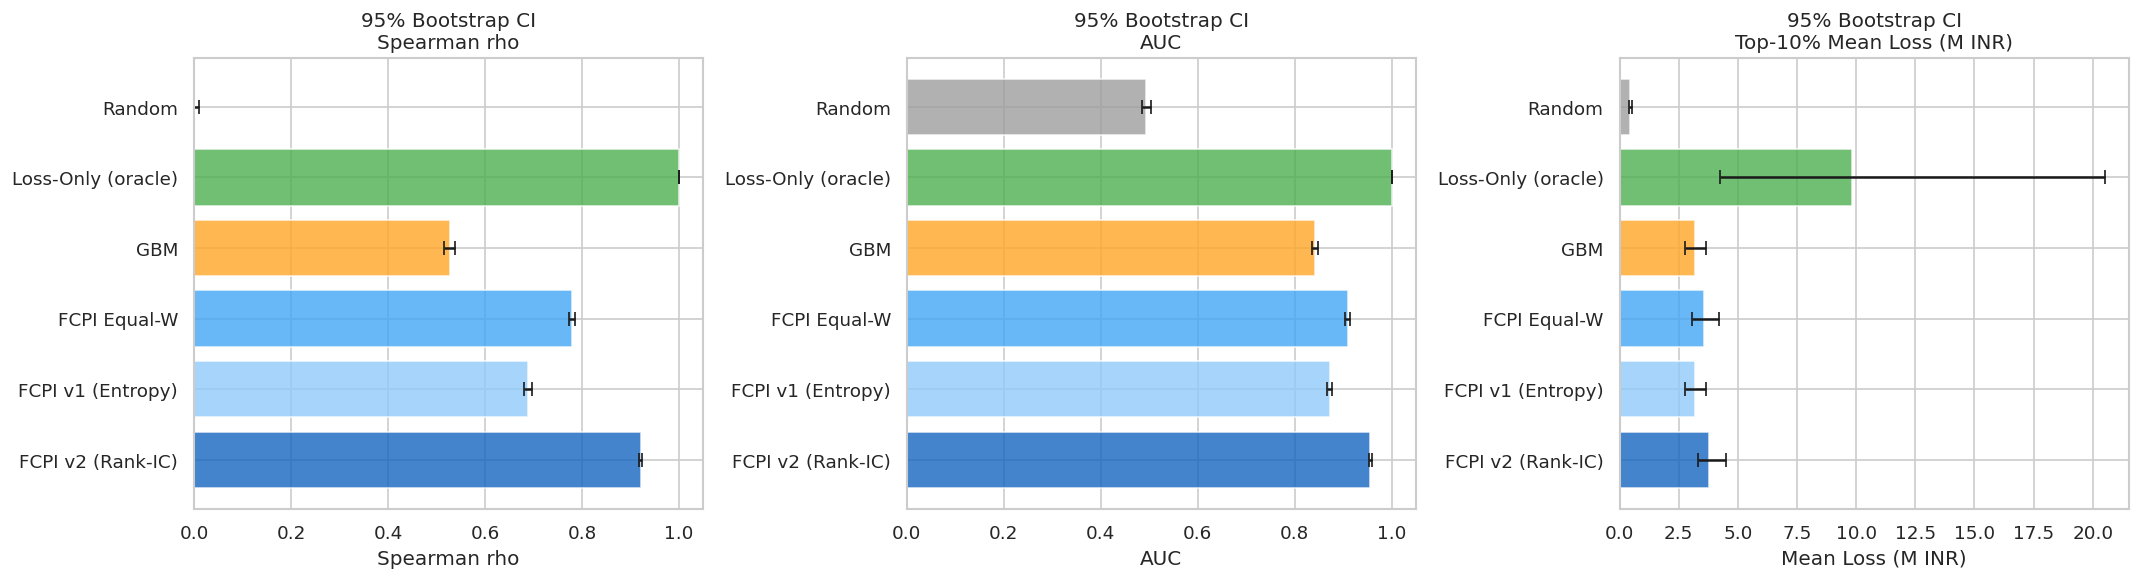

Saved: rc9_bootstrap_ci.png

INTERPRETATION: Add 95% CIs to all comparison tables in manuscript.
Cite Wilcoxon p-values when claiming FCPI significantly outperforms baselines.


In [45]:

# RC-9: Bootstrap 95% CIs and Pairwise Significance (Wilcoxon)
from scipy.stats import spearmanr, wilcoxon
from sklearn.metrics import roc_auc_score
import numpy as np

N_BOOT = 1000
np.random.seed(2024)
loss_arr = data[COL_LOSS].values
hl_arr   = data['High_Loss'].values

def bootstrap_ci(scores, loss, labels, n_boot=N_BOOT, k_pct=0.10):
    sc=np.asarray(scores); n=len(sc)
    rhos,aucs,topks=[],[],[]
    for _ in range(n_boot):
        idx=np.random.choice(n,n,replace=True)
        sb,lb,lbb=sc[idx],loss[idx],labels[idx]
        if lbb.sum()<2 or lbb.sum()>n-2: continue
        rho,_=spearmanr(sb,lb); rhos.append(rho)
        aucs.append(roc_auc_score(lbb,sb))
        k=max(1,int(k_pct*n))
        topks.append(lb[np.argsort(-sb)[:k]].mean())
    ci=lambda a:(np.mean(a),np.percentile(a,2.5),np.percentile(a,97.5))
    return ci(rhos),ci(aucs),ci(topks)

print('Computing bootstrap CIs (1000 iterations)...')
boot_res={}
for name,sc in methods_eval.items():
    rc,ac,tc=bootstrap_ci(sc,loss_arr,hl_arr)
    boot_res[name]={'rho':rc,'auc':ac,'topk':tc}
    print(f'  Done: {name}')

print('\n=== Bootstrap 95% CI Table ===')
print(f'{"Method":<28} {"Spearman rho (95% CI)":<28} {"AUC (95% CI)":<26} {"Top-10% Loss INR (95% CI)":<32}')
print('-'*118)
for name,res in boot_res.items():
    rm,rl,ru=res['rho']; am,al,au=res['auc']; tm,tl,tu=res['topk']
    print(f'{name:<28} {rm:.3f} [{rl:.3f},{ru:.3f}]      {am:.3f} [{al:.3f},{au:.3f}]    {tm:>10,.0f} [{tl:>10,.0f},{tu:>10,.0f}]')

print('\n=== Pairwise Wilcoxon Signed-Rank: FCPI v2 vs Baselines ===')
fcpi_rhos=[]
for _ in range(N_BOOT):
    idx=np.random.choice(len(data),len(data),replace=True)
    rho,_=spearmanr(data['FCPI'].values[idx],loss_arr[idx])
    fcpi_rhos.append(rho)
fcpi_rhos=np.array(fcpi_rhos)

print(f'{"Comparison":<44} {"FCPI mean rho":>14} {"Baseline mean rho":>18} {"p-value":>10} {"Sig":>12}')
print('-'*102)
for name,sc in methods_eval.items():
    if name in ['FCPI v2 (Rank-IC)','Loss-Only (oracle)','Random']: continue
    bl_sc=np.asarray(sc); bl_rhos=[]
    for _ in range(N_BOOT):
        idx=np.random.choice(len(data),len(data),replace=True)
        rho,_=spearmanr(bl_sc[idx],loss_arr[idx]); bl_rhos.append(rho)
    bl_rhos=np.array(bl_rhos)
    _,p=wilcoxon(fcpi_rhos,bl_rhos,alternative='greater')
    sig='*** p<0.001' if p<0.001 else ('** p<0.01' if p<0.01 else ('* p<0.05' if p<0.05 else 'n.s.'))
    print(f'FCPI v2 vs {name:<34} {fcpi_rhos.mean():>14.4f} {bl_rhos.mean():>18.4f} {p:>10.4f} {sig:>12}')

# Forest plot
fig,axes=plt.subplots(1,3,figsize=(18,5))
mnames=list(boot_res.keys())
c_list2=[colors_m.get(n,'grey') for n in mnames]
for ax,(metric,title) in zip(axes[:2],[('rho','Spearman rho'),('auc','AUC')]):
    means=[boot_res[n][metric][0] for n in mnames]
    lo   =[boot_res[n][metric][0]-boot_res[n][metric][1] for n in mnames]
    hi   =[boot_res[n][metric][2]-boot_res[n][metric][0] for n in mnames]
    ax.barh(mnames,means,xerr=[lo,hi],color=c_list2,alpha=0.8,capsize=4)
    ax.set_title(f'95% Bootstrap CI\n{title}'); ax.set_xlabel(title); ax.set_xlim(0,1.05)

tk_m =[boot_res[n]['topk'][0]/1e6 for n in mnames]
tk_lo=[(boot_res[n]['topk'][0]-boot_res[n]['topk'][1])/1e6 for n in mnames]
tk_hi=[(boot_res[n]['topk'][2]-boot_res[n]['topk'][0])/1e6 for n in mnames]
axes[2].barh(mnames,tk_m,xerr=[tk_lo,tk_hi],color=c_list2,alpha=0.8,capsize=4)
axes[2].set_title('95% Bootstrap CI\nTop-10% Mean Loss (M INR)'); axes[2].set_xlabel('Mean Loss (M INR)')

plt.tight_layout()
plt.savefig('rc9_bootstrap_ci.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: rc9_bootstrap_ci.png')
print('\nINTERPRETATION: Add 95% CIs to all comparison tables in manuscript.')
print('Cite Wilcoxon p-values when claiming FCPI significantly outperforms baselines.')


=== RC-10: Demographic Fairness Analysis ===

--- FCPI Prioritization by Age Group ---
                   n  median_fcpi_pct     mean_loss  top10_rate  highloss_rate  Parity_Gap
AgeGroup_Clean                                                                            
Unknown         9022          52.8786  1.896046e+06      0.1152         0.2926     -0.1775
46-60            613          78.8758  1.889611e+06      0.3589         0.5171     -0.1582
60+              183          63.7577  1.438324e+06      0.3060         0.4098     -0.1038
31-45           3503          60.1899  5.265000e+05      0.1470         0.3035     -0.1564
18-30           6094          38.1956  1.654774e+05      0.0194         0.1265     -0.1072
0-17              65          17.4692  5.946347e+04      0.0154         0.0615     -0.0462
Max demographic parity gap (top-10% rate): 0.3435

--- FCPI Prioritization by Profession ---
                                 n  median_fcpi_pct     mean_loss  top10_rate  highloss_rate

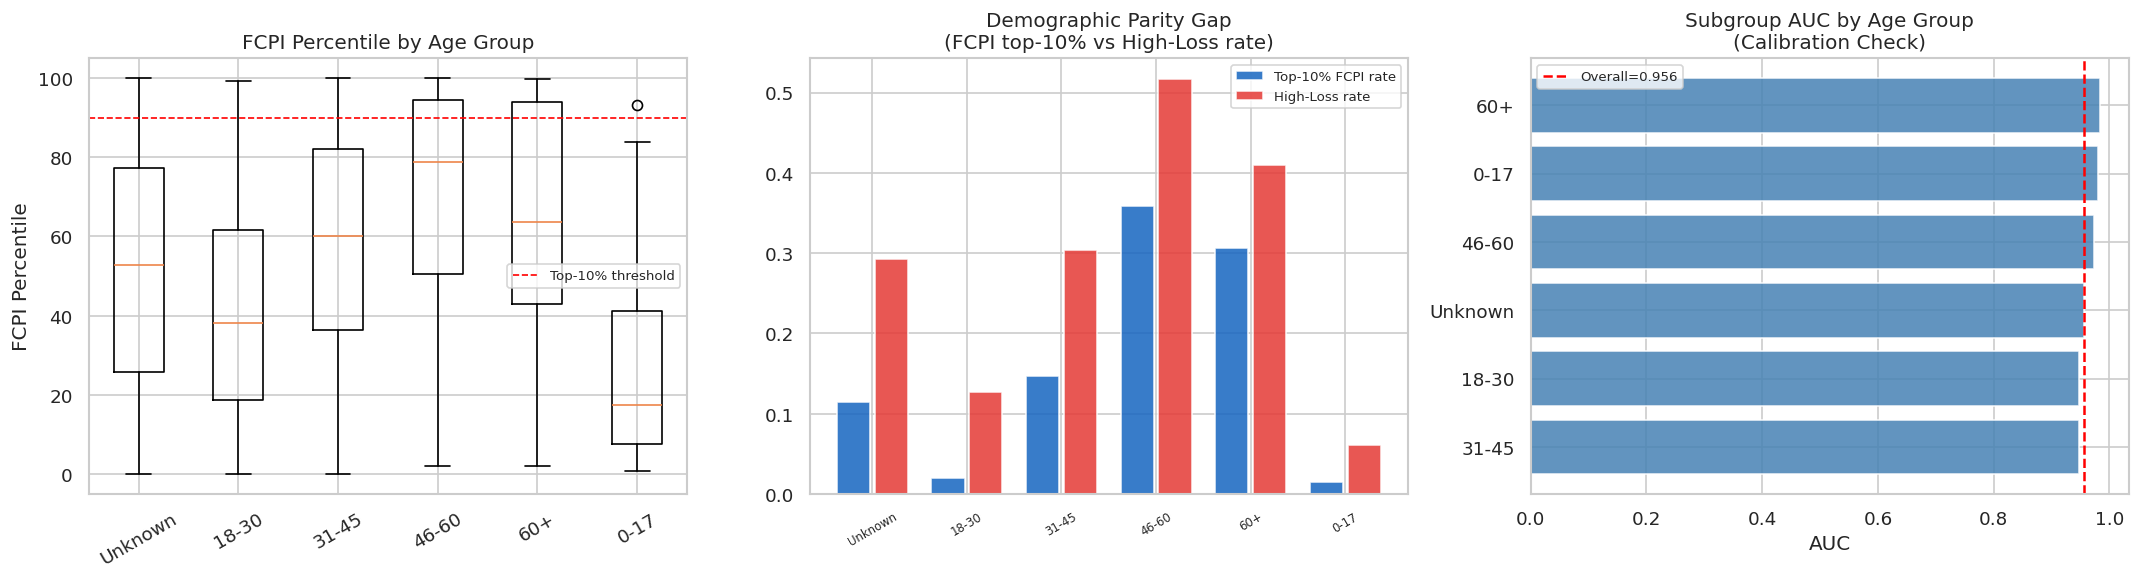

Saved: rc10_fairness.png

INTERPRETATION: Report AUC disparity and parity gap in the Limitations
section. Disparity < 0.05 supports equitable prioritization claim.


In [46]:

# RC-10: Demographic Fairness Analysis
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

age_col  = 'AgeGroup_Clean'
prof_col = 'Profession_Clean'
data['FCPI_pct'] = data['FCPI'].rank(pct=True)*100

print('=== RC-10: Demographic Fairness Analysis ===')

for gcol, gname in [(age_col,'Age Group'),(prof_col,'Profession')]:
    print(f'\n--- FCPI Prioritization by {gname} ---')
    grp = data.groupby(gcol).agg(
        n=(COL_LOSS,'count'),
        median_fcpi_pct=('FCPI_pct','median'),
        mean_loss=(COL_LOSS,'mean'),
        top10_rate=('FCPI_pct', lambda x:(x>=90).mean()),
        highloss_rate=('High_Loss','mean')
    ).sort_values('mean_loss', ascending=False)
    grp['Parity_Gap'] = grp['top10_rate'] - grp['highloss_rate']
    print(grp.round(4).to_string())
    max_gap = grp['top10_rate'].max() - grp['top10_rate'].min()
    print(f'Max demographic parity gap (top-10% rate): {max_gap:.4f}')

# Subgroup calibration (Spearman rho by age group)
print('\n=== Subgroup Calibration: rho(FCPI, Loss) by Age Group ===')
calib_rows=[]
for grp_val, grp_df in data.groupby(age_col):
    if len(grp_df) < 30: continue
    rho,_ = spearmanr(grp_df['FCPI'], grp_df[COL_LOSS])
    auc   = roc_auc_score(grp_df['High_Loss'], grp_df['FCPI'])
    calib_rows.append({'Group':grp_val,'N':len(grp_df),'rho':rho,'AUC':auc,
                       'Median_Loss':grp_df[COL_LOSS].median()})
calib_df = pd.DataFrame(calib_rows).sort_values('AUC')
print(calib_df.round(4).to_string(index=False))

overall_auc = roc_auc_score(data['High_Loss'], data['FCPI'])
min_auc     = calib_df['AUC'].min()
print(f'\nOverall AUC:       {overall_auc:.4f}')
print(f'Min subgroup AUC:  {min_auc:.4f}')
print(f'AUC disparity:     {overall_auc - min_auc:.4f}')
if overall_auc - min_auc < 0.05:
    print('  -> Minimal disparity (< 0.05) — system is well-calibrated across groups')
else:
    print('  -> Non-trivial disparity — consider demographic recalibration')

age_groups = data[age_col].value_counts().index[:8]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Boxplot
age_data = [data[data[age_col]==ag]['FCPI_pct'].values for ag in age_groups]
axes[0].boxplot(age_data, labels=[str(a)[:12] for a in age_groups], vert=True)
axes[0].axhline(90, color='red', ls='--', lw=1, label='Top-10% threshold')
axes[0].set_title('FCPI Percentile by Age Group'); axes[0].set_ylabel('FCPI Percentile')
axes[0].tick_params(axis='x', rotation=30); axes[0].legend(fontsize=8)

# Parity gap
parity = data.groupby(age_col).agg(
    top10=('FCPI_pct', lambda x:(x>=90).mean()),
    hl=('High_Loss','mean')
).reindex(age_groups)
x_p = np.arange(len(age_groups))
axes[1].bar(x_p-0.2, parity['top10'], 0.35, label='Top-10% FCPI rate', color='#1565C0', alpha=0.85)
axes[1].bar(x_p+0.2, parity['hl'],   0.35, label='High-Loss rate',     color='#E53935', alpha=0.85)
axes[1].set_xticks(x_p); axes[1].set_xticklabels([str(a)[:12] for a in age_groups], rotation=30, fontsize=7)
axes[1].set_title('Demographic Parity Gap\n(FCPI top-10% vs High-Loss rate)'); axes[1].legend(fontsize=8)

# Subgroup AUC
calib_p = calib_df.sort_values('AUC')
axes[2].barh(calib_p['Group'].astype(str), calib_p['AUC'], color='steelblue', alpha=0.85)
axes[2].axvline(overall_auc, color='red', ls='--', lw=1.5, label=f'Overall={overall_auc:.3f}')
axes[2].set_title('Subgroup AUC by Age Group\n(Calibration Check)'); axes[2].set_xlabel('AUC')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('rc10_fairness.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: rc10_fairness.png')
print('\nINTERPRETATION: Report AUC disparity and parity gap in the Limitations')
print('section. Disparity < 0.05 supports equitable prioritization claim.')
